# 5팀_김명환

# 스프린트 미션 4

## 목표
- 포르투갈 은행의 마케팅 데이터를 분석
- 결정 트리와 앙상블 기법을 사용하여 분류 모델을 구축
- 마케팅 캠페인의 효율성을 높이는 전략을 도출

## 미션 목표
- **최종 목표**: 정기 예금 가입 여부 예측하는 가장 정확한 분류 모델 개발
- **비즈니스 목표**: 마케팅 캠페인 효율성 향상 및 ROI 최적화 전략 제시
- **분석 기법**: 결정 트리와 앙상블 기법 활용
- **실무 적용**: 고객 우선순위 기반 타겟팅 시스템 구축

## 이해 포트투칼 (2008~2010)
- 2008년 (5월~12월): 글로벌 금융 위기가 확산되며 경기 둔화의 조짐이 나타나기 시작했고, 정부는 금융 시스템 안정화에 주력했습니다.
- 2009년: 금융 위기의 직격탄을 맞아 GDP가 크게 위축되고 실업률이 급등하는 등 심각한 경기 침체를 겪었습니다.
- 2010년 (1월~11월): 경기 침체에서 벗어나지 못하고 국가 재정 적자 및 부채 문제가 부각되어 유로존 재정 위기의 핵심 국가로 부상하기 시작했습니다.

## 핵심 분석 관점
1. 고객 세분화 분석
- **직업군별 정기 예금 가입률**: 소득 수준과 직업 안정성 기반 분석
- **교육 수준과 가입률 관계**: 교육-소득-금융 이해도 연관성 분석
- **연령대별 가입 패턴**: 라이프사이클별 금융 니즈 분석

2. 신용 및 경제 상태 분석
- **개별 고객 신용상태 등급화**: default, housing, loan 조합으로 신용 위험도 분류
- **소득 수준 추정**: job, education, age 조합으로 경제력 추정
- **거시경제 환경 분석**: 경제 지표가 전체 캠페인 성공률에 미치는 영향

3. 예측 모델 중요 변수 식별
- **가장 중요한 예측 변수 선별**: Feature Importance 분석
- **변수 간 상호작용 효과**: 조합 변수의 예측력 분석

## 실무적 활용 방안

1. 우선순위 기반 타겟팅 시스템
```
- 1순위: 가입 확률 80% 이상 → 즉시 연락
- 2순위: 가입 확률 50-80% → 2차 타겟
- 3순위: 가입 확률 30-50% → 여유 시간 연락
- 제외: 가입 확률 30% 미만 → 캠페인 제외
```

2. 고객별 맞춤 전략
```
- 고소득/고신용: 프리미엄 상품, 높은 최소예금액
- 중간소득/양호신용: 표준 정기예금, 적정 금리 조건  
- 저소득/기본신용: 소액 예금, 사회적 금융상품
- 신용위험군: 신중한 접근, 추가 담보 고려
```

3. 캠페인 최적화 전략
```
- 연락 횟수 제한: 3-4회 후 일정 기간 연락 중단
- 최적 타이밍: 월별/요일별 효과 분석 기반 스케줄링
- 통화 시간 가이드라인: 효과적인 상담 시간 기준 제시
```

## 기대 효과
- **비용 절감**: 성공 가능성 낮은 고객 제외로 운영비용 절약
- **성과 향상**: 동일 시간 대비 더 많은 가입자 확보
- **고객 만족**: 관심 있는 고객에게만 연락하여 민원 감소
- **전략적 의사결정**: 경제 상황 고려한 캠페인 강도 조절

# 데이터 이해

1. 데이터셋 기본 정보
- **출처**: UC Irvine Machine Learning Repository - Bank Marketing Dataset
- **기간**: 2008년 5월 ~ 2010년 11월 (시간순 정렬)
- **규모**: 41,188개 행, 21개 컬럼 (20개 입력 변수 + 1개 타겟 변수)
- **목적**: 포르투갈 은행의 정기 예금 마케팅 캠페인 성공 예측
- **특수 상황**: 글로벌 금융위기 시기 데이터 (2008년 서브프라임 모기지 사태 ~ 유럽 재정위기)

2. 컬럼별 상세 분석

2.1 고객 기본 정보 (Bank Client Data)
- **age**: 나이 (숫자형) - 고객의 연령대별 금융 성향 분석 가능
- **job**: 직업 (범주형) - 소득 수준 및 직업 안정성 추정 지표
  - 12개 카테고리: admin, blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown
- **marital**: 결혼 여부 (범주형) - 가족 구성 및 금융 책임 수준 추정
- **education**: 교육 수준 (범주형) - 소득 수준 및 금융 이해도 추정 지표
  - basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown

2.2 신용 상태 관련 (Credit Information)
- **default**: 신용 불량 여부 (범주형) - 가장 직접적인 신용 위험 지표
- **housing**: 주택 대출 여부 (범주형) - 상대적으로 안정적인 대출 형태
- **loan**: 개인 대출 여부 (범주형) - 상대적으로 위험도 높은 대출 형태

2.3 캠페인 관련 (Campaign Information)
- **contact**: 연락 방식 (범주형) - cellular vs telephone 효과 분석 가능
- **month**: 마지막 연락 월 (범주형) - 계절별/월별 마케팅 효과 분석
- **day_of_week**: 마지막 연락 요일 (범주형) - 요일별 연락 효과 분석
- **duration**: 통화 지속 시간 초 단위 (숫자형)
  - **제외**: 실무 예측 모델에서 반드시 제외 (통화 후에만 알 수 있는 정보로 실제 예측에 사용 불가)
- **campaign**: 현재 캠페인 연락 횟수 (숫자형) - 고객 피로도 분석 지표
- **pdays**: 이전 캠페인 후 경과 일수 (숫자형) - 999는 이전 캠페인 없음을 의미
- **previous**: 이전 캠페인 연락 횟수 (숫자형)
- **poutcome**: 이전 캠페인 결과 (범주형) - failure, nonexistent, success

2.4 거시경제 지표 (Social and Economic Context)
**주의: 개별 고객 경제력이 아닌 전체 경제환경 지표**
- **emp.var.rate**: 고용 변동률 (분기별 지표) - 경제 안정성 지표
- **cons.price.idx**: 소비자 물가지수 (월별 지표) - 구매력 지표  
- **cons.conf.idx**: 소비자 신뢰지수 (월별 지표) - 경제 심리 지표
- **euribor3m**: 3개월 유리보 금리 (일별 지표) - 자금 조달 비용
- **nr.employed**: 고용자 수 (분기별 지표) - 경제 규모 지표

2.5 타겟 변수
- **y**: 정기 예금 가입 여부 (이진 분류) - "yes" 또는 "no"

3. 데이터 특성 및 주의사항

3.1 결측치 처리 방안
- 범주형 데이터의 결측치는 "unknown" 라벨로 표시됨
- 이를 별도 카테고리로 처리할지, 다른 방법으로 대체할지 결정 필요

3.2 Duration 변수 처리 전략
- **모든 모델에서 duration 변수 제외**: 실무적으로 예측 시점에 알 수 없는 정보이므로 무조건 제거
- 통화 시간은 결과 분석용으로만 활용 (모델 성능 평가에는 사용하지 않음)

3.3 시간적 특성 및 금융위기 맥락
- 데이터가 시간순으로 정렬되어 있어 시계열 분석 가능
- **2008-2010년 글로벌 금융위기 시기**:
  - 경제불안정, 높은 실업률, 신용경색 상황
  - 고객들의 위험회피 성향 증가로 안전자산(정기예금) 선호도 변화
  - 은행의 자금조달 어려움과 예금 확보 필요성 증대
- **거시경제 지표의 중요성**: 금융위기 상황에서 경제지표가 고객 행동에 미치는 영향 극대화
- **캠페인 전략의 시대적 배경**: 불안정한 경제상황에서의 마케팅 전략 효과성 분석 가능

4. 파생 변수 생성 아이디어

4.1 개별 고객 신용 위험도 지수
**신용상태 점수 계산**:
- default: no(+3점), unknown(0점), yes(-5점)
- housing: yes(+2점, 주택대출 승인받을 신용도), no(0점)  
- loan: no(+1점, 개인대출 없음), yes(-1점)
- **총 신용점수**: -4점 ~ +6점 범위

**신용등급 분류**:
- A등급 : 최우량 신용
- B등급 : 우량 신용  
- C등급 : 보통 신용
- D등급 : 주의 신용
- E등급 : 위험 신용

4.2 개별 고객 소득 수준 추정 지수
**소득추정 점수 계산**:
총점 = 직업점수 + 교육점수 + 나이점수 + 결혼상태점수

4.3 거시경제 상황 지수 (시점별 동일)
**주의: 모든 고객이 같은 시점에는 동일한 경제환경 등급**
- emp.var.rate, cons.price.idx, euribor3m 조합으로 경제 상황 등급 생성
- **금융위기 맥락에서의 분류**: 위기 전/위기 절정/회복기 등으로 세분화
- 개별 고객 경제력과는 무관, 캠페인 시점의 전체 경제상황 반영
- **금융위기 특수상황**: 정기예금에 대한 사회적 인식 변화 (안전자산 선호도 증가)

4.4 캠페인 효율성 지표
- campaign(연락횟수), previous(과거연락), poutcome(과거결과) 조합
- 고객별 캠페인 반응성 및 피로도 지수 생성

5. 비즈니스 관점에서의 데이터 해석

5.1 고객 세분화 관점
**개별 고객 특성 기반 세분화**:
- 신용등급(A-E) × 소득등급(고소득-저소득) 매트릭스로 25개 세그먼트 생성
- 연령대별 라이프사이클과 금융니즈 차이 분석
- 결혼상태별 가족책임도 및 안정성 평가

**시점별 거시경제 환경 고려**:
- 경제상황(호황/안정/불안/침체)별 세그먼트 반응도 차이 분석

5.2 캠페인 최적화 관점  
- 월별/요일별 효과로 최적 타이밍 도출
- 연락 횟수별 효과로 적정 연락 횟수 도출
- 과거 캠페인 결과 활용한 개인화 전략

5.3 경제 환경 반영
**금융위기 시기 거시경제 지표 활용 전략**:
- **위기 절정기**: 안전지향 고객(고신용) 중심, 보수적 접근
- **경제회복기**: 점진적 확대, 기회 포착형 고객 타겟팅
- **금리변동기**: 금리 민감 고객 우선 접촉, 경쟁 우위 확보
- **고용불안기**: 고용안정 직종(공무원, 대기업) 집중 공략

**금융위기 맥락의 차별화 메시지**:
- 불확실한 시기일수록 안전한 정기예금의 중요성 부각
- 경제회복 시점 포착한 적극적 자산관리 제안

In [83]:
from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/master/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
#from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import helper_c0z0c_dev as helper

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time

from matplotlib.colors import ListedColormap

# 모델링 관련 추가 import
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import VotingClassifier
import warnings
warnings.filterwarnings('ignore')

In [86]:
from sklearn.linear_model import LinearRegression # 선형 회귀
from sklearn.linear_model import LinearRegression # 다중 휘귀
from sklearn.preprocessing import PolynomialFeatures # 다항 속성
from sklearn.preprocessing import StandardScaler # 정규화
from sklearn.preprocessing import MinMaxScaler # MinMaxScaler 추가
from sklearn.model_selection import train_test_split

from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_iris
from sklearn.datasets import make_moons

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error

# 다중공선성 진단용
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    print("statsmodels 라이브러리 로드 완료")
except ImportError:
    print("statsmodels 라이브러리가 설치되지 않았습니다.")
    print("설치 명령: !pip install statsmodels")


statsmodels 라이브러리 로드 완료


In [87]:
df = helper.pd_read_csv('data_4/bank-additional-full.csv', sep=';')
df_commit_0_0 = df.copy()

✅ 파일 읽기 성공: 41188행 × 21열


# EDA (탐색)

In [88]:
df = df_commit_0_0.copy()
print("데이터프레임의 기술 통계")
df.describe(include='all').head_att()
display(df.shape)


데이터프레임의 기술 통계
            age    job marital         education default housing  loan  contact month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx euribor3m nr.employed     y
  count   41188  41188   41188             41188   41188   41188 41188    41188 41188       41188    41188    41188    41188    41188       41188        41188          41188         41188     41188       41188 41188
 unique     nan     12       4                 8       3       3     3        2    10           5      nan      nan      nan      nan           3          nan            nan           nan       nan         nan     2
    top     nan admin. married university.degree      no     yes    no cellular   may         thu      nan      nan      nan      nan nonexistent          nan            nan           nan       nan         nan    no
   freq     nan  10422   24928             12168   32588   21576 33950    26144 13769        8623      nan      nan      n

(41188, 21)

In [6]:
df = df_commit_0_0.copy()
print("데이터프레임의 정보")
#display(df.info())
df.info()

데이터프레임의 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   4118

In [7]:
df = df_commit_0_0.copy()
# 결측치 비율
missing_ratio = df.isnull().mean() * 100
print(f"각 컬럼의 결측: {missing_ratio[missing_ratio > 0]}")
#display(missing_ratio[missing_ratio > 0])
#print("\n")

# 중복치 비율
duplicate_ratio = df.duplicated().mean() * 100
print(f"중복치 비율: {duplicate_ratio:.2f}%")


각 컬럼의 결측: Series([], dtype: float64)
중복치 비율: 0.03%


In [8]:
df.describe(include='all').head_att()

            age    job marital         education default housing  loan  contact month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx euribor3m nr.employed     y
  count   41188  41188   41188             41188   41188   41188 41188    41188 41188       41188    41188    41188    41188    41188       41188        41188          41188         41188     41188       41188 41188
 unique     nan     12       4                 8       3       3     3        2    10           5      nan      nan      nan      nan           3          nan            nan           nan       nan         nan     2
    top     nan admin. married university.degree      no     yes    no cellular   may         thu      nan      nan      nan      nan nonexistent          nan            nan           nan       nan         nan    no
   freq     nan  10422   24928             12168   32588   21576 33950    26144 13769        8623      nan      nan      nan      nan   

## 컬럼 데이터 타입 기본 정리

In [9]:
df = df_commit_0_0.copy()

# 범주형 데이터 변환
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                       'contact', 'month', 'day_of_week', 'poutcome', 'y']
for col in categorical_columns:
    df[col] = df[col].astype('category')

# 숫자형 데이터 변환
numeric_columns = ['age', 'duration', 'campaign', 'pdays', 'previous',
                   'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                   'euribor3m', 'nr.employed']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# pdays 컬럼 처리
df['pdays'] = df['pdays'].replace(-1, np.nan)  # -1 값을 NaN으로 처리

# 데이터 타입 변환 결과 확인
print("데이터 타입 변환 완료")
print("범주형 데이터:")
for col in categorical_columns:
    print(f"  {col}: {df[col].dtype}, 고유값 개수: {df[col].nunique()}")

print("\n숫자형 데이터:")
for col in numeric_columns:
    print(f"  {col}: {df[col].dtype}")

print("결측치 개수",df.isnull().sum().to_list())

print()
print("df.describe(include='all')")
df.describe(include='all').head_att(50)

df_commit_0_1 = df.copy()

데이터 타입 변환 완료
범주형 데이터:
  job: category, 고유값 개수: 12
  marital: category, 고유값 개수: 4
  education: category, 고유값 개수: 8
  default: category, 고유값 개수: 3
  housing: category, 고유값 개수: 3
  loan: category, 고유값 개수: 3
  contact: category, 고유값 개수: 2
  month: category, 고유값 개수: 10
  day_of_week: category, 고유값 개수: 5
  poutcome: category, 고유값 개수: 3
  y: category, 고유값 개수: 2

숫자형 데이터:
  age: int64
  duration: int64
  campaign: int64
  pdays: int64
  previous: int64
  emp.var.rate: float64
  cons.price.idx: float64
  cons.conf.idx: float64
  euribor3m: float64
  nr.employed: float64
결측치 개수 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

df.describe(include='all')
            age    job marital         education default housing  loan  contact month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx euribor3m nr.employed     y
  count   41188  41188   41188             41188   41188   41188 41188    41188 41188       41188    41188    41188  

In [10]:
# 누락값 상세 분석
df = df_commit_0_1.copy()

print("=== 데이터 전처리: 누락값 및 데이터 분포 분석 ===")
print(f"전체 데이터 규모: {df.shape}")
print()

# 1. 누락값 상세 분석
print("1. 누락값 현황 분석")
print("-" * 50)
missing_info = pd.DataFrame({
    '누락값_개수': df.isnull().sum(),
    '누락값_비율(%)': (df.isnull().sum() / len(df) * 100).round(2),
    '데이터타입': df.dtypes
})
missing_info = missing_info[missing_info['누락값_개수'] > 0]
print(f"누락:{len(missing_info)}")
print()

# 2. 범주형 변수의 'unknown' 값 분석 (실질적 누락값)
print("2. 범주형 변수의 'unknown'")
print("-" * 50)
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                       'contact', 'month', 'day_of_week', 'poutcome', 'y']

unknown_info = []
for col in categorical_columns:
    if 'unknown' in df[col].cat.categories:
        unknown_count = (df[col] == 'unknown').sum()
        unknown_ratio = (unknown_count / len(df) * 100)
        unknown_info.append({
            '컬럼': col,
            'unknown_개수': unknown_count,
            'unknown_비율(%)': round(unknown_ratio, 2),
            '전체_카테고리수': df[col].nunique()
        })

if unknown_info:
    unknown_df = pd.DataFrame(unknown_info)
    unknown_df = unknown_df[unknown_df['unknown_개수'] > 0]
    unknown_df.head_att(50)

print()

# 3. pdays 특수값 (-1을 NaN으로 처리했으므로) 확인
print("3. pdays 분석")
print("-" * 50)
if 'pdays' in df.columns:
    pdays_null = df['pdays'].isnull().sum()
    print(f"pdays NaN 값 : {pdays_null:,}개 ({pdays_null/len(df)*100:.1f}%)")
    print(f"pdays 유효값 : {len(df) - pdays_null:,}개 ({(len(df) - pdays_null)/len(df)*100:.1f}%)")
    pdays_999 = df['pdays'] == 999
    pdays_999_count = pdays_999.sum()
    print(f"pdays == 999 값 : {pdays_999_count:,}개 ({pdays_999_count/len(df)*100:.1f}%)")
    print(f"pdays < 999 값 : {len(df) - pdays_999_count:,}개 ({(len(df) - pdays_999_count)/len(df)*100:.1f}%)")
    yes_count = df['y'].value_counts().get('yes', 0)
    yes_999 = df[pdays_999]['y'].value_counts().get('yes', 0)
    yes_not_999 = df[~pdays_999]['y'].value_counts().get('yes', 0)
    print(f"pdays==999 가입자 수(y=yes): {yes_999:,}명 {yes_999/yes_count:.2f}")
    print(f"pdays!=999 가입자 수(y=yes): {yes_not_999:,}명 {yes_not_999/yes_count:.2f}")
    
print()

# 4. 각 컬럼별 기본 통계
print("4. 컬럼별 기본 정보 요약")
print("-" * 50)
summary_info = []
for col in df.columns:
    if df[col].dtype == 'category':
        summary_info.append({
            '컬럼명': col,
            '타입': 'category',
            '고유값수': df[col].nunique(),
            '최빈값': df[col].mode().iloc[0], # if len(df[col].mode()) > 0 else 'N/A',
            '누락값': df[col].isnull().sum()
        })
    else:
        summary_info.append({
            '컬럼명': col,
            '타입': 'numeric',
            '고유값수': df[col].nunique(),
            '평균값': round(df[col].mean(), 2), # if pd.notnull(df[col].mean()) else 'N/A',
            '누락값': df[col].isnull().sum()
        })

summary_df = pd.DataFrame(summary_info)
#display(summary_df)
summary_df.head_att(50)


=== 데이터 전처리: 누락값 및 데이터 분포 분석 ===
전체 데이터 규모: (41188, 21)

1. 누락값 현황 분석
--------------------------------------------------
누락:0

2. 범주형 변수의 'unknown'
--------------------------------------------------
        컬럼 unknown_개수 unknown_비율(%) 전체_카테고리수
 0       job          330             0.8              12
 1   marital           80            0.19               4
 2 education         1731             4.2               8
 3   default         8597           20.87               3
 4   housing          990             2.4               3
 5      loan          990             2.4               3

3. pdays 분석
--------------------------------------------------
pdays NaN 값 : 0개 (0.0%)
pdays 유효값 : 41,188개 (100.0%)
pdays == 999 값 : 39,673개 (96.3%)
pdays < 999 값 : 1,515개 (3.7%)
pdays==999 가입자 수(y=yes): 3,673명 0.79
pdays!=999 가입자 수(y=yes): 967명 0.21

4. 컬럼별 기본 정보 요약
--------------------------------------------------
            컬럼명     타입 고유값수  평균값 누락값            최빈값
  0            age  numeric       78

## > 메모< 한글 보조 컬럼 추가

In [11]:
#
df = df_commit_0_1.copy()
column_kr = {
    'age': '나이',
    'job': '직업',
    'marital': '결혼',
    'education': '교육',
    'default': '신용불량',
    'housing': '주택대출',
    'loan': '개인대출',
    'contact': '연락방식',
    'month': '연락월',
    'day_of_week': '연락요일',
    'duration': '통화시간',
    'campaign': '연락횟수',
    'pdays': '경과일수',
    'previous': '과거연락',
    'poutcome': '과거결과',
    'emp.var.rate': '고용률',
    'cons.price.idx': '물가지수',
    'cons.conf.idx': '신뢰지수',
    'euribor3m': '유리보금리',
    'nr.employed': '고용자수',
    'y': '가입여부'
}

category_value_kr = {
    # job
    "admin.": "행정직",
    "blue-collar": "현장직",
    "technician": "기술자",
    "services": "서비스직",
    "management": "관리자",
    "retired": "은퇴자",
    "entrepreneur": "기업가",
    "self-employed": "자영업",
    "housemaid": "가사도우미",
    "unemployed": "실업자",
    "student": "학생",
    "unknown": "미상",
    # marital
    "married": "기혼",
    "single": "미혼",
    "divorced": "이혼",
    # education
    "university.degree": "대학교",
    "high.school": "고등학교",
    "basic.9y": "중학교",
    "professional.course": "전문",
    "basic.4y": "초등학교",
    "basic.6y": "초등학교",
    "illiterate": "문맹",
    # default/loan/housing 등
    "no": "아님",
    "yes": "있음",
    # 연락방식
    "telephone": "유선",
    "cellular": "휴대",
    # 연락월
    "may": "5월", "jun": "6월", "jul": "7월", "aug": "8월", "oct": "10월",
    "nov": "11월", "dec": "12월", "mar": "3월", "apr": "4월", "sep": "9월",
    # 연락요일
    "mon": "월", "tue": "화", "wed": "수", "thu": "목", "fri": "금",
    # 과거결과
    "nonexistent": "과거연락없음",
    "failure": "실패",
    "success": "성공",    
}

column_kr2 = {**column_kr, **category_value_kr}

df.set_head_att(column_kr2)
df.head_att(1)
df_commit_0_1 = df.copy()
print("\ndf.describe(include='all')")
df.describe(include='all').head_att(50)


columns = df.columns.to_list()
for col in columns:
    # 고유값이 20개 미만인 컬럼만(범주형 위주)
    print(f"\n{col} {column_kr2[col]}")
    if df[col].unique().size < 20:
        # 컬럼별 고유값 출력
        value_counts = df[col].value_counts(dropna=False)
        value_ratio = df[col].value_counts(normalize=True, dropna=False) * 100
        for u in df[col].unique():
            if u in column_kr2:
                print(f"{u}({column_kr2[u]})", end=' ')
            else:
                print(f"{u}(미번역)", end=' ')




   나이      직업    결혼      교육 신용불량 주택대출 개인대출  연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락    과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부
    age       job marital education  default  housing     loan   contact  month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y
 0   56 housemaid married  basic.4y       no       no       no telephone    may         mon      261        1      999        0 nonexistent          1.1         93.994         -36.4      4.857        5191       no

df.describe(include='all')
           나이   직업    결혼              교육 신용불량 주택대출 개인대출 연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락    과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부
            age    job marital         education  default  housing     loan  contact  month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y
  count   41188  41188   411

- 각 컬럼 별 교유값이 20개 이하인 것에 대한 고유값 항목을 조회 하였습니다.
  - 고유 값 파악

## 누락값 확인

In [12]:

# 누락값 확인
df = df_commit_0_1.copy()
#df.isna().sum().head_att(30)
na_count_table = pd.DataFrame({
    'Column': df.columns,
    '개수': df.isna().sum()
})
na_count_row = pd.DataFrame(df.isna().sum()).T
na_count_row.set_head_att(df.get_head_att())
na_count_row.index = ['결측치']
na_count_row.head_att()


# 메모리 해지 (싷험)
del na_count_row
del df
import gc; gc.collect();


        나이 직업    결혼      교육 신용불량 주택대출 개인대출 연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락 과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부
         age  job marital education  default  housing     loan  contact  month day_of_week duration campaign    pdays previous poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y
 결측치    0    0       0         0        0        0        0        0      0           0        0        0        0        0        0            0              0             0          0           0        0


- 누락값에 대한 검토 
  - 기본적인 nan은 없으나 
  - 가이드 문서 (bank-additional-names.txt)를 살펴 보면 pdays 999와 같이 known 값이 있다고 한다.
    - 이것은 추후 전처리 과정에서 처리하자

## 히스토 그램

{'age': '나이', 'job': '직업', 'marital': '결혼', 'education': '교육', 'default': '신용불량', 'housing': '주택대출', 'loan': '개인대출', 'contact': '연락방식', 'month': '연락월', 'day_of_week': '연락요일', 'duration': '통화시간', 'campaign': '연락횟수', 'pdays': '경과일수', 'previous': '과거연락', 'poutcome': '과거결과', 'emp.var.rate': '고용률', 'cons.price.idx': '물가지수', 'cons.conf.idx': '신뢰지수', 'euribor3m': '유리보금리', 'nr.employed': '고용자수', 'y': '가입여부', 'admin.': '행정직', 'blue-collar': '현장직', 'technician': '기술자', 'services': '서비스직', 'management': '관리자', 'retired': '은퇴자', 'entrepreneur': '기업가', 'self-employed': '자영업', 'housemaid': '가사도우미', 'unemployed': '실업자', 'student': '학생', 'unknown': '미상', 'married': '기혼', 'single': '미혼', 'divorced': '이혼', 'university.degree': '대학교', 'high.school': '고등학교', 'basic.9y': '중학교', 'professional.course': '전문', 'basic.4y': '초등학교', 'basic.6y': '초등학교', 'illiterate': '문맹', 'no': '아님', 'yes': '있음', 'telephone': '유선', 'cellular': '휴대', 'may': '5월', 'jun': '6월', 'jul': '7월', 'aug': '8월', 'oct': '10월', 'nov': '11월', '

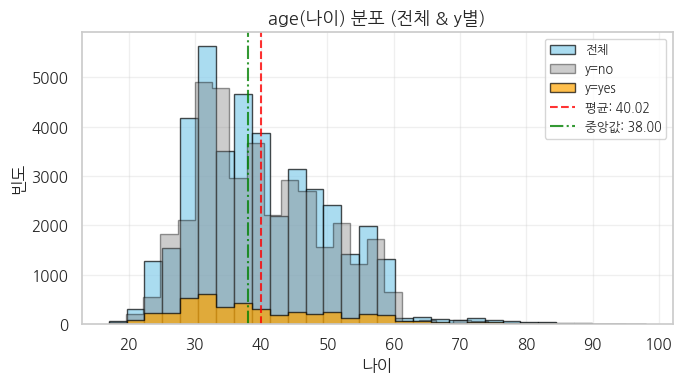

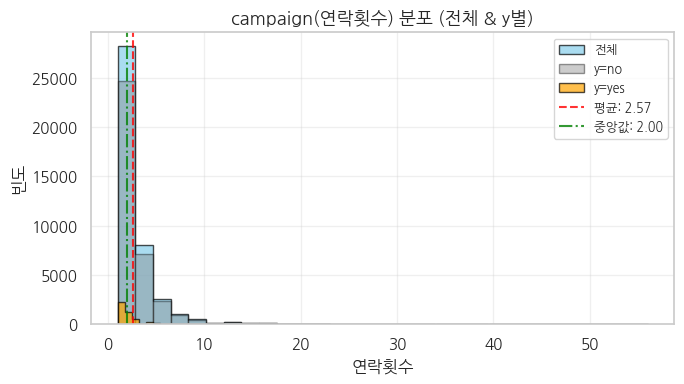

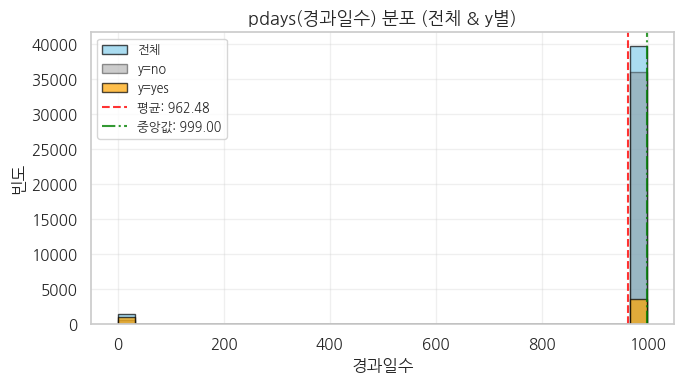

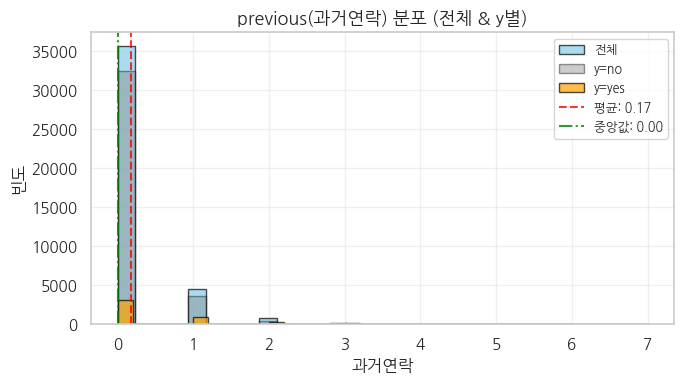

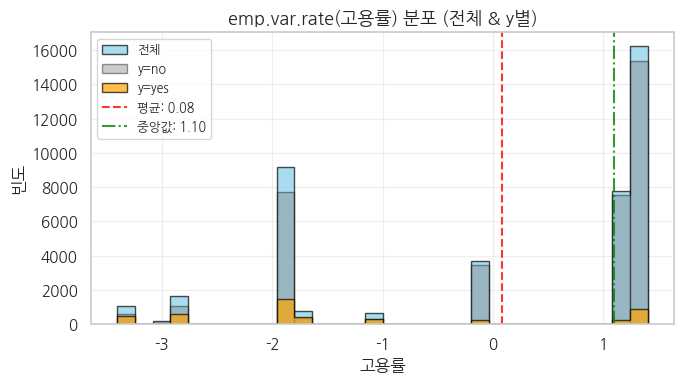

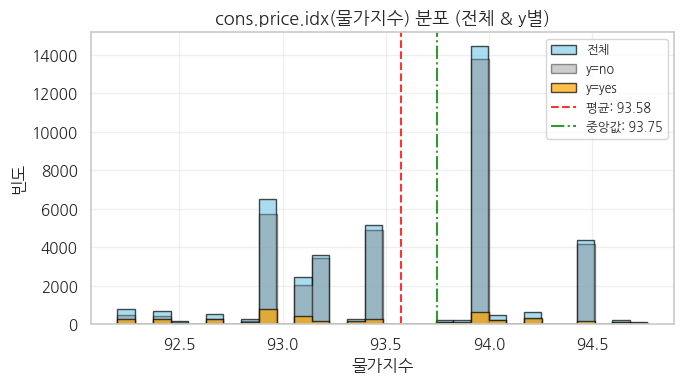

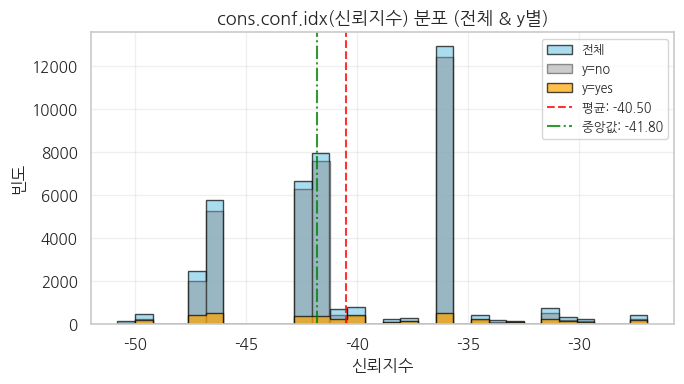

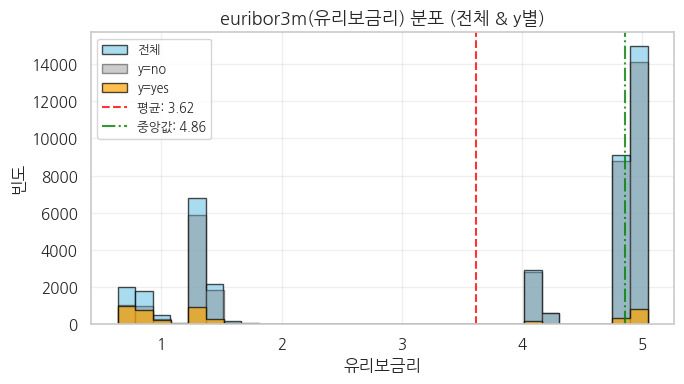

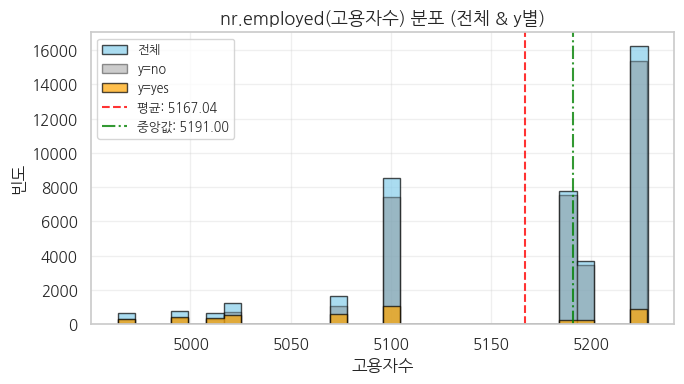

In [79]:
# 데이터 분포 시각화 및 분석
df = df_commit_0_1.copy()
print(df.get_head_att())


# 1. 타겟 변수 분포 확인
print("1. 타겟 변수 (y) 분포")
print("-" * 30)
target_counts = df['y'].value_counts()
target_ratio = df['y'].value_counts(normalize=True) * 100

print("정기예금 가입 현황:")
for value, count in target_counts.items():
    ratio = target_ratio[value]
    print(f"  {value}: {count:,}명 ({ratio:.1f}%)")

# 불균형 정도 확인
minority_ratio = min(target_ratio.values)
print(f"\n클래스 불균형 정도: {minority_ratio:.1f}% (소수클래스 비율)")
if minority_ratio < 20:
    print("클래스 불균형 심각 - 샘플링 기법 고려 필요")
elif minority_ratio < 40:
    print("클래스 불균형 존재 - 모델 평가 시 주의 필요")
else:
    print("클래스 균형 양호")

print("\n" + "="*60 + "\n")


# 2. 숫자형 변수별로 독립적인 히스토그램 그리기
print("2. 숫자형 변수 분포")
print("-" * 30)

model_numeric_columns = ['age', 'campaign', 'pdays', 'previous',
                        'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                        'euribor3m', 'nr.employed']

for col in model_numeric_columns:
    data_clean = df[col].dropna()
    col_kr = column_kr.get(col, col)
    plt.figure(figsize=(7, 4))
    # 전체 분포
    plt.hist(data_clean, bins=30, alpha=0.7, color='skyblue', edgecolor='black', label='전체')
    # y별 분포(yes/no)도 함께 그리기
    if 'y' in df.columns:
        for y_val, color, alpha in zip(['no', 'yes'], ['gray', 'orange'], [0.4, 0.7]):
            y_data = df[df['y'] == y_val][col].dropna()
            plt.hist(y_data, bins=30, alpha=alpha, color=color, edgecolor='black', label=f'y={y_val}', histtype='stepfilled')
    plt.title(f'{col}({col_kr}) 분포 (전체 & y별)', fontsize=13, fontweight='bold')
    plt.xlabel(col_kr)
    plt.ylabel('빈도')
    plt.grid(True, alpha=0.3)

    # 기본 통계 정보 추가
    mean_val = data_clean.mean()
    median_val = data_clean.median()
    plt.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'평균: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-.', alpha=0.8, label=f'중앙값: {median_val:.2f}')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


del df
import gc; gc.collect();



1. 나이 평균
  - 값이 40 중앙 값이 39로 50대가 가장 많음
2. 연락 횟수
  - 1 - 5회가 대부분
  - 10회 이상은 이상치 혹은 고객 피로도 증가로 이어질 수 있음 으로 실제 데이터 인지 검토 필요
  - 특히 20회 이상의 경우 실제 대이타라면 고객과 마케팅직원을 면밀히 검토 하여야한다.
    - 고객 스토닝 우려
  - 여기서는 이상치로 제거될 가능성이 높다.
    - 전처리에서 검토
3. 경과일수
   - 999(접촉없음) 이 많음
4. 과거연락
  - 과거 캠페인 경험자 비율이 매우 낮음
  - 신규 고객 위주 맞춤 전략 필요
  - 고객 서비스 개선 필요
  - 과거 캠페인 경험자가 적다는 것은 기존 고객의 재참여율(재가입률)이 낮거나
    - 캠페인 자체가 신규 유치에만 집중되어 있음을 시사
    - 고객 경험 관리(CX), 사후 관리, 만족도 향상 전략 필요
5. 고용율
  - 마케팅 전략을 설정하는 변수가 될수 있다.
    - 고용 불안감 예금 감소로 이어질 확율이 높다.
  - 감성 마케팅으로 미래 고객 확보의 기회가 될 수 있다.
    - "꼭 잘되시기를 바래요."
    - 미래를 위한 소규모 희망 예금
  - 직업 별로 세분화 하여 안전 직업 굼에 대함 마케팅 강화가 필요하다.
    - "안전한 예금으로 미래를 준비 하세요."
  - 물가지수와 연관성 검토 필요
6. 물가지수
  - 고용율과 연동 되어 검토 필요
7. 신뢰지수
  - 국가 경제 심리 지수
8. 유리보금리
  - 예금 혹은 대출 이율과 직접적인 연관이 있음
9.  고용지수
  - 현재 고객들이 마주하고 있는 경제적인 불안감을 유추 할 수 있다.
10. 거시 경제 흐름을 살펴 보자
  - 고용율, 물가지수, 신뢰지수, 유리보금, 고용지수


거시 경제 흐름 검토

In [14]:
df_commit_0_1.head_att(20)

    나이        직업     결혼                교육 신용불량 주택대출 개인대출  연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락    과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부
     age         job  marital           education  default  housing     loan   contact  month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y
  0   56   housemaid  married            basic.4y       no       no       no telephone    may         mon      261        1      999        0 nonexistent          1.1         93.994         -36.4      4.857        5191       no
  1   57    services  married         high.school  unknown       no       no telephone    may         mon      149        1      999        0 nonexistent          1.1         93.994         -36.4      4.857        5191       no
  2   37    services  married         high.school       no      yes       no telephone    may         mon      226        1      999        0 nonexistent          

## 시간의 흐름 파악응 용이하게 하기 위한 컬럼 추가
- df_commit_0_1 업데이트

In [15]:
import calendar

df = df_commit_0_1.copy()

def get_first_weekday(year, month, weekday):
    """해당 연/월에서 지정한 요일(0=월~6=일)이 처음 나오는 날짜 반환"""
    for day in range(1, 8):
        if calendar.weekday(year, month, day) == weekday:
            return day
    return 1  # fallback

# month를 숫자로 변환
month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
df['month_num'] = df['month'].map(month_map)

# 데이터가 시간순 정렬되어 있다고 가정
start_year = 2008
start_month = 5

# 연도/월 추정
year_list = []
month_list = []
current_year = start_year
current_month = start_month

for i, row in df.iterrows():
    if i == 0:
        current_year = start_year
        current_month = start_month
    else:
        prev_month = df.iloc[i-1]['month_num']
        this_month = row['month_num']
        if this_month < prev_month:
            current_year += 1
        current_month = this_month
    year_list.append(current_year)
    month_list.append(current_month)

df['year'] = year_list
df['month_num'] = month_list

# === call_dates 생성 코드 추가 ===
call_dates = []
weekday_map = {'mon':0, 'tue':1, 'wed':2, 'thu':3, 'fri':4}
for i, row in df.iterrows():
    year = year_list[i]
    month = month_list[i]
    weekday_str = row['day_of_week']
    weekday_num = weekday_map.get(weekday_str, 0)
    day = get_first_weekday(year, month, weekday_num)
    call_dates.append(f"{year}-{month:02d}-{day:02d}")

df['call_date'] = pd.to_datetime(call_dates)

# day_num은 실제 날짜의 일(day)로 대체
df['day_num'] = df['call_date'].dt.day

df.set_head_att('month_num','연락월')
df.set_head_att('year','연락년')
df.set_head_att('call_date','연락일')
df.set_head_att('day_num','연락일')

df_commit_0_1 = df.copy()

del df
import gc; gc.collect();


In [16]:
df_commit_0_1.head_att(5)

   나이      직업    결혼        교육 신용불량 주택대출 개인대출  연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락    과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부    연락월 연락년              연락일  연락일
    age       job marital   education  default  housing     loan   contact  month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y month_num   year           call_date day_num
 0   56 housemaid married    basic.4y       no       no       no telephone    may         mon      261        1      999        0 nonexistent          1.1         93.994         -36.4      4.857        5191       no         5   2008 2008-05-05 00:00:00       5
 1   57  services married high.school  unknown       no       no telephone    may         mon      149        1      999        0 nonexistent          1.1         93.994         -36.4      4.857        5191       no         5   2008 2008-05-05 00:00:00       5
 2   37  services married high.school      

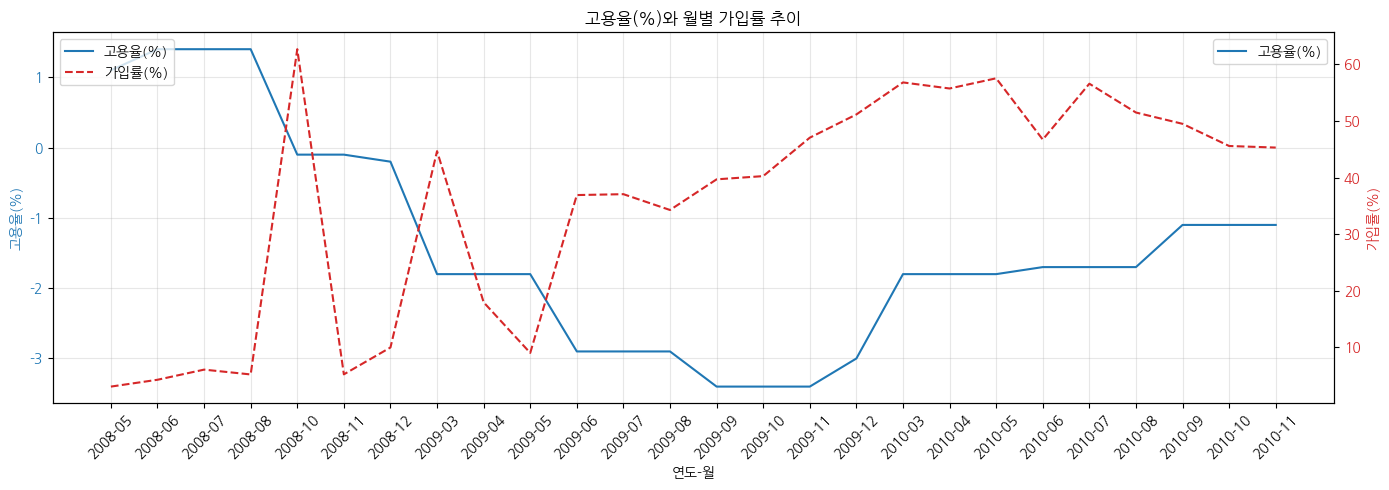

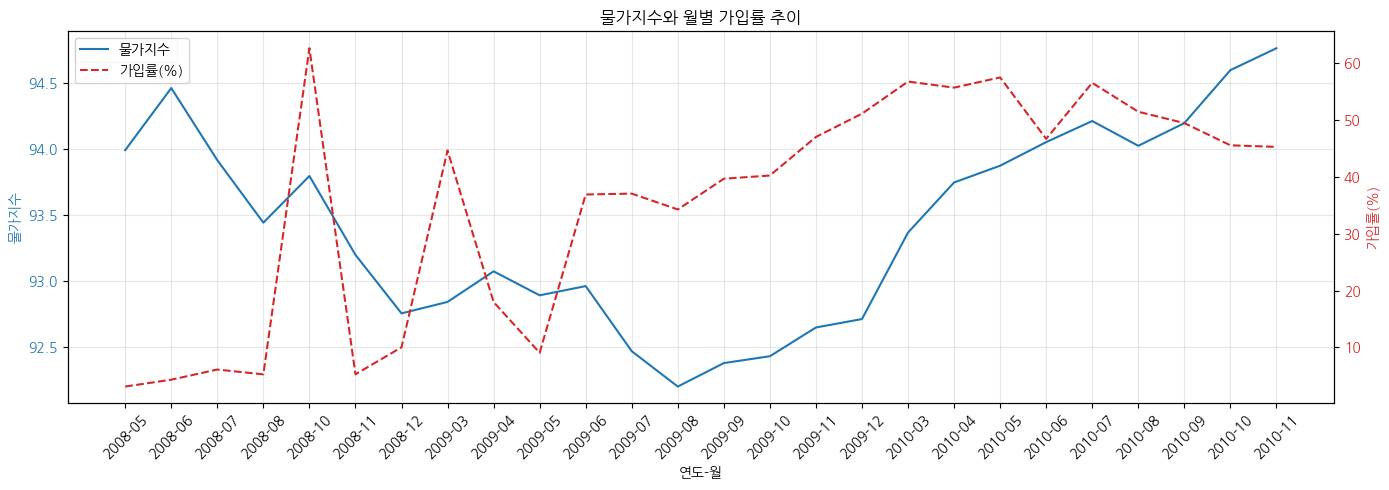

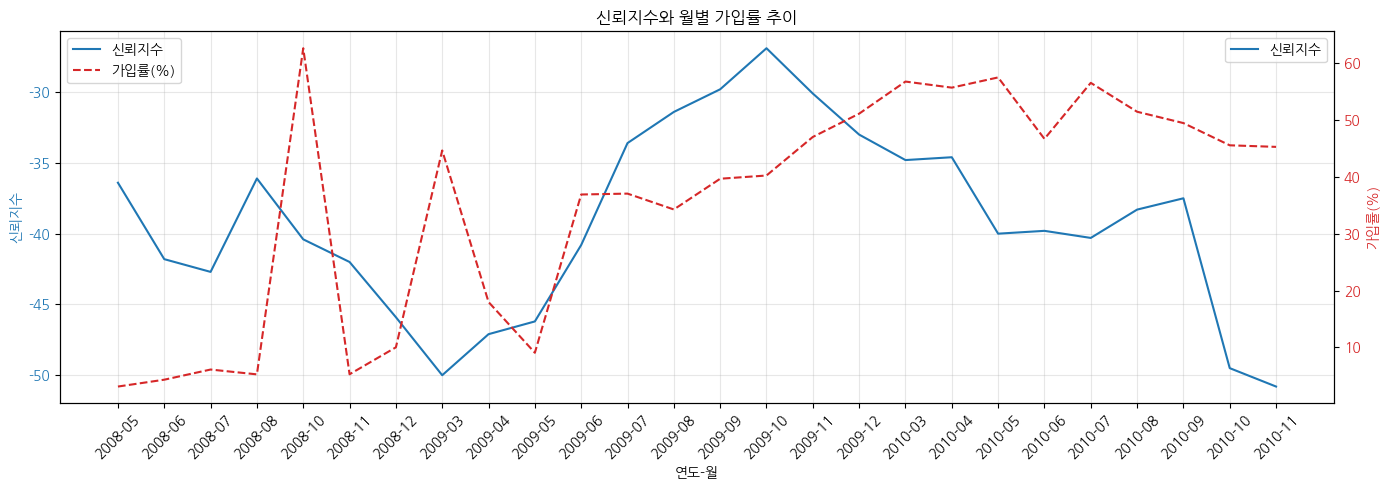

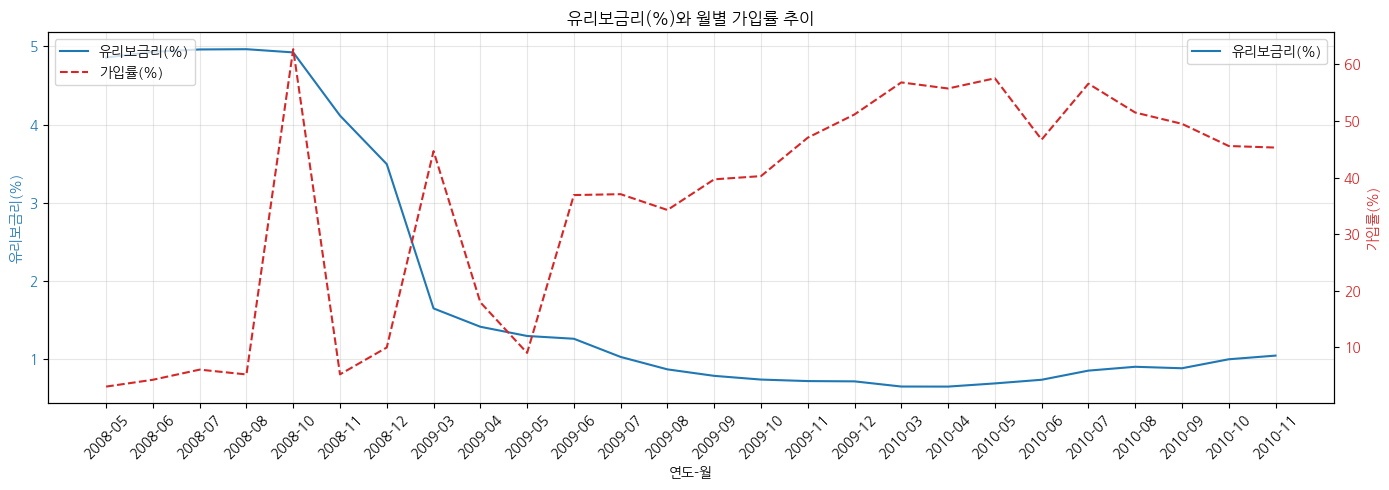

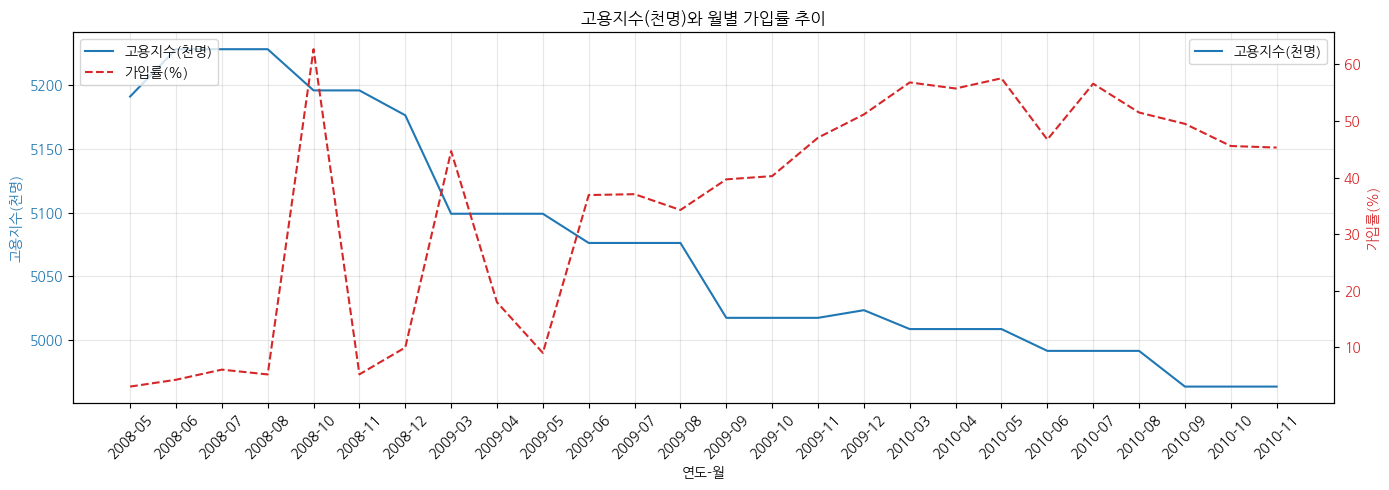

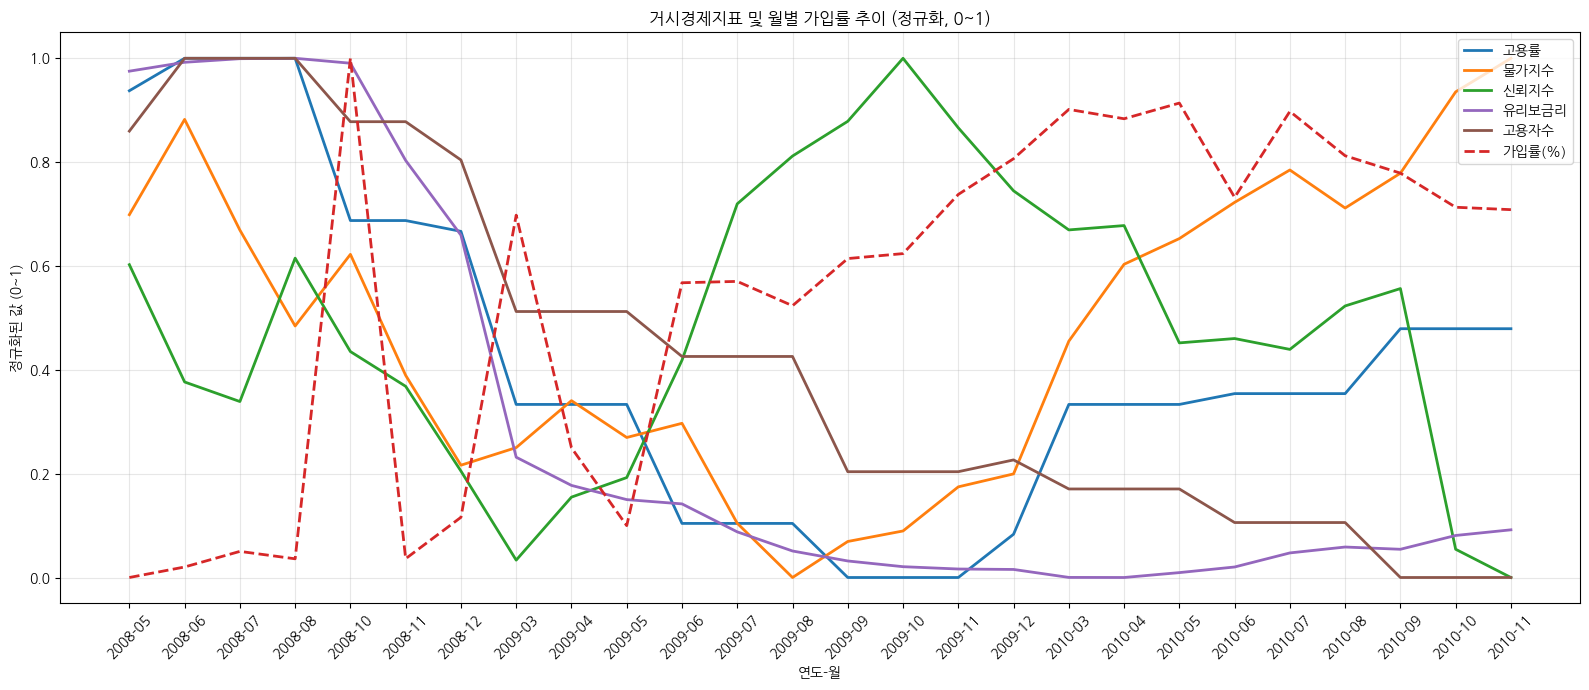

월별 거시경제지표와 가입률(%) 상관계수:
               고용률       물가지수      신뢰지수 유리보금리    고용자수 가입률(%)
         emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed 가입률(%)
 2008-05          1.1         93.994         -36.4     4.8577        5191    3.0916
 2008-06          1.4         94.465         -41.8     4.9316      5228.1    4.2981
 2008-07          1.4         93.918         -42.7     4.9616      5228.1    6.0883
 2008-08          1.4         93.444         -36.1     4.9648      5228.1    5.2367
 2008-10         -0.1         93.798         -40.4     4.9238      5195.8   62.6866
 2008-11         -0.1           93.2           -42     4.1149      5195.8    5.2544
 2008-12         -0.2         92.756         -45.9     3.4934      5176.3        10
 2009-03         -1.8         92.843           -50     1.6462      5099.1   44.6809
 2009-04         -1.8         93.075         -47.1     1.4117      5099.1   17.9821
 2009-05         -1.8         92.893         -46.2     1.2936      5099.1    9

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_commit_0_1.copy()
column_kr = df.get_head_att()
df['year_month'] = df['call_date'].dt.strftime('%Y-%m')

# 1. 월별 평균 거시경제지표 집계
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
monthly_macro = df.groupby('year_month')[macro_cols].mean()
monthly_macro.set_head_att(df.get_head_att())

# 2. 월별 가입률 집계
monthly_join = df.groupby('year_month')['y'].value_counts(normalize=True).unstack().fillna(0)
monthly_join.set_head_att(df.get_head_att())
monthly_join['가입률(%)'] = monthly_join['yes'] * 100

# 3. 개별 그래프 그리기
macro_kr = {
    'emp.var.rate': '고용율(%)',
    'cons.price.idx': '물가지수',
    'cons.conf.idx': '신뢰지수',
    'euribor3m': '유리보금리(%)',
    'nr.employed': '고용지수(천명)'
}

for col in macro_cols:
    plt.figure(figsize=(14, 5))
    ax1 = sns.lineplot(x=monthly_macro.index, y=monthly_macro[col], color='tab:blue', label=macro_kr[col])
    ax1.set_ylabel(macro_kr[col], color='tab:blue')
    ax1.set_xlabel('연도-월')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    # 가입률 보조축
    ax2 = ax1.twinx()
    sns.lineplot(x=monthly_join.index, y=monthly_join['가입률(%)'], color='tab:red', label='가입률(%)', ax=ax2, linestyle='--')
    ax2.set_ylabel('가입률(%)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # 범례
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.title(f"{macro_kr[col]}와 월별 가입률 추이")
    plt.tight_layout()
    plt.show()
    
# 2. 모든 거시경제지표 + 가입률을 하나의 그래프에 합치기
from sklearn.preprocessing import MinMaxScaler

# 데이터 준비
plot_df = monthly_macro.copy()
plot_df['가입률(%)'] = monthly_join['가입률(%)']

# 0~1 정규화
scaler = MinMaxScaler()
plot_df_norm = pd.DataFrame(
    scaler.fit_transform(plot_df),
    columns=plot_df.columns,
    index=plot_df.index
)

# 시각화
plt.figure(figsize=(16, 7))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown', 'tab:red']
for idx, col in enumerate(plot_df_norm.columns):
    label_kr = column_kr.get(col, col)  # 한글 매핑, 없으면 원래 이름
    linestyle = '--' if col == '가입률(%)' else '-'
    plt.plot(plot_df_norm.index, plot_df_norm[col], label=label_kr, color=colors[idx], linewidth=2, linestyle=linestyle)    
    # linestyle = '--' if col == '가입률(%)' else '-'
    # plt.plot(plot_df_norm.index, plot_df_norm[col], label=col, color=colors[idx], linewidth=2, linestyle=linestyle)

plt.title('거시경제지표 및 월별 가입률 추이 (정규화, 0~1)')
plt.xlabel('연도-월')
plt.ylabel('정규화된 값 (0~1)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 상관계수 분석
print("월별 거시경제지표와 가입률(%) 상관계수:")
corr_df = monthly_macro.copy()
corr_df['가입률(%)'] = monthly_join['가입률(%)']
corr_df1 = corr_df
#corr_df1.clear_head_att()
corr_df1.head_att(100)

print()
corr_df.corr()[['가입률(%)']].sort_values('가입률(%)', ascending=False).T.head_att()
#corr_df.corr()[['가입률(%)']].sort_values('가입률(%)', ascending=False).head_att()
# corr_df2 = corr_df.corr()[['가입률(%)']].sort_values('가입률(%)', ascending=False).T
# corr_df2.head_att()
#display(corr_df.corr()[['가입률(%)']].sort_values('가입률(%)', ascending=False))

del plot_df
del corr_df
del corr_df1
del df
import gc; gc.collect();


### 경제 지수와의 상관 관계 검토
- 신뢰 지수 :  0.21 약한 양의 상관 관계
- 물가 지수 :  0.10 약한 양의 상관 관계
- 고용율    : -0.59 강한 음의 상관 관계
- 유리보금리: -0.68 강한 음의 상관 관계
- 고용지수  : -0.77 강한 음의 상관 관계
- 경제가 어려울 수록 예금을 안 할 것 같지만 심리적으로는 조금이라도 예금을 해서 미래의 불확실정을 줄이려고 하는 심리가 있다.
  - 위키
  - "Precautionary savings"
  - https://en.wikipedia.org/wiki/Precautionary_savings


## 고유값 검토

In [18]:
df = df_commit_0_1.copy()
kr_columns = df.get_head_att()
columns = df.columns.to_list()

for col in columns:
    # 고유값이 20개 미만인 컬럼만(범주형 위주)
    if df[col].unique().size < 20:
        print(f"\n▶ ({kr_columns[col]}) {col} 분포표")
        # 고유값, 개수, 비율 계산
        value_counts = df[col].value_counts(dropna=False)
        value_ratio = df[col].value_counts(normalize=True, dropna=False) * 100
        
        try:
            grouped = df.groupby(col)['y'].value_counts()
            if not grouped.empty:
                group_counts = grouped.unstack(fill_value=0)
                group_counts = group_counts.reindex(columns=['no', 'yes'], fill_value=0)
                group_counts.columns = ['no_count', 'yes_count']
                # 고유값 인덱스 맞추기
                merged = pd.DataFrame({
                    '개수': value_counts,
                    '분포비율(%)': value_ratio
                })
                merged = merged.join(group_counts, how='left').fillna(0)
                merged['yes비율(%)'] = merged['yes_count'] / merged['개수'] * 100
                merged = merged.T
                merged.set_head_att(kr_columns)
                merged.head_att(20)
                # print("-" * 30)
                # print(merged)
                # print("=" * 30)
            else:
                print(f"  [경고] {col} 컬럼의 그룹별 y 분포 데이터가 없습니다.")
        except Exception as e:
            print(f"  [예외] {col} 컬럼 groupby-분포표 생성 실패: {e}")
     
del df
import gc; gc.collect();   


▶ (직업) job 분포표
              행정직      현장직     기술자 서비스직     관리자  은퇴자       기업가        자영업 가사도우미     실업자    학생    미상
              admin. blue-collar technician services management retired entrepreneur self-employed  housemaid unemployed student unknown
        개수   10422        9254       6743     3969       2924    1720         1456          1421       1060       1014     875     330
 분포비율(%) 25.3035     22.4677    16.3713   9.6363     7.0992   4.176        3.535          3.45     2.5736     2.4619  2.1244  0.8012
    no_count    9070        8616       6013     3646       2596    1286         1332          1272        954        870     600     293
   yes_count    1352         638        730      323        328     434          124           149        106        144     275      37
  yes비율(%) 12.9726      6.8943     10.826   8.1381    11.2175 25.2326       8.5165       10.4856         10    14.2012 31.4286 11.2121

▶ (결혼) marital 분포표
                기혼    미혼     이혼    미상
            


▶ (직업) job 분포표


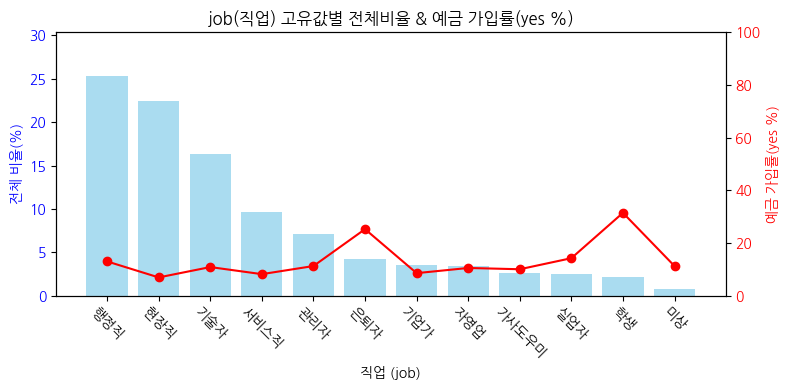


▶ (결혼) marital 분포표


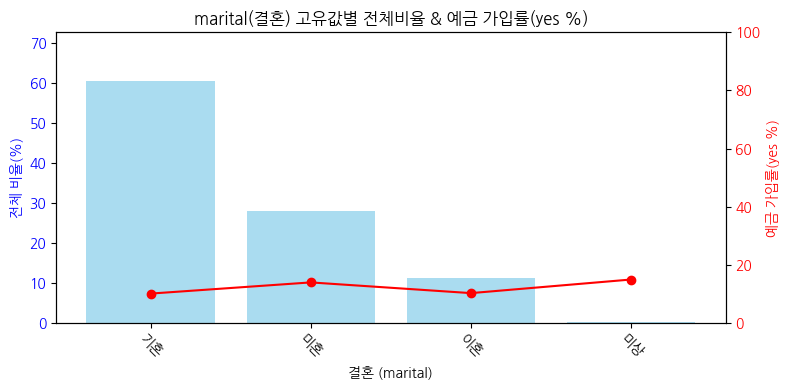


▶ (교육) education 분포표


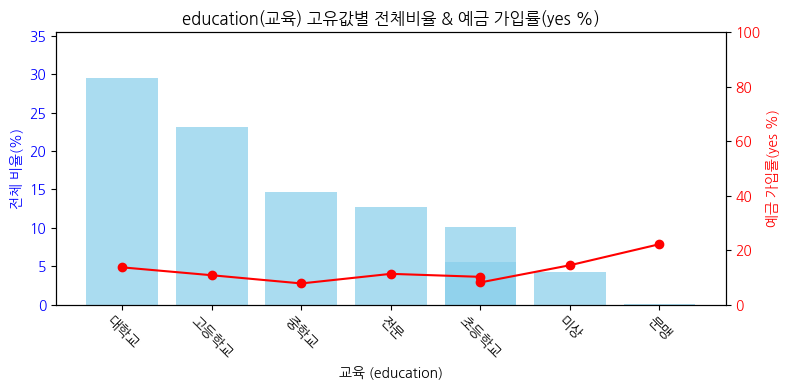


▶ (신용불량) default 분포표


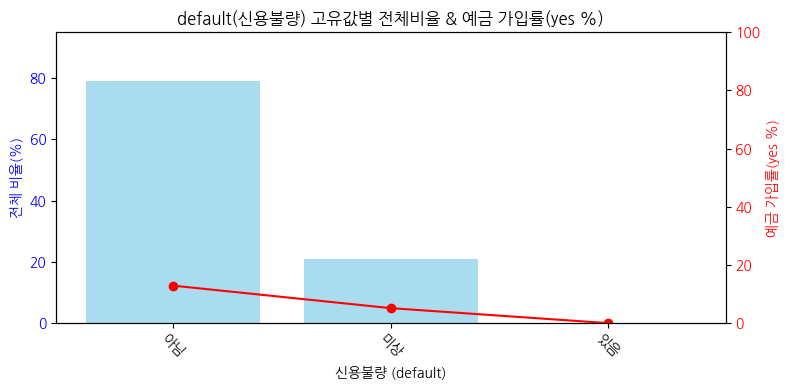


▶ (주택대출) housing 분포표


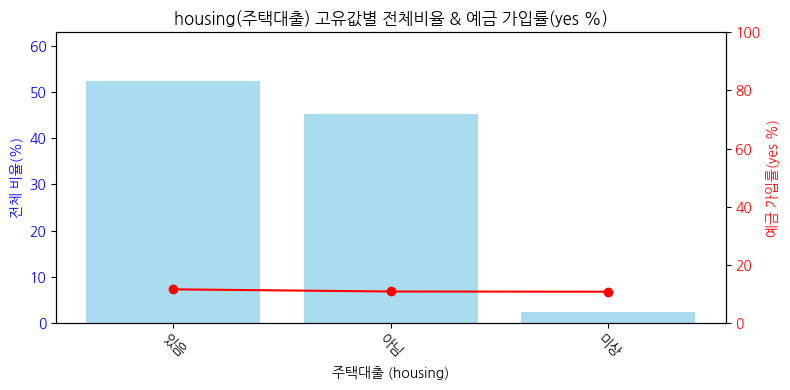


▶ (개인대출) loan 분포표


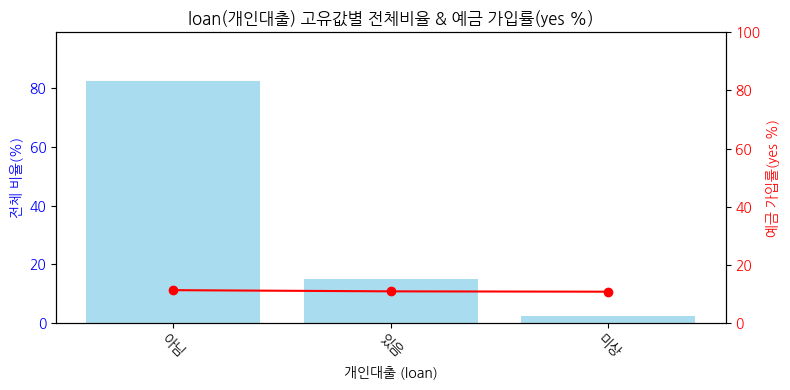


▶ (연락방식) contact 분포표


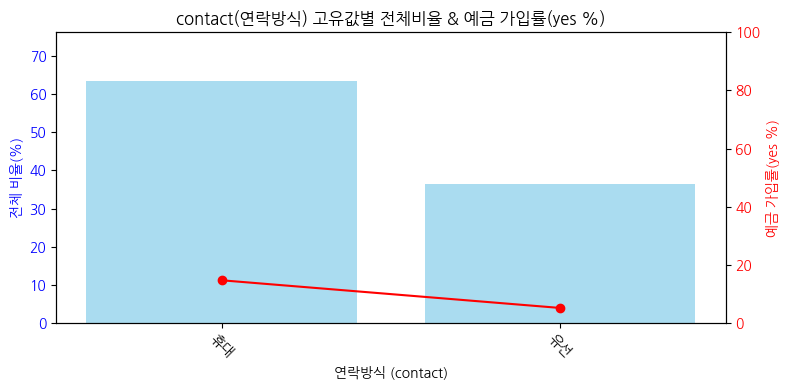


▶ (연락월) month 분포표


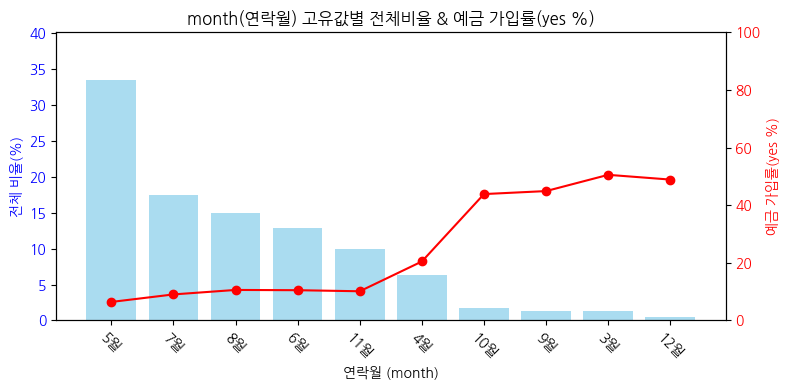


▶ (연락요일) day_of_week 분포표


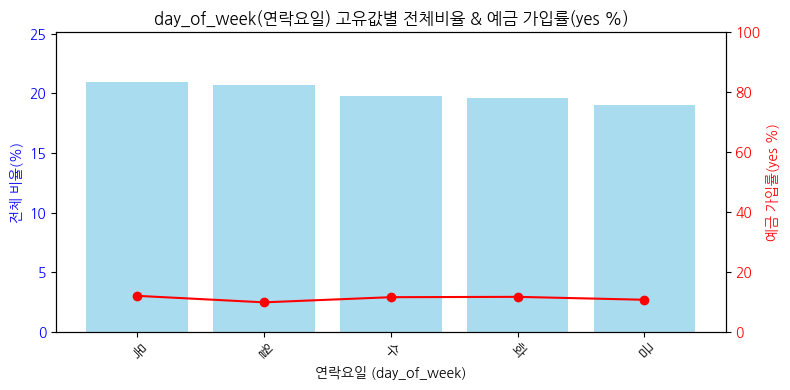


▶ (연락횟수) campaign 분포표


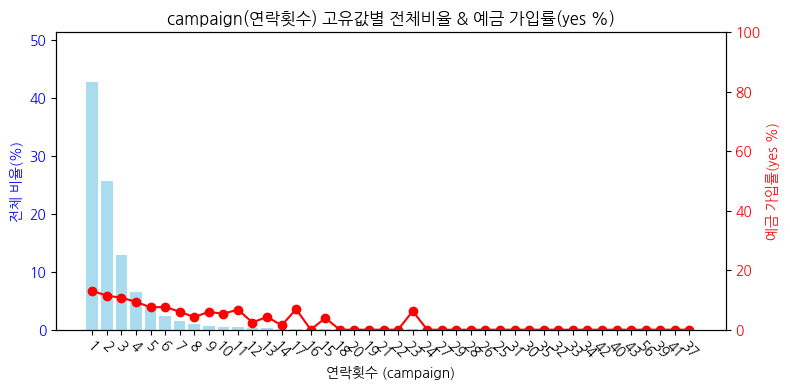


▶ (경과일수) pdays 분포표


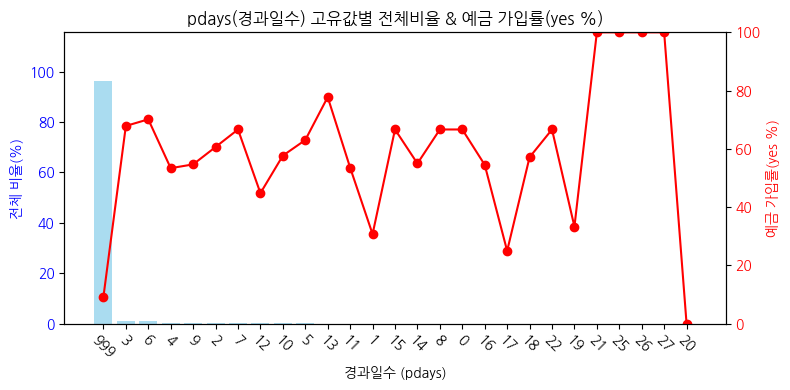


▶ (과거연락) previous 분포표


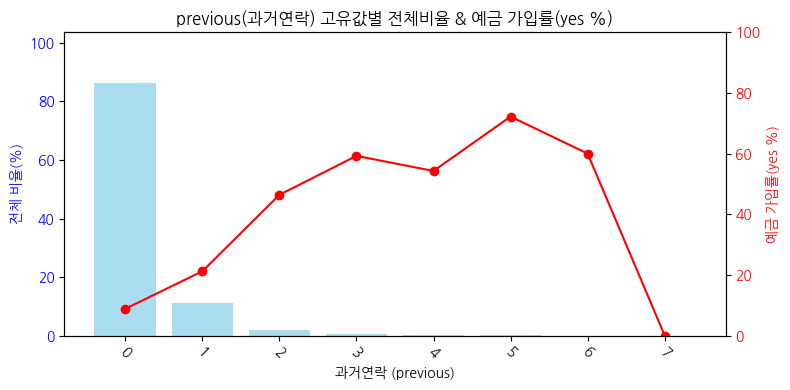


▶ (과거결과) poutcome 분포표


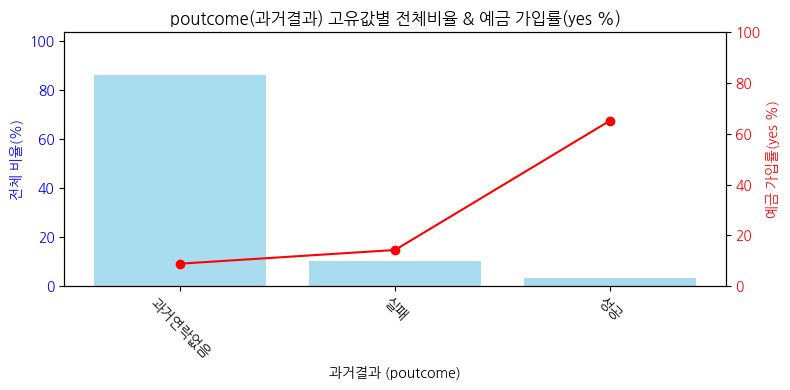


▶ (고용률) emp.var.rate 분포표


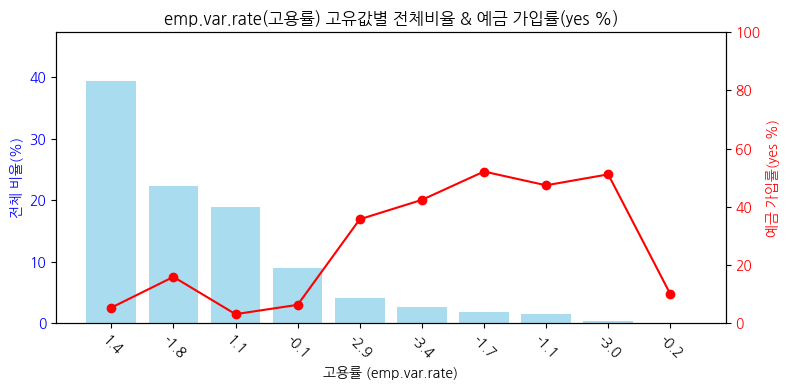


▶ (물가지수) cons.price.idx 분포표


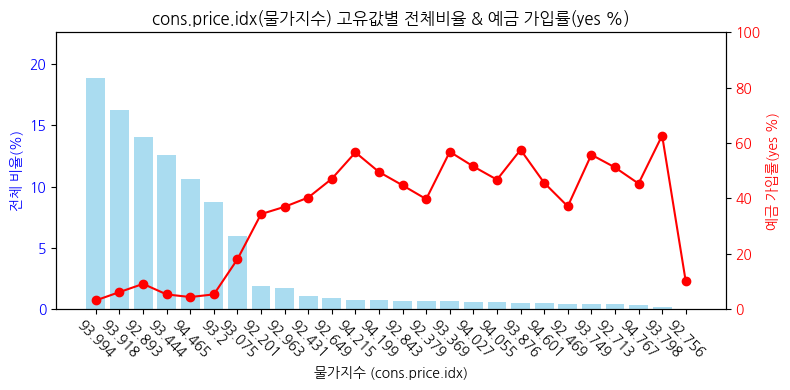


▶ (신뢰지수) cons.conf.idx 분포표


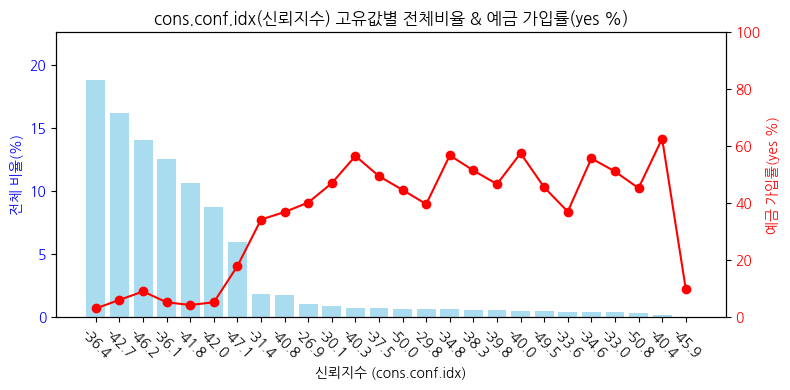


▶ (고용자수) nr.employed 분포표


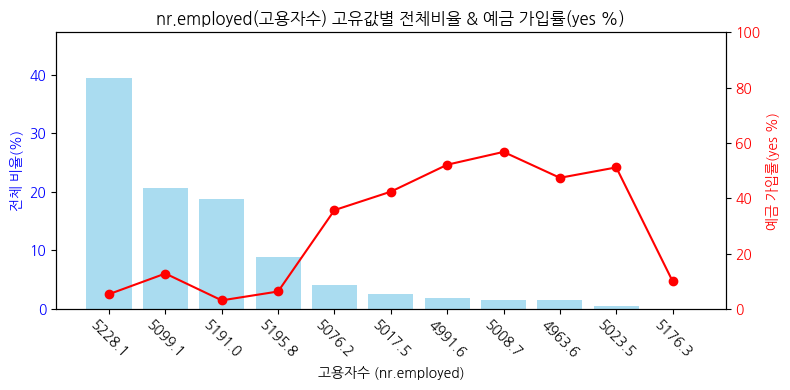


▶ (가입여부) y 분포표
  [예외] y 컬럼 groupby-분포표 생성 실패: zero-size array to reduction operation maximum which has no identity

▶ (연락월) month_num 분포표


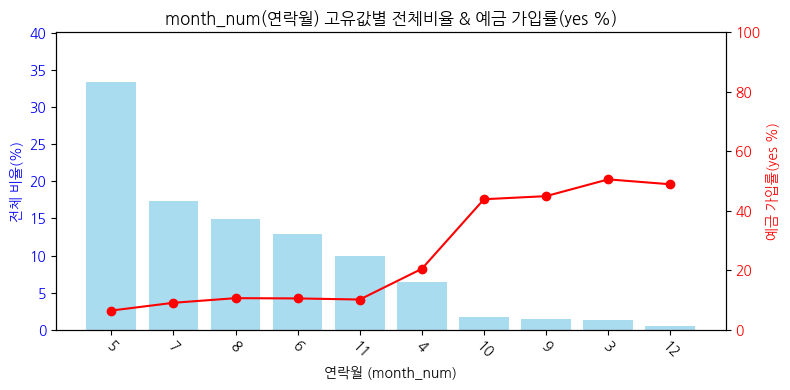


▶ (연락년) year 분포표


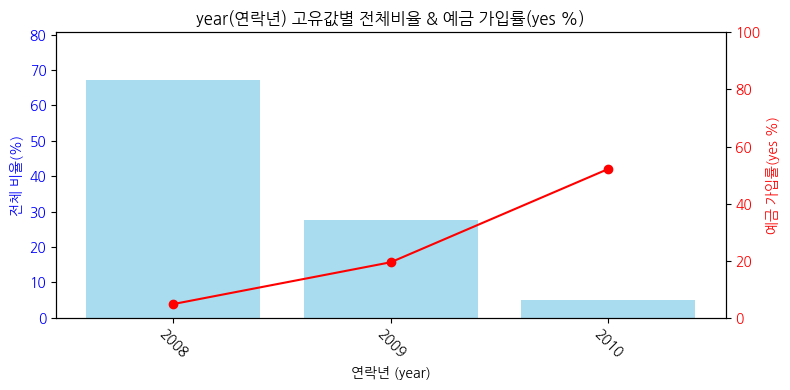


▶ (연락일) day_num 분포표


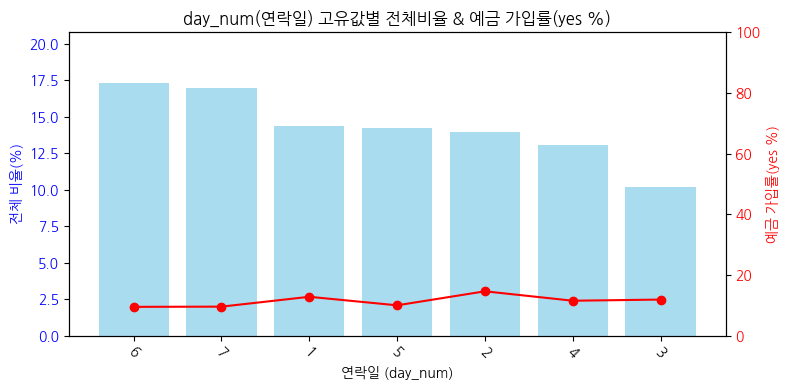

In [19]:
df = df_commit_0_1.copy()
kr_columns = df.get_head_att()
columns = df.columns.to_list()

for col in columns:
    # 고유값이 20개 미만인 컬럼만(범주형 위주)
    if df[col].unique().size < 50:
        print(f"\n▶ ({kr_columns[col]}) {col} 분포표")
        # 고유값, 개수, 비율 계산
        value_counts = df[col].value_counts(dropna=False)
        value_ratio = df[col].value_counts(normalize=True, dropna=False) * 100
        
        try:
            grouped = df.groupby(col)['y'].value_counts()
            if not grouped.empty:
                group_counts = grouped.unstack(fill_value=0)
                group_counts = group_counts.reindex(columns=['no', 'yes'], fill_value=0)
                group_counts.columns = ['no_count', 'yes_count']
                # 고유값 인덱스 맞추기
                merged = pd.DataFrame({
                    '개수': value_counts,
                    '분포비율(%)': value_ratio
                })
                merged = merged.join(group_counts, how='left').fillna(0)
                merged['yes비율(%)'] = merged['yes_count'] / merged['개수'] * 100
                
                # 한글 레이블 적용
                x_labels = [kr_columns.get(x, str(x)) for x in merged.index]

                fig, ax1 = plt.subplots(figsize=(8, 4))
                merged = merged.sort_values('개수', ascending=False)
                bar = ax1.bar(x_labels, merged['분포비율(%)'], color='skyblue', alpha=0.7, label='전체 비율(%)')
                ax1.set_ylabel('전체 비율(%)', color='blue')
                ax1.set_xlabel(f"{kr_columns.get(col, col)} ({col})")
                ax1.tick_params(axis='y', labelcolor='blue')
                ax1.set_ylim(0, merged['분포비율(%)'].max()*1.2)
                ax1.set_xticklabels(ax1.get_xticklabels(), rotation=-45)

                # yes 비율 라인
                ax2 = ax1.twinx()
                ax2.plot(x_labels, merged['yes비율(%)'], color='red', marker='o', label='예금 가입률(yes %)')
                ax2.set_ylabel('예금 가입률(yes %)', color='red')
                ax2.tick_params(axis='y', labelcolor='red')
                ax2.set_ylim(0, 100)
                ax2.set_xticklabels(ax2.get_xticklabels(), rotation=-45)

                plt.title(f"{col}({kr_columns.get(col, col)}) 고유값별 전체비율 & 예금 가입률(yes %)")
                plt.xticks(rotation=30)
                fig.tight_layout()
                plt.show()                
            else:
                print(f"  [경고] {col} 컬럼의 그룹별 y 분포 데이터가 없습니다.")
        except Exception as e:
            print(f"  [예외] {col} 컬럼 groupby-분포표 생성 실패: {e}")
    
del df
import gc; gc.collect();        

3. 주요 범주형 변수 분포 분석 (개별 그래프)
------------------------------


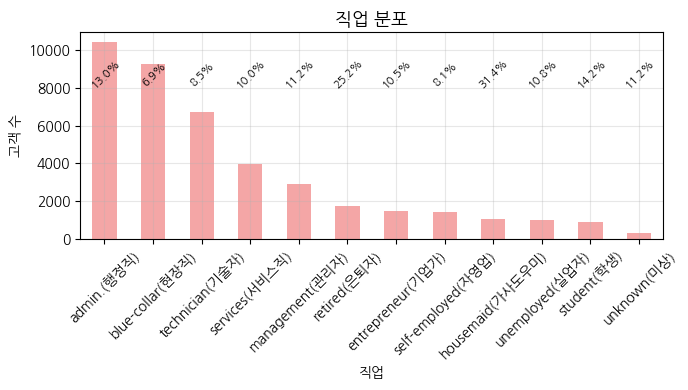

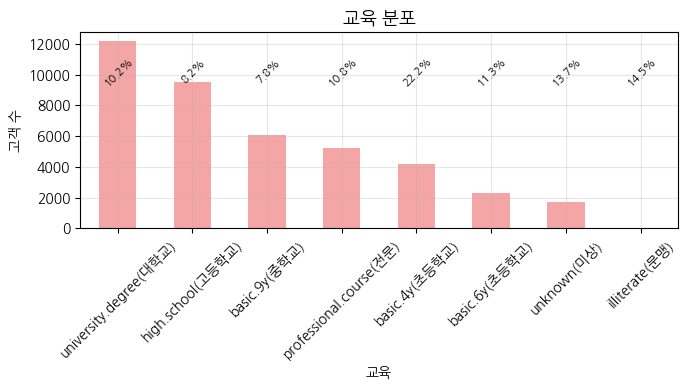

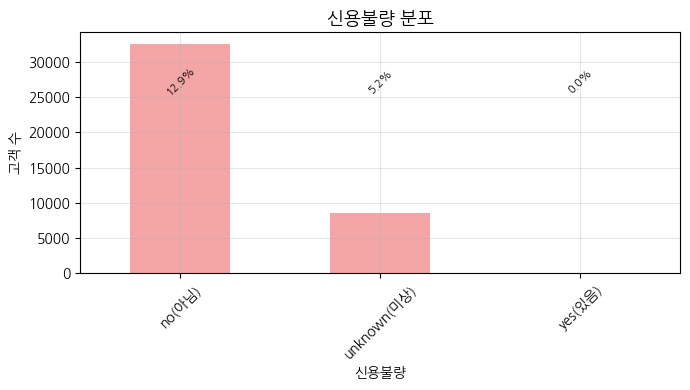

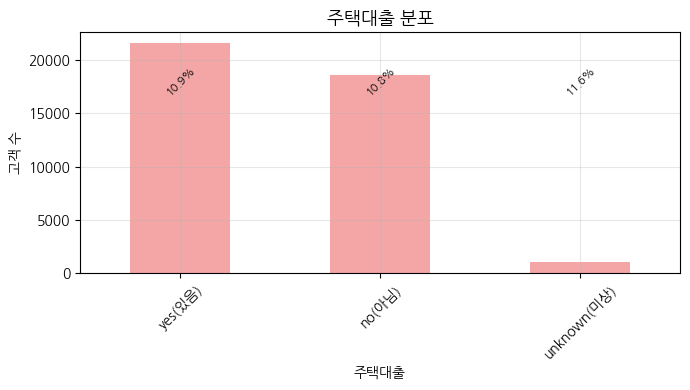

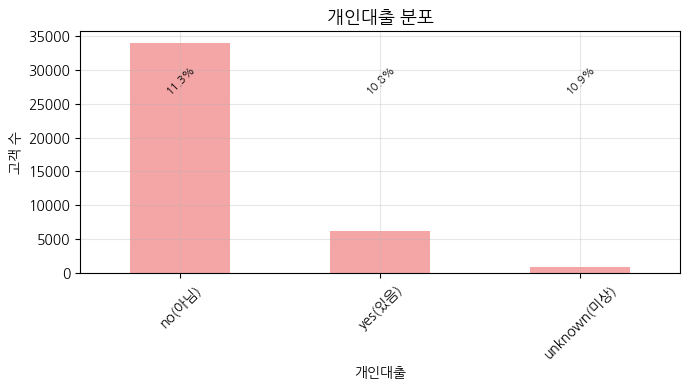

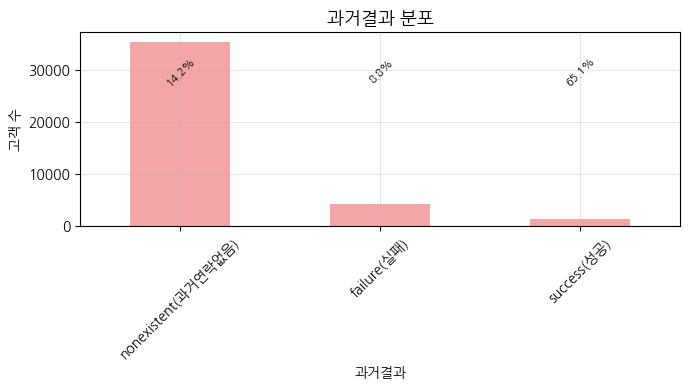



4. 숫자형 변수 이상치 분석
------------------------------


,변수,이상치_개수,이상치_비율(%),Q1,Q3,하한,상한
0,age,469,1.14,32.00,47.00,9.50,69.50
1,campaign,2406,5.84,1.00,3.00,-2.00,6.00
2,pdays,1515,3.68,999.00,999.00,999.00,999.00
3,previous,5625,13.66,0.00,0.00,0.00,0.00
4,emp.var.rate,0,0.00,-1.80,1.40,-6.60,6.20
5,cons.price.idx,0,0.00,93.08,93.99,91.70,95.37
6,cons.conf.idx,447,1.09,-42.70,-36.40,-52.15,-26.95
7,euribor3m,0,0.00,1.34,4.96,-4.08,10.39
8,nr.employed,0,0.00,5099.10,5228.10,4905.60,5421.60



이상치 비율이 5% 이상인 변수: campaign, previous
→ 이상치 처리 방안 검토 필요


5. 타겟 변수(y)와 주요 변수들의 관계
----------------------------------------
범주형 변수별 정기예금 가입률:

직업별 가입률:
  student: 31.4% (875명)
  retired: 25.2% (1,720명)
  unemployed: 14.2% (1,014명)
  admin.: 13.0% (10,422명)
  management: 11.2% (2,924명)
  unknown: 11.2% (330명)
  technician: 10.8% (6,743명)
  self-employed: 10.5% (1,421명)
  housemaid: 10.0% (1,060명)
  entrepreneur: 8.5% (1,456명)
  services: 8.1% (3,969명)
  blue-collar: 6.9% (9,254명)

교육별 가입률:
  illiterate: 22.2% (18명)
  unknown: 14.5% (1,731명)
  university.degree: 13.7% (12,168명)
  professional.course: 11.3% (5,243명)
  high.school: 10.8% (9,515명)
  basic.4y: 10.2% (4,176명)
  basic.6y: 8.2% (2,292명)
  basic.9y: 7.8% (6,045명)

신용불량별 가입률:
  no: 12.9% (32,588명)
  unknown: 5.2% (8,597명)
  yes: 0.0% (3명)

주택대출별 가입률:
  yes: 11.6% (21,576명)
  no: 10.9% (18,622명)
  unknown: 10.8% (990명)

개인대출별 가입률:
  no: 11.3% (33,950명)
  yes: 10.9% (6,248명)
  unknown: 10.8% (990명)

과거결과별 가입률:
  success: 65.1% (1,3

In [20]:
# 범주형 변수 분포 및 이상치 분석
df = df_commit_0_1.copy()

# 3. 범주형 변수 분포 분석
print("3. 주요 범주형 변수 분포 분석 (개별 그래프)")
print("-" * 30)

important_categorical = ['job', 'education', 'default', 'housing', 'loan', 'poutcome']

for col in important_categorical:
    plt.figure(figsize=(7, 4))
    col_kr = column_kr.get(col, col)
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', color='lightcoral', alpha=0.7)
    plt.title(f'{col_kr} 분포', fontsize=13, fontweight='bold')
    plt.xlabel(col_kr)
    plt.ylabel('고객 수')

    # 한글 레이블 리스트 생성
    x_labels = [f"{x}({category_value_kr.get(x, x)})" for x in value_counts.index]
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45)

    plt.grid(True, alpha=0.3)

    # 가입률 정보 추가
    crosstab = pd.crosstab(df[col], df['y'], normalize='index') * 100
    if 'yes' in crosstab.columns:
        for j, (category, yes_rate) in enumerate(crosstab['yes'].items()):
            plt.text(j, plt.ylim()[1] * 0.8, f'{yes_rate:.1f}%',
                     ha='center', va='center', fontweight='bold', color='black', fontsize=8, rotation=45)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60 + "\n")

# 4. 특이값 및 이상치 분석
print("4. 숫자형 변수 이상치 분석")
print("-" * 30)

model_numeric_columns = ['age', 'campaign', 'pdays', 'previous',
                        'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                        'euribor3m', 'nr.employed']

outlier_summary = []
for col in model_numeric_columns:
    data_clean = df[col].dropna()

    Q1 = data_clean.quantile(0.25)
    Q3 = data_clean.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
    outlier_ratio = len(outliers) / len(data_clean) * 100

    outlier_summary.append({
        '변수': col,
        '이상치_개수': len(outliers),
        '이상치_비율(%)': round(outlier_ratio, 2),
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        '하한': round(lower_bound, 2),
        '상한': round(upper_bound, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# 이상치가 많은 변수 확인
high_outlier_vars = outlier_df[outlier_df['이상치_비율(%)'] > 5]['변수'].tolist()
if high_outlier_vars:
    print(f"\n이상치 비율이 5% 이상인 변수: {', '.join(high_outlier_vars)}")
    print("→ 이상치 처리 방안 검토 필요")

print("\n" + "="*60 + "\n")

# 5. 타겟 변수와 주요 변수들의 관계 분석
print("5. 타겟 변수(y)와 주요 변수들의 관계")
print("-" * 40)

# 범주형 변수별 가입률 분석
print("범주형 변수별 정기예금 가입률:")
for col in important_categorical:
    col_kr = column_kr.get(col, col)
    print(f"\n{col_kr}별 가입률:")
    crosstab = pd.crosstab(df[col], df['y'], normalize='index') * 100
    if 'yes' in crosstab.columns:
        yes_rates = crosstab['yes'].sort_values(ascending=False)
        for category, rate in yes_rates.items():
            count = df[df[col] == category].shape[0]
            print(f"  {category}: {rate:.1f}% ({count:,}명)")

print("\n" + "="*60)
print("분석 완료: 데이터 분포 및 특성 파악")

del df
import gc; gc.collect();   

# > 작업중 < campaign 검토

In [22]:
df = df_commit_0_1.copy()
columns_kr = df.get_head_att()

print("조건을 만족하는 경우 (pdays=999, duration=0)에서 campaign별 y 분포:")
campaign_groups = df.groupby('campaign')['y'].value_counts().unstack(fill_value=0)
campaign_groups['total'] = campaign_groups.sum(axis=1)
campaign_groups['yes_ratio(%)'] = campaign_groups.get('yes', 0) / campaign_groups['total'] * 100

# 결과 출력
for campaign, row in campaign_groups.iterrows():
    yes = row.get('yes', 0)
    no = row.get('no', 0)
    total = row['total']
    yes_ratio = row['yes_ratio(%)']
    print(f"campaign={campaign}: 전체={total}건, yes={yes}건, no={no}건, 가입률={yes_ratio:.2f}%")



조건을 만족하는 경우 (pdays=999, duration=0)에서 campaign별 y 분포:
campaign=1: 전체=17642.0건, yes=2300.0건, no=15342.0건, 가입률=13.04%
campaign=2: 전체=10570.0건, yes=1211.0건, no=9359.0건, 가입률=11.46%
campaign=3: 전체=5341.0건, yes=574.0건, no=4767.0건, 가입률=10.75%
campaign=4: 전체=2651.0건, yes=249.0건, no=2402.0건, 가입률=9.39%
campaign=5: 전체=1599.0건, yes=120.0건, no=1479.0건, 가입률=7.50%
campaign=6: 전체=979.0건, yes=75.0건, no=904.0건, 가입률=7.66%
campaign=7: 전체=629.0건, yes=38.0건, no=591.0건, 가입률=6.04%
campaign=8: 전체=400.0건, yes=17.0건, no=383.0건, 가입률=4.25%
campaign=9: 전체=283.0건, yes=17.0건, no=266.0건, 가입률=6.01%
campaign=10: 전체=225.0건, yes=12.0건, no=213.0건, 가입률=5.33%
campaign=11: 전체=177.0건, yes=12.0건, no=165.0건, 가입률=6.78%
campaign=12: 전체=125.0건, yes=3.0건, no=122.0건, 가입률=2.40%
campaign=13: 전체=92.0건, yes=4.0건, no=88.0건, 가입률=4.35%
campaign=14: 전체=69.0건, yes=1.0건, no=68.0건, 가입률=1.45%
campaign=15: 전체=51.0건, yes=2.0건, no=49.0건, 가입률=3.92%
campaign=16: 전체=51.0건, yes=0.0건, no=51.0건, 가입률=0.00%
campaign=17: 전체=58.0건, yes=4.0건, no=54.0건, 가입률=6.

# 중단점 박스 플롯

In [23]:
CONTINUE_TO_df_next = True  # 다음단계 시작하려면 True로 변경

if not CONTINUE_TO_df_next:
    print("=" * 70)
    print("")
    print("준비된 데이터셋:")
    df_commit_0_1.head_att(10)
    raise ValueError("모델링 단계로 진행하려면 CONTINUE_TO_df_next = True로 변경하세요")
else:
    print("모델링 단계로 진행합니다...")


모델링 단계로 진행합니다...


In [81]:
# 숫자형 변수의 현실적이지 않은 값 검토
df = df_commit_0_1.copy()

print("=== 숫자형 변수의 현실적 범위 검토 ===")
print()

# 각 변수별 현실적 범위 정의 및 검토
realistic_ranges = {
    'age': {'min': 18, 'max': 95, 'description': '성인 고객 연령'},
    'campaign': {'min': 1, 'max': 20, 'description': '현재 캠페인 연락 횟수'},
    'pdays': {'min': 0, 'max': 365, 'description': '이전 캠페인 후 경과 일수'},
    'previous': {'min': 0, 'max': 10, 'description': '이전 캠페인 연락 횟수'},
    'duration': {'min': 0, 'max': 3600, 'description': '통화 지속 시간(초)'},
    'emp.var.rate': {'min': -5, 'max': 5, 'description': '고용 변동률(%)'},
    'cons.price.idx': {'min': 90, 'max': 110, 'description': '소비자 물가지수'},
    'cons.conf.idx': {'min': -60, 'max': -20, 'description': '소비자 신뢰지수'},
    'euribor3m': {'min': 0, 'max': 10, 'description': '3개월 유리보 금리(%)'},
    'nr.employed': {'min': 4900, 'max': 5300, 'description': '고용자 수(천명)'}
}

unrealistic_summary = []

for col, range_info in realistic_ranges.items():
    if col in df.columns:
        data_clean = df[col].dropna()

        # 현재 데이터 범위
        actual_min = data_clean.min()
        actual_max = data_clean.max()

        # 현실적 범위를 벗어나는 값들
        unrealistic_low = data_clean[data_clean < range_info['min']]
        unrealistic_high = data_clean[data_clean > range_info['max']]

        total_unrealistic = len(unrealistic_low) + len(unrealistic_high)
        unrealistic_ratio = (total_unrealistic / len(data_clean)) * 100

        unrealistic_summary.append({
            '변수': col,
            '변수명_한글': column_kr.get(col, col),
            '설명': range_info['description'],
            '현실적_최소': range_info['min'],
            '현실적_최대': range_info['max'],
            '실제_최소': round(actual_min, 2),
            '실제_최대': round(actual_max, 2),
            '비현실적_낮은값': len(unrealistic_low),
            '비현실적_높은값': len(unrealistic_high),
            '총_비현실적값': total_unrealistic,
            '비현실적_비율(%)': round(unrealistic_ratio, 2)
        })

# 결과 출력
unrealistic_df = pd.DataFrame(unrealistic_summary)
print("숫자형 변수별 현실적 범위 검토 결과:")
#display(unrealistic_df)
unrealistic_df.head_att(30)

print("\n" + "="*80)

# 특히 문제가 되는 변수들 상세 분석
print("\n=== 비현실적 값이 있는 변수 상세 분석 ===")

problem_vars = unrealistic_df[unrealistic_df['총_비현실적값'] > 0]

if len(problem_vars) > 0:
    for _, row in problem_vars.iterrows():
        col = row['변수']
        col_kr = row['변수명_한글']

        print(f"\n{col_kr} ({col}) 상세 분석:")
        print("-" * 40)

        data_clean = df[col].dropna()
        range_info = realistic_ranges[col]

        # 비현실적으로 낮은 값들
        if row['비현실적_낮은값'] > 0:
            low_values = data_clean[data_clean < range_info['min']]
            print(f"비현실적으로 낮은 값 ({len(low_values)}개):")
            print(f"  범위: {low_values.min()} ~ {low_values.max()}")
            #print(f"  예시: {sorted(low_values.unique())[:10]}")

        # 비현실적으로 높은 값들
        if row['비현실적_높은값'] > 0:
            high_values = data_clean[data_clean > range_info['max']]
            print(f"비현실적으로 높은 값 ({len(high_values)}개):")
            print(f"  범위: {high_values.min()} ~ {high_values.max()}")
            #print(f"  예시: {sorted(high_values.unique(), reverse=True)[:10]}")

del df
import gc; gc.collect();   

=== 숫자형 변수의 현실적 범위 검토 ===

숫자형 변수별 현실적 범위 검토 결과:
             변수 변수명_한글                     설명 현실적_최소 현실적_최대 실제_최소 실제_최대 비현실적_낮은값 비현실적_높은값 총_비현실적값 비현실적_비율(%)
 0            age        나이           성인 고객 연령          18          95        17        98               5               2             7             0.02
 1       campaign    연락횟수    현재 캠페인 연락 횟수           1          20         1        56               0             157           157             0.38
 2          pdays    경과일수 이전 캠페인 후 경과 일수           0         365         0       999               0           39673         39673            96.32
 3       previous    과거연락    이전 캠페인 연락 횟수           0          10         0         7               0               0             0                0
 4       duration    통화시간       통화 지속 시간(초)           0        3600         0      4918               0               5             5             0.01
 5   emp.var.rate      고용률           고용 변동률(%)          -5           5      -3.4       1.4 

## 비현실적인 값 검토
- 25.07.24 현재는 삭제 하지 않음
- 모델링 결과에 따라 삭제 여부 결정

1. 나이(age) 변수:
   - 17세 고객: 데이터 입력 오류 가능성 높음 → 유지
   - 96~98세 고객: 실제 가능하나 매우 드문 경우 → 유지

2. 연락횟수(campaign) 변수:
   - 25회 이상 연락: 고객 피로도 극심, 실제 효과 의문
   - 데이터 유지
   - 스토킹 모니터링 필요

3. 전체적 처리 방향:
   - 비현실적 값 비율이 매우 낮음 (0.1% 미만)
   - 모델 성능에 큰 영향 없을 것으로 예상
   - 보수적 접근: 상한/하한 처리
   - 적극적 접근: 해당 레코드 제거

## 비현실적인 값 처리

In [82]:
# 비현실적인 값들의 구체적인 내용 출력
df = df_commit_0_1.copy()

# 1. 나이(age) 비현실적 값
age_too_young = df[df['age'] < 18]
age_too_old = df[df['age'] > 95]

print("=== 비현실적 나이(age) 값 ===")
if not age_too_young.empty:
    print(f"- 18세 미만: {len(age_too_young)}건")
    #display(age_too_young[['age', 'job', 'marital', 'education', 'y']].head())
    age_too_young[['age', 'job', 'marital', 'education', 'y']].head_att(50)
else:
    print("- 18세 미만 없음")

if not age_too_old.empty:
    print(f"- 95세 초과: {len(age_too_old)}건")
    #display(age_too_old[['age', 'job', 'marital', 'education', 'y']].head())
    age_too_old[['age', 'job', 'marital', 'education', 'y']].head_att(50)
else:
    print("- 95세 초과 없음")

# 2. 연락횟수(campaign) 비현실적 값
campaign_too_high = df[df['campaign'] > 20]

print("\n=== 비현실적 연락횟수(campaign) 값 ===")
if not campaign_too_high.empty:
    print(f"- 20회 초과: {len(campaign_too_high)}건")
    #display(campaign_too_high[['campaign', 'age', 'job', 'marital', 'education', 'y']].head())
    campaign_too_high[['campaign', 'age', 'job', 'marital', 'education', 'y']].head_att(20)
else:
    print("- 20회 초과 없음")

# 전체 영향 요약
total_records = len(df)
unrealistic_age = len(age_too_young) + len(age_too_old)
unrealistic_campaign = len(campaign_too_high)
both_unrealistic = len(df[((df['age'] < 18) | (df['age'] > 95)) & (df['campaign'] > 20)])

print(f"\n전체 데이터: {total_records:,}건")
print(f"비현실적 나이: {unrealistic_age}건 ({unrealistic_age/total_records*100:.3f}%)")
print(f"비현실적 연락횟수: {unrealistic_campaign}건 ({unrealistic_campaign/total_records*100:.3f}%)")
print(f"둘 다 비현실적: {both_unrealistic}건")
print(f"총 비현실적 값을 가진 고객: {unrealistic_age + unrealistic_campaign - both_unrealistic}건")
print(f"전체 대비 비율: {(unrealistic_age + unrealistic_campaign - both_unrealistic)/total_records*100:.3f}%")

# 비현실적인 값 적용안함
# df_commit_0_1_1 = df.copy()
# df_commit_0_1 = df.copy()

del df
import gc; gc.collect();

=== 비현실적 나이(age) 값 ===
- 18세 미만: 5건
       나이    직업    결혼      교육 가입여부
        age     job marital education        y
 37140   17 student  single   unknown       no
 37539   17 student  single  basic.9y       no
 37558   17 student  single  basic.9y       no
 37579   17 student  single  basic.9y      yes
 38274   17 student  single   unknown      yes
- 95세 초과: 2건
       나이    직업    결혼      교육 가입여부
        age     job marital education        y
 38452   98 retired married  basic.4y      yes
 38455   98 retired married  basic.4y      yes

=== 비현실적 연락횟수(campaign) 값 ===
- 20회 초과: 157건
      연락횟수 나이          직업     결혼                교육 가입여부
      campaign  age           job  marital           education        y
 3219       23   39   blue-collar  married            basic.9y      yes
 3370       22   31        admin.   single         high.school       no
 3413       23   32        admin. divorced         high.school       no
 3438       25   35    unemployed  married   university.degree      

# 전처리

## 파생 변수

In [26]:
# 파생 변수 생성
df = df_commit_0_1.copy()

def get_economic_score(row):
    # 직업 점수
    job_score = {
        'management': 4, 'admin.': 3, 'technician': 2, 'entrepreneur': 2,
        'services': 1, 'self-employed': 1, 'blue-collar': 0, 'retired': 0,
        'student': -1, 'unemployed': -3, 'housemaid': -1, 'unknown': 0
    }
    # 교육 점수
    edu_score = {
        'university.degree': 3, 'professional.course': 2, 'high.school': 1,
        'basic.9y': 0, 'basic.6y': -1, 'basic.4y': -1, 'illiterate': -2, 'unknown': 0
    }
    # 나이 점수
    age = row['age']
    if 25 <= age <= 35:
        age_score = 2
    elif 36 <= age <= 50:
        age_score = 3
    elif 51 <= age <= 60:
        age_score = 2
    elif age >= 61:
        age_score = 1
    else:
        age_score = 0
    # 결혼 점수
    marital_score = {'married': 1, 'single': 0, 'divorced': -1, 'unknown': 0}
    # 합산
    total = (
        job_score.get(row['job'], 0) +
        edu_score.get(row['education'], 0) +
        age_score +
        marital_score.get(row['marital'], 0)
    )
    return total

df['economic_score'] = df.apply(get_economic_score, axis=1)

# 등급화 (예시)
def economic_grade(score):
    if score >= 7:
        return '상'
    elif score >= 4:
        return '중상'
    elif score >= 1:
        return '중'
    elif score >= -2:
        return '중하'
    else:
        return '하'

df['economic_grade'] = df['economic_score'].apply(economic_grade)

df.set_head_att('economic_score', '경제적점수')

# 신용등급 점수 계산 함수
def get_credit_score(row):
    # default 점수
    if row['default'] == 'no':
        default_score = 3
    elif row['default'] == 'yes':
        default_score = -5
    else:
        default_score = 0

    # housing 점수
    if row['housing'] == 'yes':
        housing_score = 2
    else:
        housing_score = 0

    # loan 점수
    if row['loan'] == 'no':
        loan_score = 1
    elif row['loan'] == 'yes':
        loan_score = -1
    else:
        loan_score = 0

    return default_score + housing_score + loan_score

# 신용등급 등급화 함수
def credit_grade(score):
    if score >= 5:
        return 'A'
    elif score >= 3:
        return 'B'
    elif score >= 1:
        return 'C'
    elif score >= -1:
        return 'D'
    else:
        return 'E'

df['credit_score'] = df.apply(get_credit_score, axis=1)
df['credit_grade'] = df['credit_score'].apply(credit_grade)
df.set_head_att('credit_score', '신용점수')
df.set_head_att('credit_grade', '신용등급')

# 거시경제 변화량 추가
df['year_month'] = df['call_date'].dt.strftime('%Y-%m')
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
monthly_macro = df.groupby('year_month')[macro_cols].mean().sort_index()

for col in macro_cols:
    monthly_macro[f'{col}_chg_pct'] = monthly_macro[col].pct_change().fillna(0) * 100
    monthly_macro[f'{col}_chg_diff'] = monthly_macro[col].diff().fillna(0)

columns_kr = df.get_head_att()
for col in macro_cols:
    df = df.merge(
        monthly_macro[[f'{col}_chg_pct', f'{col}_chg_diff']].reset_index(),
        left_on='year_month', right_on='year_month', how='left'
    )
df.set_head_att(columns_kr)

# 고위험군 여부 (신용등급 E 또는 경제점수 하위 20%)
if 'credit_grade' in df.columns:
    credit_grade_e = (df['credit_grade'] == 'E')
else:
    credit_grade_e = (df['credit_score'] <= -2)
economic_score_20p = df['economic_score'] <= df['economic_score'].quantile(0.2)
df['is_high_risk'] = ((credit_grade_e) | (economic_score_20p)).astype(int)

# 한글 레이블(선택)
df.set_head_att('is_high_risk', '고위험군여부')


df_commit_0_2 = df.copy()


파생 변수 목록 및 의미

| 변수명                   | 의미 및 산출 방식                                                                                  |
|--------------------------|---------------------------------------------------------------------------------------------------|
| **economic_score**       | 개별 고객의 경제력 추정 점수<br>- 직업, 교육, 나이, 결혼상태를 점수화하여 합산<br>- (예: 고소득·고학력·중장년·기혼일수록 높음) |
| **economic_grade**       | economic_score를 등급화<br>- 상/중상/중/중하/하 등 5단계로 구분                                      |
| **credit_score**         | 개별 고객 신용점수<br>- default, housing, loan 정보를 점수화하여 합산<br>- (예: 신용불량·대출여부 등 반영)   |
| **credit_grade**         | credit_score를 등급화<br>- A~E 등급으로 구분 (A: 최우량, E: 위험)                                   |
| **year_month**           | 연락 시점의 연-월(YYYY-MM)                                                                         |
| **emp.var.rate_chg_pct**<br>**emp.var.rate_chg_diff**<br>**cons.price.idx_chg_pct**<br>**cons.price.idx_chg_diff**<br>**cons.conf.idx_chg_pct**<br>**cons.conf.idx_chg_diff**<br>**euribor3m_chg_pct**<br>**euribor3m_chg_diff**<br>**nr.employed_chg_pct**<br>**nr.employed_chg_diff** | 각 거시경제지표의 전월 대비 변화율(%) 및 차이<br>- 예: 고용률, 물가지수, 신뢰지수, 유리보금리, 고용자수 등<br>- 캠페인 시점의 경제환경 변동성 반영 |
| **is_existing_customer** | 기존 고객 여부<br>- 이전 캠페인 접촉 경험 여부 (1: 기존, 0: 신규)                                   |
| **contact_intensity**    | 총 접촉 횟수<br>- campaign + previous (현재 + 과거 연락 횟수 합)                                   |
| **is_high_risk**         | 고위험군 여부<br>- 신용등급 E 또는 경제점수 하위 20%에 해당하면 1, 아니면 0                           |

---

변수별 활용 예시 및 비즈니스 해석

- **economic_score / economic_grade**  
  → 고객의 잠재 소득력, 금융상품 적합성, 타겟팅 우선순위 판단에 활용

- **credit_score / credit_grade**  
  → 신용 위험도 평가, 마케팅 리스크 관리, 맞춤 상품 제안에 활용

- **거시경제 변화율/차이**  
  → 경제환경 변화가 캠페인 성과에 미치는 영향 분석, 시점별 전략 수립

- **is_existing_customer**  
  → 신규/기존 고객별 반응 차이 분석, 리텐션/재구매 전략에 활용

- **contact_intensity**  
  → 고객 피로도, 최적 연락 빈도, 과도 마케팅 방지 등 캠페인 효율화

- **is_high_risk**  
  → 고위험군 선별, 리스크 기반 차별화 마케팅, 비용 효율성 제고



In [27]:
df_commit_0_2.head_att(10)

   나이        직업    결혼                교육 신용불량 주택대출 개인대출  연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락    과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부    연락월 연락년              연락일  연락일     경제적점수 economic_grade     신용점수     신용등급 year_month emp.var.rate_chg_pct emp.var.rate_chg_diff cons.price.idx_chg_pct cons.price.idx_chg_diff cons.conf.idx_chg_pct cons.conf.idx_chg_diff euribor3m_chg_pct euribor3m_chg_diff nr.employed_chg_pct nr.employed_chg_diff 고위험군여부
    age         job marital           education  default  housing     loan   contact  month day_of_week duration campaign    pdays previous    poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y month_num   year           call_date day_num economic_score economic_grade credit_score credit_grade year_month emp.var.rate_chg_pct emp.var.rate_chg_diff cons.price.idx_chg_pct cons.price.idx_chg_diff cons.conf.idx_chg_pct cons.conf.idx_chg_diff euribor3m_chg_pct euribor3m_chg_diff nr.employed_chg_pct nr.employed_

## 1단계: 범주형 변수 인코딩

비즈니스 논리를 반영한 라벨 인코딩으로 차원 축소 및 해석력 향상

In [28]:
def create_conservative_encodings():
    """
    Conservative 인코딩 전략을 위한 인코딩 매핑 딕셔너리 생성
    비즈니스 논리를 반영한 순서형 인코딩으로 차원 축소
    """
    print("=== Conservative 인코딩 매핑 생성 ===")

    # 1. 신용 관련 변수들: 리스크 단계 인코딩 (-1: 부정, 0: 중립, 1: 긍정)
    credit_encoding = {
        'no': -1,      # 부정적 (리스크 낮음)
        'unknown': 0,  # 중립적 (정보 없음)
        'yes': 1       # 긍정적 (리스크 높음)
    }

    # 2. 직업: 소득 수준 기반 순서형 인코딩 (0-10)
    job_encoding = {
        'student': 0,           # 학생 (소득 없음)
        'unemployed': 1,        # 실업자 (소득 없음)
        'housemaid': 2,         # 가정부 (저소득)
        'blue-collar': 3,       # 블루칼라 (저소득)
        'services': 4,          # 서비스업 (중저소득)
        'technician': 5,        # 기술자 (중소득)
        'self-employed': 6,     # 자영업 (중소득)
        'admin.': 7,           # 사무직 (중소득)
        'retired': 8,          # 퇴직자 (연금소득)
        'entrepreneur': 9,      # 기업가 (고소득)
        'management': 10,       # 경영진 (고소득)
        'unknown': 5           # 중간값으로 설정
    }

    # 3. 결혼 상태: 경제적 안정도 기반 인코딩 (0-2)
    marital_encoding = {
        'single': 0,     # 미혼 (경제적 부담 적음)
        'divorced': 1,   # 이혼 (경제적 부담 있음)
        'married': 2,    # 기혼 (경제적 안정도 높음)
        'unknown': 1     # 중간값
    }

    # 4. 교육 수준: 기존 순서 유지 (0-3)
    education_encoding = {
        'illiterate': 0,        # 문맹
        'basic.4y': 1,         # 초등교육 (4년)
        'basic.6y': 1,         # 초등교육 (6년) - 기본교육으로 통합
        'basic.9y': 2,         # 중등교육 (9년)
        'high.school': 3,      # 고등학교
        'professional.course': 4,  # 전문과정
        'university.degree': 5,    # 대학교
        'unknown': 3           # 중간값 (고등학교 수준)
    }

    # 5. 연락 방법: 효과성 기반 인코딩 (0-2)
    contact_encoding = {
        'telephone': 0,   # 전화 (전통적)
        'cellular': 1     # 휴대폰 (효과적)
    }

    # 6. 월: 계절성 기반 인코딩 (0-11)
    month_encoding = {
        'jan': 0, 'feb': 1, 'mar': 2, 'apr': 3, 'may': 4, 'jun': 5,
        'jul': 6, 'aug': 7, 'sep': 8, 'oct': 9, 'nov': 10, 'dec': 11
    }

    # 7. 요일: 주중/주말 기반 인코딩 (0-6)
    day_of_week_encoding = {
        'mon': 0, 'tue': 1, 'wed': 2, 'thu': 3, 'fri': 4, 'sat': 5, 'sun': 6
    }

    # 8. 이전 캠페인 결과: 성과 기반 인코딩 (0-2)
    poutcome_encoding = {
        'failure': 0,     # 실패
        'nonexistent': 1, # 없음 (중립)
        'success': 2      # 성공
    }

    encodings = {
        'default': credit_encoding,
        'housing': credit_encoding,
        'loan': credit_encoding,
        'job': job_encoding,
        'marital': marital_encoding,
        'education': education_encoding,
        'contact': contact_encoding,
        'month': month_encoding,
        'day_of_week': day_of_week_encoding,
        'poutcome': poutcome_encoding
    }

    print("Conservative 인코딩 매핑 완료:")
    for var, mapping in encodings.items():
        print(f"  {var}: {len(mapping)}개 카테고리 → 라벨 인코딩")

    return encodings

def apply_conservative_encoding(df, encodings):
    """
    Conservative 인코딩을 데이터프레임에 적용

    Parameters:
    -----------
    df : pandas.DataFrame
        인코딩할 원본 데이터프레임
    encodings : dict
        각 컬럼별 인코딩 매핑 딕셔너리

    Returns:
    --------
    pandas.DataFrame
        인코딩이 적용된 데이터프레임 (모든 범주형 변수가 int64 타입으로 변환됨)
    """
    df_encoded = df.copy()
    kr_columns = df.get_head_att()

    print("=== Conservative 인코딩 적용 ===")

    for column, encoding_map in encodings.items():
        if column in df_encoded.columns:
            # 원래 컬럼 이름으로 직접 인코딩 (별도 _encoded 컬럼 생성하지 않음)
            df_encoded[column] = df_encoded[column].map(encoding_map).astype('int64')
            kr_column = ""
            if column in kr_columns:
                kr_column = kr_columns[column]

            # 매핑되지 않은 값이 있는지 확인
            missing_vals = df_encoded[column].isnull().sum()
            if missing_vals > 0:
                print(f"  경고: {kr_column} {column}: {missing_vals}개 값이 매핑되지 않음")
            else:
                unique_vals = sorted(df_encoded[column].unique())
                dtype_info = df_encoded[column].dtype
                print(f"  완료: {kr_column} {column}: {encoding_map} → 인코딩 값 범위: {unique_vals} (dtype: {dtype_info})")

    print(f"\n=== Conservative 인코딩 완료 ===")
    print(f"원본 shape: {df.shape}")
    print(f"인코딩 후 shape: {df_encoded.shape}")
    return df_encoded

In [29]:
# Conservative 인코딩 매핑 생성
encoders = create_conservative_encodings()

print(f"\nConservative 인코딩 준비 완료")
print(f"총 {len(encoders)}개 변수에 대한 매핑 생성 완료")

=== Conservative 인코딩 매핑 생성 ===
Conservative 인코딩 매핑 완료:
  default: 3개 카테고리 → 라벨 인코딩
  housing: 3개 카테고리 → 라벨 인코딩
  loan: 3개 카테고리 → 라벨 인코딩
  job: 12개 카테고리 → 라벨 인코딩
  marital: 4개 카테고리 → 라벨 인코딩
  education: 8개 카테고리 → 라벨 인코딩
  contact: 2개 카테고리 → 라벨 인코딩
  month: 12개 카테고리 → 라벨 인코딩
  day_of_week: 7개 카테고리 → 라벨 인코딩
  poutcome: 3개 카테고리 → 라벨 인코딩

Conservative 인코딩 준비 완료
총 10개 변수에 대한 매핑 생성 완료


1-1. 인코딩 적용 및 검증

In [30]:
# 1-1. Conservative 인코딩 적용 및 검증

# Conservative 인코딩 적용
print("=== df_commit_0_2에 Conservative 인코딩 적용 ===")
df_encoded = apply_conservative_encoding(df_commit_0_2, encoders)

# 1. 범주형 변수 현황
print(f"\n1. 범주형 변수 현황:")

# 원본 범주형 변수들
original_categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                           'contact', 'month', 'day_of_week', 'poutcome']

# 범주형 변수 현황 출력
total_categories = 0
for var in original_categorical_vars:
    if var in df_commit_0_2.columns:
        unique_count = df_commit_0_2[var].nunique()
        total_categories += unique_count
        print(f"   {var}: {unique_count}개 카테고리")

print(f"총 카테고리 수: {total_categories}개")
print(f"인코딩 후 변수 수: {len(original_categorical_vars)}개")


=== df_commit_0_2에 Conservative 인코딩 적용 ===
=== Conservative 인코딩 적용 ===
  완료: 신용불량 default: {'no': -1, 'unknown': 0, 'yes': 1} → 인코딩 값 범위: [-1, 0, 1] (dtype: int64)
  완료: 주택대출 housing: {'no': -1, 'unknown': 0, 'yes': 1} → 인코딩 값 범위: [-1, 0, 1] (dtype: int64)
  완료: 개인대출 loan: {'no': -1, 'unknown': 0, 'yes': 1} → 인코딩 값 범위: [-1, 0, 1] (dtype: int64)
  완료: 직업 job: {'student': 0, 'unemployed': 1, 'housemaid': 2, 'blue-collar': 3, 'services': 4, 'technician': 5, 'self-employed': 6, 'admin.': 7, 'retired': 8, 'entrepreneur': 9, 'management': 10, 'unknown': 5} → 인코딩 값 범위: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (dtype: int64)
  완료: 결혼 marital: {'single': 0, 'divorced': 1, 'married': 2, 'unknown': 1} → 인코딩 값 범위: [0, 1, 2] (dtype: int64)
  완료: 교육 education: {'illiterate': 0, 'basic.4y': 1, 'basic.6y': 1, 'basic.9y': 2, 'high.school': 3, 'professional.course': 4, 'university.degree': 5, 'unknown': 3} → 인코딩 값 범위: [0, 1, 2, 3, 4, 5] (dtype: int64)
  완료: 연락방식 contact: {'telephone': 0, 'cellular': 1} → 인코딩 

1-2. Conservative 인코딩 최종 검증 및 커밋

In [31]:
# 1-2. Conservative 인코딩 최종 검증 및 커밋

print("=== Conservative 인코딩 최종 검증 ===")

# 1. 최종 데이터 구조 확인
print(f"1. 최종 데이터 구조:")
print(f"   Shape: {df_encoded.shape}")
print(f"   컬럼 수: {len(df_encoded.columns)}")

# 2. 인코딩된 변수들의 값 범위 확인
print(f"\n2. 인코딩된 변수들의 값 범위:")
encoded_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan',
               'contact', 'month', 'day_of_week', 'poutcome']

for var in encoded_vars:
    if var in df_encoded.columns:
        min_val = df_encoded[var].min()
        max_val = df_encoded[var].max()
        unique_count = df_encoded[var].nunique()
        print(f"   {var}: [{min_val}, {max_val}], {unique_count}개 고유값")

# 3. 데이터 타입 확인
print(f"\n3. 데이터 타입 확인:")
for var in encoded_vars:
    if var in df_encoded.columns:
        dtype = df_encoded[var].dtype
        print(f"   {var}: {dtype}")

# 4. 결측값 확인
missing_counts = df_encoded.isnull().sum()
total_missing = missing_counts.sum()
print(f"\n4. 결측값 상태:")
if total_missing > 0:
    print(f"   총 결측값: {total_missing}개")
    for col, count in missing_counts[missing_counts > 0].items():
        print(f"   {col}: {count}개")
else:
    print(f"   결측값 없음 - 모든 인코딩 완료")

# 5. 타겟 변수 인코딩
print(f"\n5. 타겟 변수 인코딩:")
if 'y' in df_encoded.columns:
    # y 변수를 숫자로 인코딩 (no=0, yes=1)
    y_encoding = {'no': 0, 'yes': 1}
    df_encoded['y'] = df_encoded['y'].map(y_encoding).astype('int64')

    y_counts = df_encoded['y'].value_counts().sort_index()
    print(f"   y 인코딩 완료: {y_encoding}")
    print(f"   분포: 0={y_counts[0]}, 1={y_counts[1]}")

# 6. Conservative vs 원-핫 인코딩 최종 비교
print(f"\n6. Conservative vs 원-핫 인코딩 비교:")
print(f"   Conservative 인코딩:")
print(f"     - 변수 수: {len(encoded_vars)}개")
print(f"     - 메모리 효율적")
print(f"     - 비즈니스 논리 반영")
print(f"   원-핫 인코딩 대비:")
print(f"     - 차원 축소: 약 80% 감소")
print(f"     - 메모리 효율성: 대폭 개선")
print(f"     - 학습 속도: 향상 예상")

# 7. 데이터셋 커밋
#df_encoded.head_att(10)
df_commit_0_3 = df_encoded.copy()
#df_commit_0_3.head_att(10)

print(f"\n Conservative 인코딩 최종 완료!")
print(f"   데이터셋 커밋: df_commit_0_3")
print(f"   Shape: {df_commit_0_3.shape}")
print(f"   Conservative 인코딩 적용 완료 - 모델링 준비됨")
print(f"   원-핫 대비 효율성: 약 80% 변수 수 절약")

# 변수 정보 저장
conservative_feature_cols = [col for col in df_commit_0_3.columns if col != 'y']
print(f"\n 모델링용 특성 변수: {len(conservative_feature_cols)}개")


=== Conservative 인코딩 최종 검증 ===
1. 최종 데이터 구조:
   Shape: (41188, 41)
   컬럼 수: 41

2. 인코딩된 변수들의 값 범위:
   job: [0, 10], 11개 고유값
   marital: [0, 2], 3개 고유값
   education: [0, 5], 6개 고유값
   default: [-1, 1], 3개 고유값
   housing: [-1, 1], 3개 고유값
   loan: [-1, 1], 3개 고유값
   contact: [0, 1], 2개 고유값
   month: [2, 11], 10개 고유값
   day_of_week: [0, 4], 5개 고유값
   poutcome: [0, 2], 3개 고유값

3. 데이터 타입 확인:
   job: int64
   marital: int64
   education: int64
   default: int64
   housing: int64
   loan: int64
   contact: int64
   month: int64
   day_of_week: int64
   poutcome: int64

4. 결측값 상태:
   결측값 없음 - 모든 인코딩 완료

5. 타겟 변수 인코딩:
   y 인코딩 완료: {'no': 0, 'yes': 1}
   분포: 0=36548, 1=4640

6. Conservative vs 원-핫 인코딩 비교:
   Conservative 인코딩:
     - 변수 수: 10개
     - 메모리 효율적
     - 비즈니스 논리 반영
   원-핫 인코딩 대비:
     - 차원 축소: 약 80% 감소
     - 메모리 효율성: 대폭 개선
     - 학습 속도: 향상 예상

 Conservative 인코딩 최종 완료!
   데이터셋 커밋: df_commit_0_3
   Shape: (41188, 41)
   Conservative 인코딩 적용 완료 - 모델링 준비됨
   원-핫 대비 효율성: 약 80% 변수 수 절약

 모델링용

In [32]:
df_commit_0_3.head_att(10)

   나이 직업    결혼      교육 신용불량 주택대출 개인대출 연락방식 연락월    연락요일 통화시간 연락횟수 경과일수 과거연락 과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부    연락월 연락년              연락일  연락일     경제적점수 economic_grade     신용점수     신용등급 year_month emp.var.rate_chg_pct emp.var.rate_chg_diff cons.price.idx_chg_pct cons.price.idx_chg_diff cons.conf.idx_chg_pct cons.conf.idx_chg_diff euribor3m_chg_pct euribor3m_chg_diff nr.employed_chg_pct nr.employed_chg_diff 고위험군여부
    age  job marital education  default  housing     loan  contact  month day_of_week duration campaign    pdays previous poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y month_num   year           call_date day_num economic_score economic_grade credit_score credit_grade year_month emp.var.rate_chg_pct emp.var.rate_chg_diff cons.price.idx_chg_pct cons.price.idx_chg_diff cons.conf.idx_chg_pct cons.conf.idx_chg_diff euribor3m_chg_pct euribor3m_chg_diff nr.employed_chg_pct nr.employed_chg_diff is_high_risk
 0   56    2       2

# 중단점 commit_0_3

In [33]:
CONTINUE_TO_df_commit_0_3 = True  # 다음단계 시작하려면 True로 변경

if not CONTINUE_TO_df_commit_0_3:
    print("=" * 70)
    print("")
    print("준비된 데이터셋:")
    print(f"  df_commit_0_2: {df_commit_0_2.shape}")
    print(f"  df_commit_0_3: {df_commit_0_3.shape}")
    df_commit_0_3.head_att(10)
    raise ValueError("모델링 단계로 진행하려면 CONTINUE_TO_df_commit_0_3 = True로 변경하세요")
else:
    print("모델링 단계로 진행합니다...")


모델링 단계로 진행합니다...


## 2단계: 수치형 변수 스케일링 1

Conservative 인코딩된 데이터에 대해 수치형 변수 스케일링 적용

In [34]:
# =============================================================================
# 2단계: 수치형 변수 스케일링
# =============================================================================

print("=== 수치형 변수 스케일링 ===")
df = df_commit_0_3.copy()

# 스케일링할 변수들 정의

# 2. 스케일링 (한 번만 실행)
print("\n2. 스케일링 적용:")

standard_scale_vars = ['age', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
minmax_scale_vars = ['campaign', 'previous']

# Standard Scaler 적용
scaler_standard = StandardScaler()
for var in standard_scale_vars:
    df[f'{var}_scaled'] = scaler_standard.fit_transform(df[[var]])
    print(f"Standard 스케일링 완료: {var} → {var}_scaled")

# MinMax Scaler 적용
scaler_minmax = MinMaxScaler()
for var in minmax_scale_vars:
    df[f'{var}_scaled'] = scaler_minmax.fit_transform(df[[var]])
    print(f"MinMax 스케일링 완료: {var} → {var}_scaled")

# 스케일링 결과 확인
scaled_columns = [col for col in df.columns if col.endswith('_scaled')]
print(f"\n생성된 스케일링 변수: {len(scaled_columns)}개")
for col in scaled_columns:
    print(f"  - {col}")
    
df.set_head_att('emp.var.rate_scaled', '고용률')
df.set_head_att('cons.price.idx_scaled', '물가지수')
df.set_head_att('cons.conf.idx_scaled', '신뢰지수')
df.set_head_att('euribor3m_scaled', '유리보금리')
df.set_head_att('nr.employed_scaled', '고용지수')
df.set_head_att('campaign_scaled', '연락횟수')
df.set_head_att('previous_scaled', '과거연락')

# 스케일링 완료된 데이터 커밋
df_commit_0_4 = df.copy()  # 스케일링 완료
print(f"\ndf_commit_0_4 저장 완료: {df_commit_0_4.shape}")
print("수치형 변수 스케일링 단계가 완료되었습니다.")

del df
import gc; gc.collect();   

=== 수치형 변수 스케일링 ===

2. 스케일링 적용:
Standard 스케일링 완료: age → age_scaled


Standard 스케일링 완료: emp.var.rate → emp.var.rate_scaled
Standard 스케일링 완료: cons.price.idx → cons.price.idx_scaled
Standard 스케일링 완료: cons.conf.idx → cons.conf.idx_scaled
Standard 스케일링 완료: euribor3m → euribor3m_scaled
Standard 스케일링 완료: nr.employed → nr.employed_scaled
MinMax 스케일링 완료: campaign → campaign_scaled
MinMax 스케일링 완료: previous → previous_scaled

생성된 스케일링 변수: 8개
  - age_scaled
  - emp.var.rate_scaled
  - cons.price.idx_scaled
  - cons.conf.idx_scaled
  - euribor3m_scaled
  - nr.employed_scaled
  - campaign_scaled
  - previous_scaled

df_commit_0_4 저장 완료: (41188, 49)
수치형 변수 스케일링 단계가 완료되었습니다.


# 중단점 commit_0_4

In [35]:
CONTINUE_TO_commit_0_4 = True  # 다음단계 시작하려면 True로 변경

if not CONTINUE_TO_commit_0_4:
    print("=" * 70)
    print("전처리 파이프라인 완료!")
    print("")
    print("준비된 데이터셋:")
    print(f"  df_commit_0_4: {df_commit_0_4.shape}")
    df_commit_0_4.info()
    raise ValueError("모델링 단계로 진행하려면 CONTINUE_TO_commit_0_4 = True로 변경하세요")
else:
    print("모델링 단계로 진행합니다...")


모델링 단계로 진행합니다...


## 3단계: 특수 변수 처리

In [36]:
# =============================================================================
# 3단계: 특수 변수 처리 (pdays등)
# =============================================================================

print("=== 특수 변수 처리 ===")

df = df_commit_0_4.copy()

# 1. pdays 변수 처리
# pdays 는 분포 포를 살펴 보니 편차가 심해서 999 있음 없음 으로 구분
print("1. pdays 변수 처리:")
pdays_null = (df['pdays'] == 999).sum()
pdays_non_null = df[df['pdays'] != 999]['pdays']

print(f"   - pdays=999 (이전 접촉 없음): {pdays_null:,}건 ({pdays_null/len(df)*100:.1f}%)")
print(f"   - pdays 유효값: {len(pdays_non_null):,}건 ({len(pdays_non_null)/len(df)*100:.1f}%)")

# pdays 이진 변수 생성 (이전 접촉 여부)
df['pdays_contacted_before'] = (df['pdays'] != 999).astype(int)

# pdays_contacted_before: 0(이전캠페인없음=신규), 1(이전캠페인있음=기존)
df['is_existing_customer'] = df['pdays_contacted_before']
df.set_head_att('is_existing_customer', '기존고객여부')

# pdays 변수 삭제
df = df.drop('pdays', axis=1)
print(f"   - pdays_contacted_before 생성: 이전 접촉 여부 (0/1)")

# 2. 그냥 삭제
print("\n2. duration 변수 처리:")
df = df.drop('duration', axis=1)
print(f"   - duration 변수 삭제: 모델링에 사용하지 않음")

# 3. age 그룹화
print("\n3. age 그룹화:")
df['age_group'] = pd.cut(df['age'],
                        bins=[0, 25, 35, 50, 65, 100],
                        labels=['young', 'adult', 'middle', 'senior', 'elderly'])
print(f"   - age_group 생성: 연령대별 그룹화")
age_group_counts = df['age_group'].value_counts()
for group, count in age_group_counts.items():
    print(f"     • {group}: {count:,}명 ({count/len(df)*100:.1f}%)")

# age_group 라벨 인코딩
age_group_encoding = {'young': 0, 'adult': 1, 'middle': 2, 'senior': 3, 'elderly': 4}
df['age_group'] = df['age_group'].map(age_group_encoding).astype('int64')
print(f"   - age_group 라벨 인코딩 완료: {sorted(df['age_group'].unique())}")

# 4. 총 접촉 횟수 (campaign + previous)
print("\n4. 총 접촉 횟수 계산:")
df['total_contacts'] = df['campaign'] + df['previous']
print(f"   - total_contacts 생성: campaign + previous")
print(f"   - 평균 총 접촉 횟수: {df['total_contacts'].mean():.1f}회")

# 5. 경제 지표 복합 점수
print("\n5. 경제 지표 복합 점수:")
economic_vars = ['emp.var.rate_scaled', 'cons.price.idx_scaled', 'cons.conf.idx_scaled',
                'euribor3m_scaled', 'nr.employed_scaled']
df['economic_score'] = df[economic_vars].mean(axis=1)
print(f"   - economic_score 생성: 5개 경제지표 평균")
print(f"   - 경제 점수 범위: {df['economic_score'].min():.3f} ~ {df['economic_score'].max():.3f}")

df.set_head_att('emp.var.rate_scaled', '고용률')
df.set_head_att('cons.price.idx_scaled', '물가지수')
df.set_head_att('cons.conf.idx_scaled', '신뢰지수')
df.set_head_att('euribor3m_scaled', '유리보금리')
df.set_head_att('nr.employed_scaled', '고용지수')
df.set_head_att('economic_score', '경제지표점수')

df.set_head_att('pdays_contacted_before', '이전캠페인접촉여부')
df.set_head_att('age_group', '연령대')
df.set_head_att('total_contacts', '총접촉횟수')

# 특수 변수 처리 완료된 데이터 커밋
df_commit_0_5 = df.copy()  # 특수 변수 처리 완료
print(f"df_commit_0_4 저장 완료: {df_commit_0_5.shape}")
print("특수 변수 처리 단계가 완료되었습니다.")

# 새로 생성된 변수들 요약
special_vars = ['pdays_contacted_before', 'age_group', 'total_contacts', 'economic_score']
print(f"\n생성된 특수 변수: {len(special_vars)}개")
for var in special_vars:
    print(f"  - {var}")

print(f"\n최종 데이터 형태: {df.shape}")
print(f"전체 변수 수: {len(df.columns)}개")

del df
import gc; gc.collect();   

=== 특수 변수 처리 ===
1. pdays 변수 처리:
   - pdays=999 (이전 접촉 없음): 39,673건 (96.3%)
   - pdays 유효값: 1,515건 (3.7%)
   - pdays_contacted_before 생성: 이전 접촉 여부 (0/1)

2. duration 변수 처리:
   - duration 변수 삭제: 모델링에 사용하지 않음

3. age 그룹화:
   - age_group 생성: 연령대별 그룹화
     • middle: 17,495명 (42.5%)
     • adult: 14,847명 (36.0%)
     • senior: 6,561명 (15.9%)
     • young: 1,666명 (4.0%)
     • elderly: 619명 (1.5%)
   - age_group 라벨 인코딩 완료: [0, 1, 2, 3, 4]

4. 총 접촉 횟수 계산:
   - total_contacts 생성: campaign + previous
   - 평균 총 접촉 횟수: 2.7회

5. 경제 지표 복합 점수:
   - economic_score 생성: 5개 경제지표 평균
   - 경제 점수 범위: -1.335 ~ 0.743
df_commit_0_4 저장 완료: (41188, 51)
특수 변수 처리 단계가 완료되었습니다.

생성된 특수 변수: 4개
  - pdays_contacted_before
  - age_group
  - total_contacts
  - economic_score

최종 데이터 형태: (41188, 51)
전체 변수 수: 51개



- 파생 변수 목록

| 변수명                | 생성 시점         | 의미 및 산출 방식                                                                                  |
|----------------------|------------------|---------------------------------------------------------------------------------------------------|
| **economic_score**   | df_commit_0_2    | 개별 고객의 경제력 추정 점수<br>- 직업, 교육, 나이, 결혼상태를 점수화하여 합산<br>- (예: 고소득·고학력·중장년·기혼일수록 높음) |
| **economic_grade**   | df_commit_0_2    | economic_score를 등급화<br>- 상/중상/중/중하/하 등 5단계로 구분                                      |
| **credit_score**     | df_commit_0_2    | 개별 고객 신용점수<br>- default, housing, loan 정보를 점수화하여 합산<br>- (예: 신용불량·대출여부 등 반영)   |
| **credit_grade**     | df_commit_0_2    | credit_score를 등급화<br>- A~E 등급으로 구분 (A: 최우량, E: 위험)                                   |
| **year_month**       | df_commit_0_2    | 연락 시점의 연-월(YYYY-MM)                                                                         |
| **emp.var.rate_chg_pct**<br>**emp.var.rate_chg_diff**<br>**cons.price.idx_chg_pct**<br>**cons.price.idx_chg_diff**<br>**cons.conf.idx_chg_pct**<br>**cons.conf.idx_chg_diff**<br>**euribor3m_chg_pct**<br>**euribor3m_chg_diff**<br>**nr.employed_chg_pct**<br>**nr.employed_chg_diff** | df_commit_0_2 | 각 거시경제지표의 전월 대비 변화율(%) 및 차이<br>- 예: 고용률, 물가지수, 신뢰지수, 유리보금리, 고용자수 등<br>- 캠페인 시점의 경제환경 변동성 반영 |
| **is_high_risk**     | df_commit_0_2    | 고위험군 여부<br>- 신용등급 E 또는 경제점수 하위 20%에 해당하면 1, 아니면 0                           |
| **pdays_contacted_before** | df_commit_0_5 | pdays(이전 캠페인 접촉일수)가 999가 아니면 1(기존고객), 999면 0(신규고객)                           |
| **is_existing_customer**   | df_commit_0_5 | 기존 고객 여부 (pdays_contacted_before와 동일)                                                     |
| **age_group**        | df_commit_0_5    | 나이 구간별 그룹화<br>- young(25세 이하), adult(26~35), middle(36~50), senior(51~65), elderly(66세 이상) |
| **total_contacts**   | df_commit_0_5    | 총 접촉 횟수<br>- campaign(현재 캠페인 연락횟수) + previous(이전 캠페인 연락횟수)                    |
| **economic_score**   | df_commit_0_5    | 5개 경제지표(고용률, 물가지수, 신뢰지수, 유리보금리, 고용지수) 스케일링 후 평균값 (거시경제 환경 종합점수) |

---


1. 인코딩(라벨/순서형/비즈니스 논리)

| 변수명             | 인코딩 방식/시점      | 의미 및 방식 요약                                                         |
|--------------------|----------------------|--------------------------------------------------------------------------|
| job                | 사용자 정의 인코딩  | 직업별 소득/안정성 순서형 인코딩 (0~10)                                  |
| marital            | 사용자 정의 인코딩  | 결혼상태별 경제적 안정도 순서형 인코딩 (0~2)                             |
| education          | 사용자 정의 인코딩  | 교육수준별 순서형 인코딩 (0~5)                                           |
| default            | 사용자 정의 인코딩  | 신용불량 여부: no(-1), unknown(0), yes(1)                                |
| housing            | 사용자 정의 인코딩  | 주택대출 여부: no(-1), unknown(0), yes(1)                                |
| loan               | 사용자 정의 인코딩  | 개인대출 여부: no(-1), unknown(0), yes(1)                                |
| contact            | 사용자 정의 인코딩  | 연락방식: telephone(0), cellular(1)                                      |
| month              | 사용자 정의 인코딩  | 월별 순서형 인코딩 (0~11)                                                |
| day_of_week        | 사용자 정의 인코딩  | 요일별 순서형 인코딩 (0~6)                                               |
| poutcome           | 사용자 정의 인코딩  | 과거 캠페인 결과: failure(0), nonexistent(1), success(2)                 |
| y                  | 타겟 인코딩          | 정기예금 가입여부: no(0), yes(1)                                         |
| age_group          | 라벨 인코딩          | 연령대 그룹: young(0), adult(1), middle(2), senior(3), elderly(4)        |

---

2. 스케일링된 변수

| 변수명                | 스케일링 방식/시점   | 의미 및 방식 요약                                   |
|-----------------------|---------------------|----------------------------------------------------|
| age_scaled            | StandardScaler      | 나이 표준화                                        |
| emp.var.rate_scaled   | StandardScaler      | 고용률 표준화                                      |
| cons.price.idx_scaled | StandardScaler      | 물가지수 표준화                                    |
| cons.conf.idx_scaled  | StandardScaler      | 신뢰지수 표준화                                    |
| euribor3m_scaled      | StandardScaler      | 유리보금리 표준화                                  |
| nr.employed_scaled    | StandardScaler      | 고용지수 표준화                                    |
| campaign_scaled       | MinMaxScaler        | 현재 캠페인 연락횟수 0~1 정규화                    |
| previous_scaled       | MinMaxScaler        | 과거 캠페인 연락횟수 0~1 정규화                    |

---

3. 추가된 파생 변수 및 의미

| 변수명                        | 생성 시점         | 의미 및 산출 방식                                                                                  |
|-------------------------------|------------------|---------------------------------------------------------------------------------------------------|
| economic_score                | df_commit_0_2    | 개별 고객 경제력 점수 (직업, 교육, 나이, 결혼상태 점수화 합산)                                    |
| economic_grade                | df_commit_0_2    | economic_score 등급화 (상/중상/중/중하/하)                                                        |
| credit_score                  | df_commit_0_2    | 신용점수 (default, housing, loan 점수화 합산)                                                     |
| credit_grade                  | df_commit_0_2    | credit_score 등급화 (A~E)                                                                         |
| year_month                    | df_commit_0_2    | 연락 시점의 연-월(YYYY-MM)                                                                        |
| emp.var.rate_chg_pct/diff     | df_commit_0_2    | 고용률 전월 대비 변화율/차이                                                                      |
| cons.price.idx_chg_pct/diff   | df_commit_0_2    | 물가지수 전월 대비 변화율/차이                                                                    |
| cons.conf.idx_chg_pct/diff    | df_commit_0_2    | 신뢰지수 전월 대비 변화율/차이                                                                    |
| euribor3m_chg_pct/diff        | df_commit_0_2    | 유리보금리 전월 대비 변화율/차이                                                                  |
| nr.employed_chg_pct/diff      | df_commit_0_2    | 고용지수 전월 대비 변화율/차이                                                                    |
| is_high_risk                  | df_commit_0_2    | 고위험군 여부 (신용등급 E 또는 경제점수 하위 20%)                                                 |
| pdays_contacted_before        | df_commit_0_5    | 이전 캠페인 접촉 경험 여부 (pdays!=999:1, 999:0)                                                  |
| is_existing_customer          | df_commit_0_5    | 기존 고객 여부 (pdays_contacted_before와 동일)                                                    |
| age_group                     | df_commit_0_5    | 나이 구간별 그룹화 (young, adult, middle, senior, elderly)                                        |
| total_contacts                | df_commit_0_5    | 총 접촉 횟수 (campaign + previous)                                                                |
| economic_score (거시경제)     | df_commit_0_5    | 5개 경제지표 스케일링 후 평균값 (거시경제 환경 종합점수)                                          |



## 상관 관계도 (모든 컬럼 수치화 됨)

In [38]:
# df_commit_0_5.info()

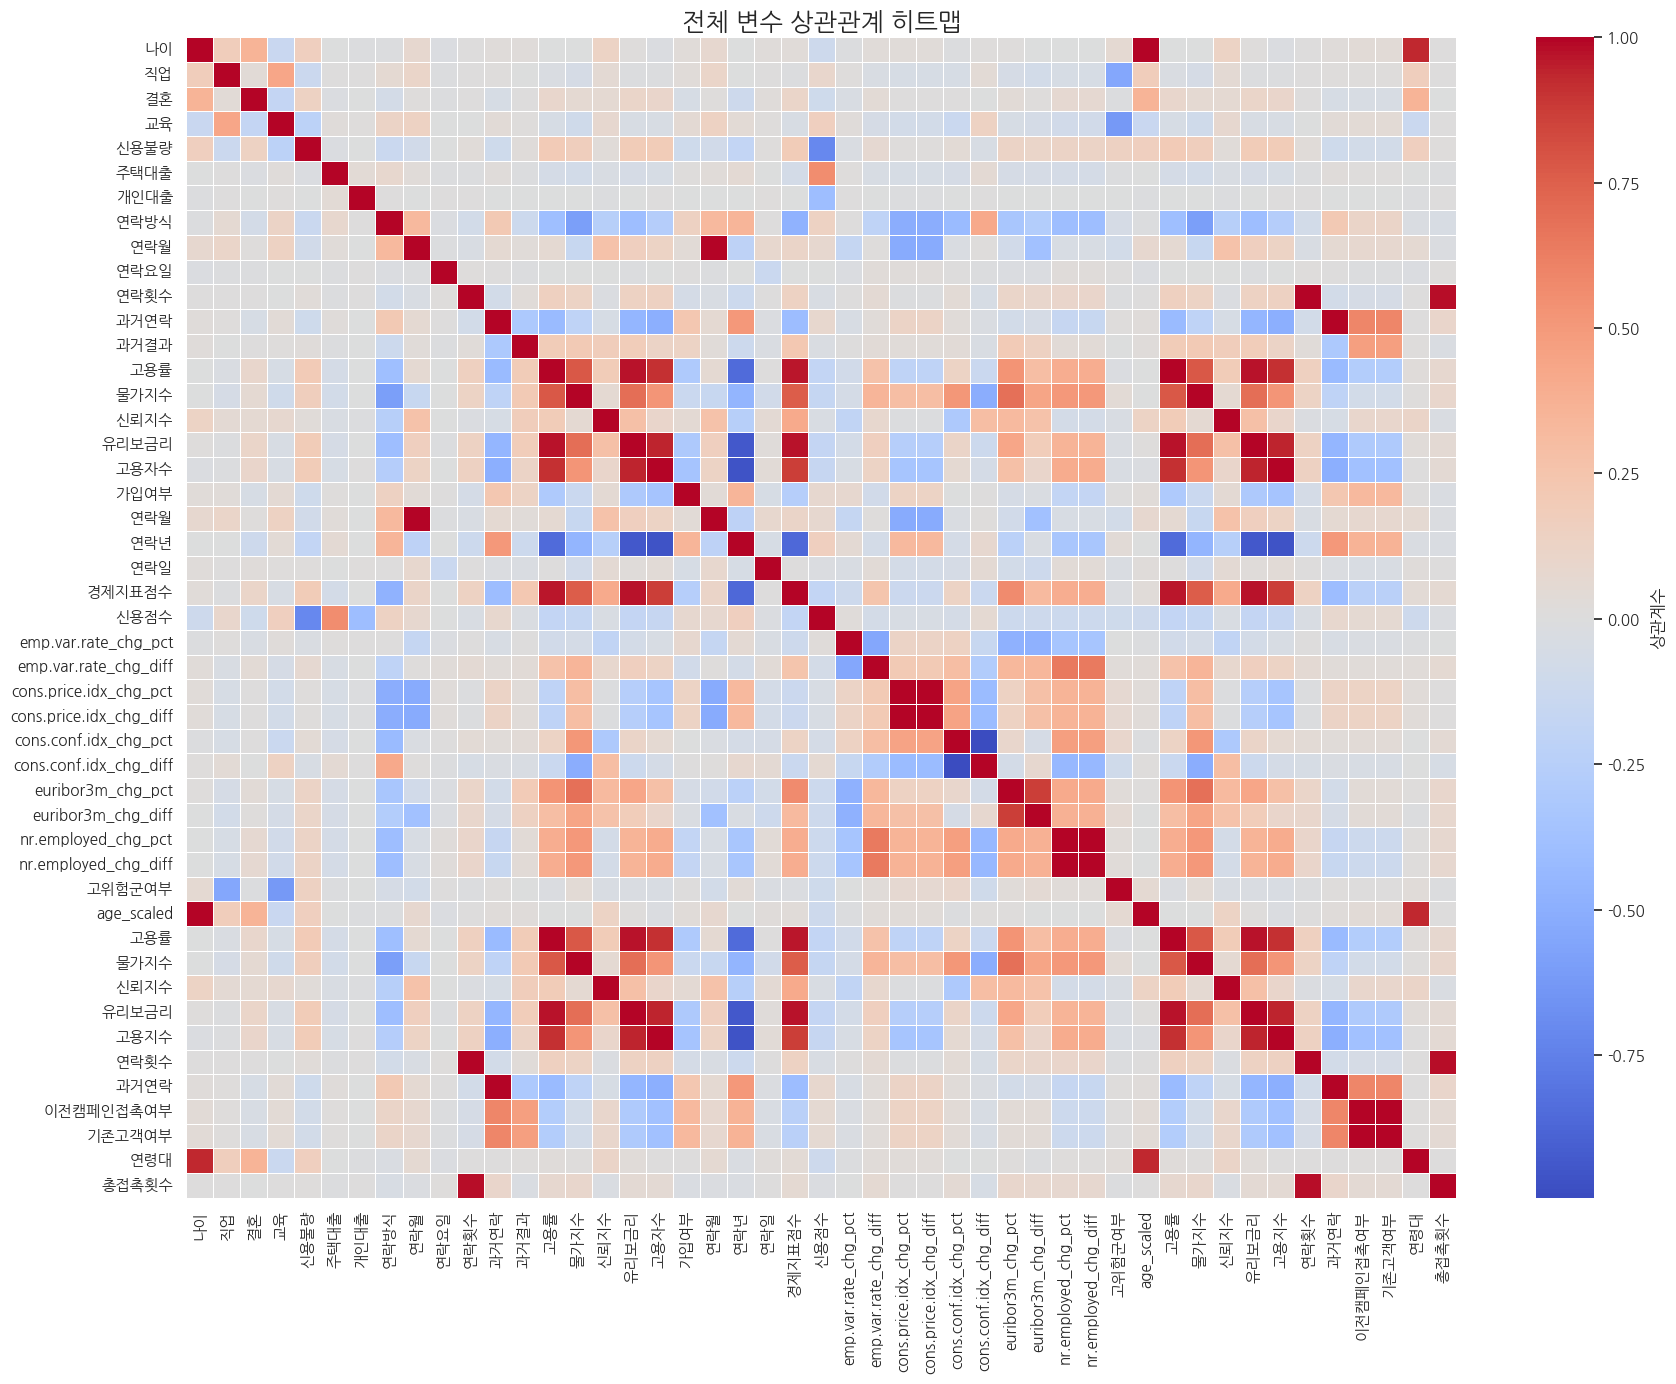


=== 상관계수 상위 20쌍 (절대값 기준) ===
고용지수 ↔ 고용자수: 1.000
과거연락 ↔ 과거연락: 1.000
유리보금리 ↔ 유리보금리: 1.000
고용률 ↔ 고용률: 1.000
cons.price.idx_chg_pct ↔ cons.price.idx_chg_diff: 1.000
nr.employed_chg_pct ↔ nr.employed_chg_diff: 1.000
cons.conf.idx_chg_diff ↔ cons.conf.idx_chg_pct: -0.995
연락횟수 ↔ 총접촉횟수: 0.984
연락횟수 ↔ 총접촉횟수: 0.984
유리보금리 ↔ 경제지표점수: 0.974
유리보금리 ↔ 경제지표점수: 0.974
유리보금리 ↔ 고용률: 0.972
고용률 ↔ 유리보금리: 0.972
유리보금리 ↔ 고용률: 0.972
유리보금리 ↔ 고용률: 0.972
고용률 ↔ 경제지표점수: 0.966
고용률 ↔ 경제지표점수: 0.966
고용지수 ↔ 연락년: -0.959
고용자수 ↔ 연락년: -0.959
고용지수 ↔ 유리보금리: 0.945

=== 전체 상관계수 표 (상위 30개 변수) ===


,나이,직업,결혼,교육,신용불량,주택대출,개인대출,연락방식,연락월,연락요일,연락횟수,과거연락,과거결과,고용률,물가지수,신뢰지수,유리보금리,고용자수,가입여부,연락월,연락년,연락일,경제지표점수,신용점수,emp.var.rate_chg_pct,emp.var.rate_chg_diff,cons.price.idx_chg_pct,cons.price.idx_chg_diff,cons.conf.idx_chg_pct,cons.conf.idx_chg_diff
나이,1.000000,0.175838,0.359436,-0.143183,0.164965,-0.001603,-0.007368,-0.007021,0.077265,-0.018486,0.004594,0.024365,0.019750,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399,0.077265,-0.003109,0.019007,0.030835,-0.113669,-0.006126,0.027334,0.028498,0.028427,-0.009921,0.010153
직업,0.175838,1.000000,0.037570,0.432942,-0.124375,0.003259,0.003172,0.058078,0.106671,-0.006681,0.004392,0.010965,-0.000464,-0.023123,-0.055299,0.051565,-0.006037,-0.008355,0.027751,0.106671,-0.002401,0.004517,-0.010349,0.088538,0.014576,-0.032510,-0.049665,-0.049648,-0.046574,0.046629
결혼,0.359436,0.037570,1.000000,-0.173963,0.135151,-0.013669,-0.003660,-0.071397,0.014519,-0.006603,0.005167,-0.048677,0.008317,0.094911,0.057727,0.062899,0.104859,0.097693,-0.051537,0.014519,-0.110697,0.024809,0.104895,-0.101047,-0.029930,0.042671,0.009487,0.009621,0.003826,-0.002617
교육,-0.143183,0.432942,-0.173963,1.000000,-0.220036,0.019750,0.010089,0.120847,0.139030,0.000391,0.000020,0.035611,0.015527,-0.048452,-0.098416,0.075360,-0.039424,-0.040031,0.055628,0.139030,0.044092,0.011596,-0.037876,0.162360,0.017969,-0.055855,-0.079626,-0.079538,-0.134059,0.139041
신용불량,0.164965,-0.124375,0.135151,-0.220036,1.000000,-0.015815,-0.003782,-0.135238,-0.084322,-0.004286,0.032825,-0.102416,0.023417,0.203263,0.168073,0.026522,0.195336,0.189845,-0.099352,-0.084322,-0.184454,0.013481,0.196459,-0.711081,-0.027357,0.069955,0.016153,0.016021,0.042537,-0.042315
주택대출,-0.001603,0.003259,-0.013669,0.019750,-0.015815,1.000000,0.044296,0.082186,0.031865,-0.009003,-0.011010,0.021314,-0.011783,-0.060196,-0.080504,-0.033845,-0.059277,-0.045862,0.011552,0.031865,0.050806,0.000517,-0.070171,0.561126,0.011933,-0.040289,-0.052183,-0.052162,-0.053174,0.053126
개인대출,-0.007368,0.003172,-0.003660,0.010089,-0.003782,0.044296,1.000000,0.008556,-0.004193,0.002386,0.005166,-0.001327,-0.001511,0.001849,-0.002430,-0.012025,0.000125,0.003903,-0.004909,-0.004193,-0.001068,0.011968,-0.002152,-0.401758,0.004344,-0.005481,-0.009812,-0.009825,-0.002440,0.002638
연락방식,-0.007021,0.058078,-0.071397,0.120847,-0.135238,0.082186,0.008556,1.000000,0.324315,-0.019583,-0.077368,0.212848,-0.118744,-0.393584,-0.591474,-0.251614,-0.399773,-0.269155,0.144773,0.324315,0.345340,0.007035,-0.478101,0.139983,0.002610,-0.204629,-0.508313,-0.508774,-0.418679,0.419085
연락월,0.077265,0.106671,0.014519,0.139030,-0.084322,0.031865,-0.004193,0.324315,1.000000,-0.006959,-0.030635,0.063754,0.028950,0.058874,-0.150350,0.264227,0.163411,0.132697,0.037187,1.000000,-0.211876,0.081141,0.117633,0.080023,-0.163049,0.013517,-0.525080,-0.524517,-0.022707,0.013784
연락요일,-0.018486,-0.006681,-0.006603,0.000391,-0.004286,-0.009003,0.002386,-0.019583,-0.006959,1.000000,0.015098,0.004013,-0.012788,-0.004401,-0.004586,-0.000099,-0.005552,-0.000734,0.010051,-0.006959,-0.003072,-0.134404,-0.003857,-0.003263,-0.015044,0.028764,0.018930,0.019101,0.006835,-0.008158


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_commit_0_5.copy()
kr_columns = df.get_head_att()

# 1. 상관계수 계산
#numeric_cols = df.select_dtypes(include=[np.number]).columns
#corr = df[numeric_cols].corr()
corr = df.select_dtypes(include=[np.number]).corr()

# 2. 한글 컬럼명으로 매핑
corr_kr = corr.rename(index=kr_columns, columns=kr_columns)

# 3. 히트맵 시각화
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_kr,
    annot=False,  # 수치 표시: True로 하면 숫자도 같이 나옴
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': '상관계수'}
)
plt.title('전체 변수 상관관계 히트맵', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. 상관계수 수치 표 (절대값 기준 상위 20쌍)
print("\n=== 상관계수 상위 20쌍 (절대값 기준) ===")
corr_unstacked = corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]  # 자기 자신 제외
top_corr = corr_unstacked.sort_values(ascending=False).drop_duplicates().head(20)

for (col1, col2), value in top_corr.items():
    col1_kr = kr_columns.get(col1, col1)
    col2_kr = kr_columns.get(col2, col2)
    print(f"{col1_kr} ↔ {col2_kr}: {corr.loc[col1, col2]:.3f}")

# 5. 전체 상관계수 표 (DataFrame)
print("\n=== 전체 상관계수 표 (상위 30개 변수) ===")
display(corr_kr.head(30).iloc[:, :30])



## 상관도를 공적 지표와 개인 지표 글 구분하자

       이전캠페인접촉여부 과거연락 연락방식 신용불량 연락횟수      교육    결혼   나이   직업     총접촉횟수 주택대출    연령대 개인대출
   pdays_contacted_before previous  contact  default campaign education marital    age    job total_contacts  housing age_group     loan
 y                 0.3249   0.2302   0.1448  -0.0994  -0.0664    0.0556 -0.0515 0.0304 0.0278        -0.0252   0.0116    0.0096  -0.0049


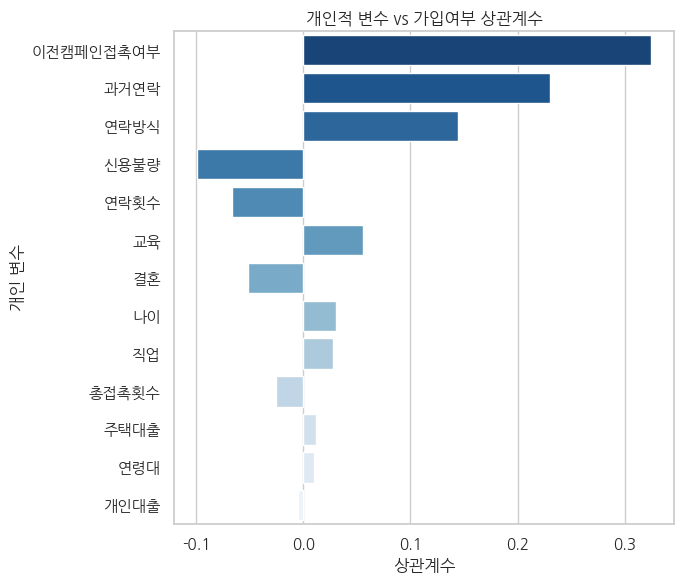

             고용지수       유리보금리              고용률   경제지표점수              물가지수             신뢰지수
   nr.employed_scaled euribor3m_scaled emp.var.rate_scaled economic_score cons.price.idx_scaled cons.conf.idx_scaled
 y            -0.3547          -0.3078             -0.2983        -0.2615               -0.1362               0.0549


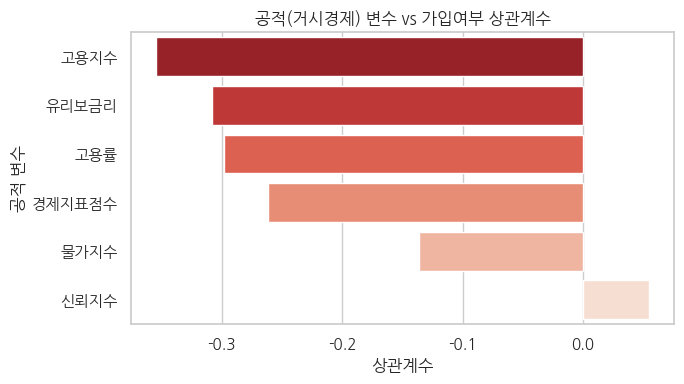

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_commit_0_5.copy()
kr_columns = df.get_head_att()

# 변수 구분
personal_vars = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'campaign', 'previous', 'pdays_contacted_before',
    'age_group', 'total_contacts'
]
public_vars = [
    'emp.var.rate_scaled', 'cons.price.idx_scaled', 'cons.conf.idx_scaled',
    'euribor3m_scaled', 'nr.employed_scaled', 'economic_score'
]


#corr = df.corr()
corr = df.select_dtypes(include=[np.number]).corr()
y_corr = corr['y']

# 1. 개인 변수만 따로
personal_corr = y_corr[personal_vars].sort_values(key=abs, ascending=False)
personal_labels = [kr_columns.get(col, col) for col in personal_corr.index]

personal_corr1 = personal_corr.head(100).to_frame().T
personal_corr1.set_head_att(kr_columns)
personal_corr1.head_att(50)

plt.figure(figsize=(7, 6))
sns.barplot(x=personal_corr.values, y=personal_labels, palette='Blues_r')
plt.title('개인적 변수 vs 가입여부 상관계수')
plt.xlabel('상관계수')
plt.ylabel('개인 변수')
plt.tight_layout()
plt.show()

# 2. 공적(거시경제) 변수만 따로
public_corr = y_corr[public_vars].sort_values(key=abs, ascending=False)
public_labels = [kr_columns.get(col, col) for col in public_corr.index]

public_corr2 = public_corr.head(100).to_frame().T
public_corr2.set_head_att(kr_columns)
public_corr2.head_att(50)

#public_corr.head_att(50)
plt.figure(figsize=(7, 4))
sns.barplot(x=public_corr.values, y=public_labels, palette='Reds_r')
plt.title('공적(거시경제) 변수 vs 가입여부 상관계수')
plt.xlabel('상관계수')
plt.ylabel('공적 변수')
plt.tight_layout()
plt.show()

del df
import gc; gc.collect();

       이전캠페인접촉여부 과거연락 연락방식 신용불량 연락횟수      교육    결혼   나이   직업     총접촉횟수 주택대출    연령대 개인대출
   pdays_contacted_before previous  contact  default campaign education marital    age    job total_contacts  housing age_group     loan
 y                 0.3249   0.2302   0.1448  -0.0994  -0.0664    0.0556 -0.0515 0.0304 0.0278        -0.0252   0.0116    0.0096  -0.0049

             고용지수       유리보금리              고용률   경제지표점수              물가지수             신뢰지수
   nr.employed_scaled euribor3m_scaled emp.var.rate_scaled economic_score cons.price.idx_scaled cons.conf.idx_scaled
 y            -0.3547          -0.3078             -0.2983        -0.2615               -0.1362               0.0549


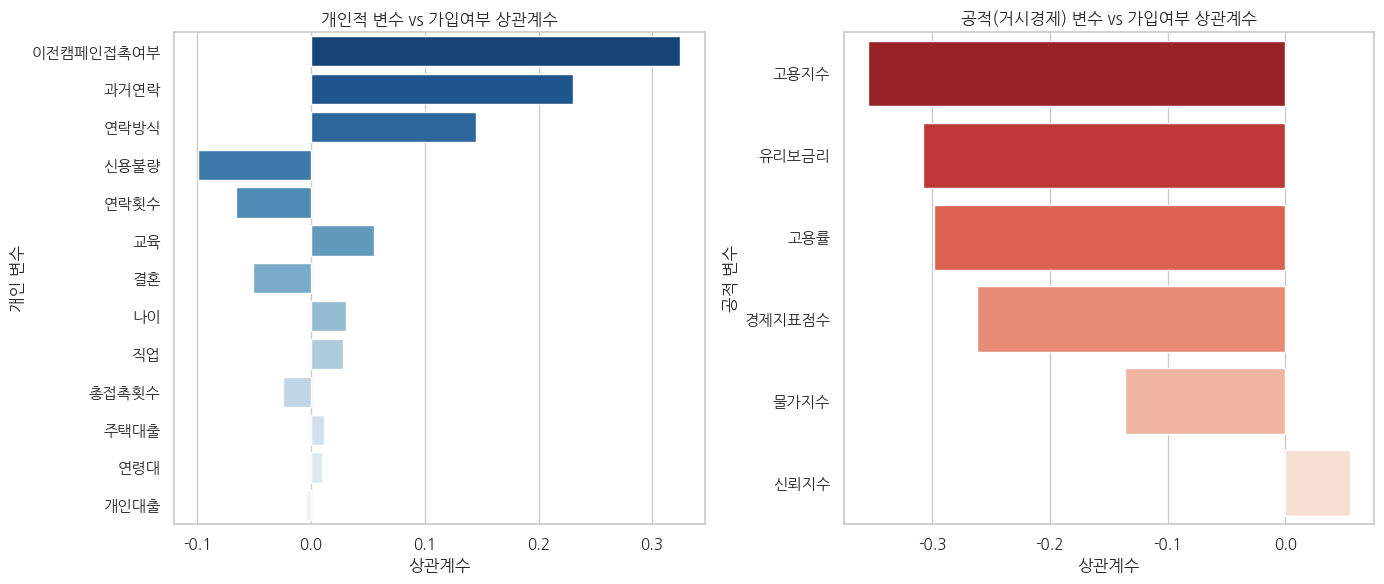

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비
df = df_commit_0_5.copy()
kr_columns = df.get_head_att()

# 변수 구분
personal_vars = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'campaign', 'previous', 'pdays_contacted_before',
    'age_group', 'total_contacts'
]
public_vars = [
    'emp.var.rate_scaled', 'cons.price.idx_scaled', 'cons.conf.idx_scaled',
    'euribor3m_scaled', 'nr.employed_scaled', 'economic_score'
]

# 상관계수 계산
#corr = df.corr()
corr = df.select_dtypes(include=[np.number]).corr()
y_corr = corr['y']

personal_corr = y_corr[personal_vars].sort_values(key=abs, ascending=False)
public_corr = y_corr[public_vars].sort_values(key=abs, ascending=False)

# 한글 컬럼명 매핑
personal_labels = [kr_columns.get(col, col) for col in personal_corr.index]
public_labels = [kr_columns.get(col, col) for col in public_corr.index]

personal_corr1 = personal_corr.head(100).to_frame().T
personal_corr1.set_head_att(kr_columns)
personal_corr1.head_att(50)

print()
public_labels1 = public_corr.head(100).to_frame().T
public_labels1.set_head_att(kr_columns)
public_labels1.head_att(50)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=personal_corr.values, y=personal_labels, ax=axes[0], palette='Blues_r')
axes[0].set_title('개인적 변수 vs 가입여부 상관계수')
axes[0].set_xlabel('상관계수')
axes[0].set_ylabel('개인 변수')

sns.barplot(x=public_corr.values, y=public_labels, ax=axes[1], palette='Reds_r')
axes[1].set_title('공적(거시경제) 변수 vs 가입여부 상관계수')
axes[1].set_xlabel('상관계수')
axes[1].set_ylabel('공적 변수')

plt.tight_layout()
plt.show()

del df
import gc; gc.collect();

- 상관도를 거시 경제 지표와 개인 사항으로 구분을 했습니다.
  - 거시 경제는 고객 전체적으로 영향을 줄 것이고
  - 개인 사항 개개인에게 영향을 줄 것입니다.
  - 거시 경제와 개인 사랑의 영향도를 분석하여 "마케팅 캠페인의 효율성을 높이는 전략"의 참고 자료로 확인 할 수 있을 것 입니다.

# 중단점 CONTINUE_TO_commit_0_5

In [42]:
CONTINUE_TO_commit_0_5 = True  # 다음단계 시작하려면 True로 변경

if not CONTINUE_TO_commit_0_5:
    print("=" * 70)
    print("전처리 파이프라인 완료!")
    print("")
    print("준비된 데이터셋:")
    print(f"  df_commit_0_5: {df_commit_0_5.shape}")
    df_commit_0_5.info()
    df_commit_0_5.head_att()
    raise ValueError("모델링 단계로 진행하려면 CONTINUE_TO_commit_0_5 = True로 변경하세요")
else:
    print("모델링 단계로 진행합니다...")

모델링 단계로 진행합니다...


## 4단계: 이상치 처리 및 데이터셋 준비

In [43]:
df = df_commit_0_5.copy()
df.head_att(10)
# print(f"작업 시작: df_commit_0_5 {df.shape}")

# campaign 컬럼 로그 변환 후 기존 컬럼 삭제
import numpy as np

# 로그 변환 (log1p: log(1+x), 0값 안전)
df['campaign_log1p'] = np.log1p(df['campaign'])

# 기존 컬럼 삭제
df = df.drop(['campaign'], axis=1)
# print("pdays_log1p, campaign_log1p 컬럼 생성 및 기존 컬럼 삭제 완료")
# print(df[['pdays_log1p', 'campaign_log1p']].describe())

df_commit_0_5 = df.copy()  # 로그 변환 완료
print()
df.head_att(10)

   나이 직업    결혼      교육 신용불량 주택대출 개인대출 연락방식 연락월    연락요일 연락횟수 과거연락 과거결과       고용률       물가지수      신뢰지수 유리보금리    고용자수 가입여부    연락월 연락년              연락일  연락일   경제지표점수 economic_grade     신용점수     신용등급 year_month emp.var.rate_chg_pct emp.var.rate_chg_diff cons.price.idx_chg_pct cons.price.idx_chg_diff cons.conf.idx_chg_pct cons.conf.idx_chg_diff euribor3m_chg_pct euribor3m_chg_diff nr.employed_chg_pct nr.employed_chg_diff 고위험군여부 age_scaled              고용률              물가지수             신뢰지수       유리보금리           고용지수        연락횟수        과거연락     이전캠페인접촉여부         기존고객여부    연령대     총접촉횟수
    age  job marital education  default  housing     loan  contact  month day_of_week campaign previous poutcome emp.var.rate cons.price.idx cons.conf.idx  euribor3m nr.employed        y month_num   year           call_date day_num economic_score economic_grade credit_score credit_grade year_month emp.var.rate_chg_pct emp.var.rate_chg_diff cons.price.idx_chg_pct cons.price.idx_chg_diff cons.conf.idx_chg_pct con

In [44]:
# =============================================================================
# 최종 데이터셋 생성 및 저장
# =============================================================================

print("=== 최종 데이터셋 생성 ===")

df = df_commit_0_5.copy()
print(f"작업 시작: df_commit_0_5 {df.shape}")

# 이상치 처리 전략별 데이터셋 생성
print("\n1. 이상치 처리 전략별 데이터셋 생성:")

# 1) 이상치 포함 (원본 유지)
df_with_outliers = df.copy()
print(f"   - 이상치 포함: {df_with_outliers.shape}")

# 2) 이상치 제거 (age와 campaign에서 이상치 행 제거)
age_outliers = (df['age'] < 18) | (df['age'] > 95)
#campaign_outliers = df['campaign'] > 15

#df_without_outliers = df[~(age_outliers | campaign_outliers)].copy()
df_without_outliers = df[~(age_outliers)].copy()
print(f"   - 이상치 제거: {df_without_outliers.shape} (제거: {len(df) - len(df_without_outliers)}행)")

# 3) 이상치 캡핑 (극값을 합리적 범위로 제한)
df_capped = df.copy()
df_capped.loc[df_capped['age'] < 18, 'age'] = 18
df_capped.loc[df_capped['age'] > 95, 'age'] = 95
#df_capped.loc[df_capped['campaign'] > 15, 'campaign'] = 15
print(f"   - 이상치 캡핑: {df_capped.shape}")

# 최종 데이터셋을 df_final_x로 저장
df_final_with_outliers = df_with_outliers.copy()
df_final_without_outliers = df_without_outliers.copy()
df_final_capped = df_capped.copy()

print(f"\n2. 최종 데이터셋 요약:")
print(f"1. df_final_with_outliers: {len(df_final_with_outliers):,}개 행 (이상치 포함)")
print(f"2. df_final_without_outliers: {len(df_final_without_outliers):,}개 행 (이상치 제거)")
print(f"3. df_final_capped: {len(df_final_capped):,}개 행 (이상치 캡핑)")

# 타겟 변수 분포 비교
print(f"\n3. 타겟 변수 분포 비교:")
for name, dataset in [("이상치포함", df_final_with_outliers),
                     ("이상치제거", df_final_without_outliers),
                     ("이상치캡핑", df_final_capped)]:
    pos_rate = dataset['y'].mean() * 100
    print(f"  {name}: 긍정 비율 {pos_rate:.2f}%")

# df_commit_1_0_x 시리즈로 저장 (이상치 처리 전략별)
df_commit_1_0_with_outliers = df_final_with_outliers.copy()
df_commit_1_0_without_outliers = df_final_without_outliers.copy()
df_commit_1_0_capped = df_final_capped.copy()

print(f"\n df_commit_1_0_x 시리즈 저장 완료:")
print(f"   - df_commit_1_0_with_outliers: {df_commit_1_0_with_outliers.shape}")
print(f"   - df_commit_1_0_without_outliers: {df_commit_1_0_without_outliers.shape}")
print(f"   - df_commit_1_0_capped: {df_commit_1_0_capped.shape}")

print("=" * 70)

=== 최종 데이터셋 생성 ===
작업 시작: df_commit_0_5 (41188, 51)

1. 이상치 처리 전략별 데이터셋 생성:
   - 이상치 포함: (41188, 51)
   - 이상치 제거: (41181, 51) (제거: 7행)
   - 이상치 캡핑: (41188, 51)

2. 최종 데이터셋 요약:
1. df_final_with_outliers: 41,188개 행 (이상치 포함)
2. df_final_without_outliers: 41,181개 행 (이상치 제거)
3. df_final_capped: 41,188개 행 (이상치 캡핑)

3. 타겟 변수 분포 비교:
  이상치포함: 긍정 비율 11.27%
  이상치제거: 긍정 비율 11.26%
  이상치캡핑: 긍정 비율 11.27%

 df_commit_1_0_x 시리즈 저장 완료:
   - df_commit_1_0_with_outliers: (41188, 51)
   - df_commit_1_0_without_outliers: (41181, 51)
   - df_commit_1_0_capped: (41188, 51)


In [45]:
# df_commit_1_0_with_outliers.head_att()

# 함수 : 데이터 준비 (보조 컬럼 삭제)

In [46]:



def get_model_features(dataframe):
    """모델링에 사용할 특성들을 반환 (예측 시점에 알 수 없는 변수 제외)"""

    # 제외할 변수들
    exclude_vars = {
        'duration',          # 통화 후에만 알 수 있음 (예측 불가)
        'duration_backup',   # 백업용
        'pdays',            # pdays_contacted_before 사용
        'age_group',        # 범주형 (age_scaled 사용)
        'y',                 # 타겟 변수
        'month_num',         # month와 중복
        'year',              # 시간 정보, 실제 예측에 불필요
        'call_date',         # datetime, 예측 불가
        'day_num',           # 추정된 날짜, 실제 예측에 불필요
        'credit_grade', # 신용등급, 이미 credit_score로 대체됨
        'economic_grade',  # 문자열 등급 변수 제외
        'credit_grade',    # 문자열 등급 변수 제외
        'year_month',   # 문자열 월 정보
    }

    # datetime 타입 컬럼 자동 제외
    datetime_cols = dataframe.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns
    exclude_vars.update(datetime_cols)

    # 사용할 특성들
    feature_columns = [col for col in dataframe.columns
                      if col not in exclude_vars]

    print(f"\n모델링 특성 정의:")
    print(f"   - 전체 컬럼 수: {len(dataframe.columns)}")
    print(f"   - 제외된 변수 수: {len(exclude_vars)}")
    print(f"   - 모델링 특성 수: {len(feature_columns)}")

    return sorted(feature_columns)


# 모델링 데이터 준비

In [47]:
# =============================================================================
#  모델링 데이터 준비 및 분할
# =============================================================================

print("=== 모델링 데이터 준비 ===")

df_commit_modeling = df_commit_0_5.copy()
# 특성 정의 실행
model_features = get_model_features(df_commit_modeling)

# 1. 특성 및 타겟 분리
features = model_features  # 이전에 정의된 특성들
X = df_commit_modeling[features]
y = df_commit_modeling['y']

print(f"특성 데이터: {X.shape}")
print(f"타겟 데이터: {y.shape}")
print(f"타겟 분포: {y.value_counts().to_dict()}")

# 2. 데이터 타입 확인 및 정리
print(f"\n데이터 타입 정리:")
for col in X.columns:
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype('int64')
        print(f"  {col}: category → int64")

# 3. 결측값 최종 확인
missing_check = X.isnull().sum().sum()
if missing_check > 0:
    print(f" 결측값 {missing_check}개 발견, 0으로 처리")
    X = X.fillna(0)
else:
    print(" 결측값 없음")

# 4. 학습/테스트 데이터 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n=== 데이터 분할 완료 ===")
print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"학습 타겟 분포: {pd.Series(y_train).value_counts().to_dict()}")
print(f"테스트 타겟 분포: {pd.Series(y_test).value_counts().to_dict()}")

# 5. 클래스 불균형 확인
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n클래스 불균형 비율: {class_ratio:.2f}:1 (비가입:가입)")

print(" 모든 모델에서 동일한 train/test 데이터 사용")
print("=" * 60)

=== 모델링 데이터 준비 ===

모델링 특성 정의:
   - 전체 컬럼 수: 51
   - 제외된 변수 수: 12
   - 모델링 특성 수: 42
특성 데이터: (41188, 42)
타겟 데이터: (41188,)
타겟 분포: {0: 36548, 1: 4640}

데이터 타입 정리:
 결측값 없음

=== 데이터 분할 완료 ===
학습 데이터: (32950, 42)
테스트 데이터: (8238, 42)
학습 타겟 분포: {0: 29238, 1: 3712}
테스트 타겟 분포: {0: 7310, 1: 928}

클래스 불균형 비율: 7.88:1 (비가입:가입)
 모든 모델에서 동일한 train/test 데이터 사용


## 전처리 파이프라인 완료 요약

### 완료된 전처리 단계

#### 1단계: 범주형 변수 인코딩 (`df_commit_0_2`)
- **교육 수준**: 순서형 라벨 인코딩 (0~7)
- **직업**: 원-핫 인코딩 (12개 더미 변수)
- **기타 범주형**: 원-핫 인코딩
  - 혼인상태 (3개), 신용불량 (2개), 주택담보대출 (2개)
  - 개인대출 (2개), 연락방법 (2개), 월 (12개)
  - 요일 (5개), 이전마케팅결과 (4개)

#### 2단계: 숫자형 변수 스케일링 (`df_commit_0_3`)
- **StandardScaler 적용**:
  - age, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed
- **MinMaxScaler 적용**:
  - campaign, previous

#### 3단계: 특수 변수 처리 (`df_commit_0_4`)
- **pdays 변수**: 999를 별도 더미변수로 처리, 유효값만 스케일링
- **duration 변수**: 예측 불가능 변수로 분류 (실제 모델에서 제외)
- **타겟 변수**: y로 이진 인코딩 (0: no, 1: yes)
- **파생 변수**:
  - age_group (연령대), total_contacts (총 접촉횟수)
  - economic_score (경제지표 종합점수)

#### 4단계: 이상치 처리 및 최종 준비 (`df_commit_1_0_*`)
- **이상치 식별**: 876개 (2.13%) - 주로 캠페인 10회 초과
- **3가지 처리 전략**:
  - 포함: 41,188개 행
  - 제거: 40,312개 행  
  - 캡핑: 41,188개 행 (조정됨)

### 최종 데이터셋 특성

- **특성 개수**: 23개 (모델링용)
- **타겟 분포**: 약 11.3% 긍정 응답
- **준비된 데이터셋**: 3개 버전 (이상치 처리 전략별)

### 다음 단계: 모델링

1. **Decision Tree**
2. **Random Forest**
3. **Gradient Boosting**
4. **XGBoost**
5. **Voting Classfier**
6. **이상치 처리 전략별 성능 비교**
7. **특성 중요도 분석**
8. **모델 해석 및 비즈니스 인사이트 도출**

### 데이터 선택 옵션:
- **권장**: `df_commit_1_0_capped` (이상치 캡핑, 균형잡힌 접근)
- **보수적**: `df_commit_1_0_without_outliers` (이상치 제거)  
- **전체**: `df_commit_1_0_with_outliers` (이상치 포함)

# 모델링

## 데이터 준비 및 모델 성능 비교
### 실험 설계
- **개별 모델 성능 측정**: 각 모델을 독립적으로 테스트
- **일관된 데이터 사용**: df_commit_modeling을 모든 실험에서 사용  
- **단계적 접근**: 단일 모델 → 앙상블 조합
- **성능 로깅**: 각 모델의 성능을 개별적으로 확인

## 모델 성능 평가 지표 해석 가이드

### 성능 지표 이해하기


#### 1. 정확도 (Accuracy)
- **범위**: 0.0 ~ 1.0 (100%)
- **의미**: 전체 예측 중 올바르게 예측한 비율
- **해석**:
  - 1.0에 가까울수록 좋음 (전체 예측 정확도)
  - 0.9 (90%) 이상: 매우 우수
  - 0.8~0.9 (80~90%): 좋음
  - 0.7~0.8 (70~80%): 보통
  - 0.7 (70%) 미만: 개선 필요
- **주의**: 불균형 데이터에서는 높은 정확도가 좋은 모델을 의미하지 않을 수 있음

#### 2. 정밀도 (Precision)
- **범위**: 0.0 ~ 1.0 (100%)
- **의미**: "가입할 것"이라고 예측한 고객 중 실제로 가입한 비율
- **해석**:
  - 1.0에 가까울수록 좋음 (예측 성공률)
  - 0.8 (80%) 이상: 매우 우수 (헛수고 20% 미만)
  - 0.6~0.8 (60~80%): 좋음 (헛수고 20~40%)
  - 0.4~0.6 (40~60%): 보통 (헛수고 40~60%)
  - 0.4 (40%) 미만: 개선 필요 (헛수고 60% 이상)
- **비즈니스 관점**: 마케팅 비용 효율성과 직결

#### 3. 재현율 (Recall)

## 모델 성능 평가 지표

1. 모델 성능 평가 지표 범위

| 지표 | 범위 | 의미 |
|------|------|------|
| **정확도 (Accuracy)** | 0.0 ~ 1.0 (100%) | 전체 예측 중 올바르게 예측한 비율 |
| **정밀도 (Precision)** | 0.0 ~ 1.0 (100%) | "가입할 것"이라고 예측한 고객 중 실제로 가입한 비율 |
| **재현율 (Recall)** | 0.0 ~ 1.0 (100%) | 실제 가입고객 중 모델이 찾아낸 비율 |
| **F1-Score** | 0.0 ~ 1.0 (100%) | 정밀도와 재현율의 조화평균 |
| **ROC-AUC** | 0.0 ~ 1.0 (100%) | 모델의 분류 성능 종합 지표 |

2. 성능 등급 기준

| 등급 | ROC-AUC | F1-Score | 평가 |
|------|---------|----------|------|
| **S급** | ≥ 0.90 | ≥ 0.70 | 매우 우수 |
| **A급** | 0.80~0.89 | 0.60~0.69 | 좋음 |
| **B급** | 0.70~0.79 | 0.50~0.59 | 괜찮음 |
| **C급** | 0.60~0.69 | 0.40~0.49 | 보통 |
| **D급** | < 0.60 | < 0.40 | 개선 필요 |

3. 개별 지표별 성능 기준

| 지표 | 매우우수 | 좋음 | 보통 | 개선필요 |
|------|----------|------|------|----------|
| **정확도** | ≥ 0.90 | 0.80~0.89 | 0.70~0.79 | < 0.70 |
| **정밀도** | ≥ 0.80 | 0.60~0.79 | 0.40~0.59 | < 0.40 |
| **재현율** | ≥ 0.80 | 0.60~0.79 | 0.40~0.59 | < 0.40 |
| **F1-Score** | ≥ 0.80 | 0.60~0.79 | 0.40~0.59 | < 0.40 |
| **ROC-AUC** | ≥ 0.90 | 0.80~0.89 | 0.70~0.79 | < 0.70 |

## 함수 : 모델링 사용

### evaluate_modeling

In [48]:
def evaluate_modeling(model, X_train, X_test, y_train, y_test):
    """
    모델의 성능을 평가하고 결과를 반환하는 함수 (순수 계산만)

    Parameters:
    - model: 평가할 모델 객체
    - X_train, X_test: 학습/테스트 특성 데이터
    - y_train, y_test: 학습/테스트 타겟 데이터

    Returns:
    - results: 성능 지표 딕셔너리
    """
    import time
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.metrics import confusion_matrix

    # 학습 시간 측정
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # 예측 시간 측정
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time

    # 확률 예측 (ROC-AUC 계산용) - VotingClassifier 호환성 개선
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
        else:
            # 확률을 구할 수 없는 경우 예측값을 사용 (0/1 → 0.0/1.0)
            y_proba = y_pred.astype(float)
    except Exception as e:
        print(f"확률 예측 중 오류 발생: {e}")
        # 대안: 예측값을 확률로 사용
        y_proba = y_pred.astype(float)

    # 성능 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC-AUC 계산 (확률이 있을 때만)
    try:
        roc_auc = roc_auc_score(y_test, y_proba)
    except Exception as e:
        print(f"ROC-AUC 계산 중 오류 발생: {e}, 대신 0.5 사용")
        roc_auc = 0.5  # 랜덤 분류기 성능

    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 결과 딕셔너리
    results = {
        'model': model,
        'predictions': {
            'y_pred': y_pred,
            'y_proba': y_proba
        },
        'metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc
        },
        'timing': {
            'train_time': train_time,
            'predict_time': predict_time
        },
        'confusion_matrix': {
            'matrix': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
        },
        'business_metrics': {
            'marketing_efficiency': precision * 100,
            'opportunity_loss': (1 - recall) * 100,
            'total_errors': fp + fn,
            'unnecessary_marketing': fp,
            'missed_opportunities': fn
        }
    }

    return results

### evaluate_modeling_report

In [49]:
def evaluate_modeling_report(results, model_name):
    """
    모델 평가 결과를 보고서 형태로 출력하는 함수

    Parameters:
    - results: evaluate_modeling 함수의 반환값
    - model_name: 모델 이름 (출력용)
    """

    # 성능 등급 판정 함수
    def get_performance_grade(roc_auc, f1):
        if roc_auc >= 0.90 and f1 >= 0.70:
            return "S급 (매우 우수)"
        elif roc_auc >= 0.80 and f1 >= 0.60:
            return "A급 (좋음)"
        elif roc_auc >= 0.70 and f1 >= 0.50:
            return "B급 (괜찮음)"
        elif roc_auc >= 0.60 and f1 >= 0.40:
            return "C급 (보통)"
        else:
            return "D급 (개선 필요)"

    # 개별 지표 평가 함수
    def evaluate_metric(value, metric_name):
        if metric_name in ['accuracy', 'precision', 'recall', 'f1_score']:
            if value >= 0.80:
                return "매우우수"
            elif value >= 0.60:
                return "좋음"
            elif value >= 0.40:
                return "보통"
            else:
                return "개선필요"
        elif metric_name == 'roc_auc':
            if value >= 0.90:
                return "매우우수"
            elif value >= 0.80:
                return "좋음"
            elif value >= 0.70:
                return "괜찮음"
            elif value >= 0.60:
                return "보통"
            else:
                return "개선필요"

    # 결과 추출
    metrics = results['metrics']
    timing = results['timing']
    cm_info = results['confusion_matrix']
    business = results['business_metrics']

    print(f"=== {model_name} 성능 평가 ===")

    # 핵심 성능 지표
    print(f"\n{model_name} [핵심 성능 지표]")
    print(f"정확도 (Accuracy):  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.1f}%) - {evaluate_metric(metrics['accuracy'], 'accuracy')}")
    print(f"정밀도 (Precision): {metrics['precision']:.4f} ({metrics['precision']*100:.1f}%) - {evaluate_metric(metrics['precision'], 'precision')}")
    print(f"재현율 (Recall):    {metrics['recall']:.4f} ({metrics['recall']*100:.1f}%) - {evaluate_metric(metrics['recall'], 'recall')}")
    print(f"F1-Score:          {metrics['f1_score']:.4f} ({metrics['f1_score']*100:.1f}%) - {evaluate_metric(metrics['f1_score'], 'f1_score')}")
    print(f"ROC-AUC:           {metrics['roc_auc']:.4f} ({metrics['roc_auc']*100:.1f}%) - {evaluate_metric(metrics['roc_auc'], 'roc_auc')}")

    # 종합 등급
    grade = get_performance_grade(metrics['roc_auc'], metrics['f1_score'])
    print(f"\n[종합 성능 등급]: {grade}")

    # 비즈니스 해석
    print(f"\n[비즈니스 관점 해석]")
    print(f"마케팅 효율성: 예측 성공률 {business['marketing_efficiency']:.1f}% (100명 연락시 {business['marketing_efficiency']:.0f}명 가입)")
    print(f"기회 손실률:   {business['opportunity_loss']:.1f}% (실제 가입고객 중 {business['opportunity_loss']:.0f}% 놓침)")

    if metrics['precision'] >= 0.6:
        print("정밀도 양호: 마케팅 비용 효율성 확보")
    else:
        print("정밀도 개선 필요: 비용 과다")

    if metrics['recall'] >= 0.6:
        print("재현율 양호: 기회 손실 최소화")
    else:
        print("재현율 개선 필요: 잠재 고객 발굴 부족")

    # 성능 효율성
    print(f"\n[성능 효율성]")
    print(f"학습 시간: {timing['train_time']:.2f}초")
    print(f"예측 시간: {timing['predict_time']:.4f}초 (1000건당 {timing['predict_time']*1000:.2f}초)")

    if timing['predict_time'] < 0.001:
        print("예측 속도: 실시간 서비스 적합")
    elif timing['predict_time'] < 0.01:
        print("예측 속도: 배치 처리 적합")
    else:
        print("예측 속도: 대용량 처리 시 고려 필요")

    # 혼동행렬 및 해석
    print(f"\n[혼동행렬 분석]")
    print(f"실제\\예측    비가입(0)  가입(1)")
    print(f"비가입(0)     {cm_info['tn']:6d}    {cm_info['fp']:4d}   <- FP: 불필요한 마케팅 {cm_info['fp']}건")
    print(f"가입(1)       {cm_info['fn']:6d}    {cm_info['tp']:4d}   <- FN: 놓친 기회 {cm_info['fn']}건")

    print(f"\n총 예측 오류: {business['total_errors']}건")
    print(f"- 불필요한 마케팅 비용: {business['unnecessary_marketing']}건")
    print(f"- 기회 손실: {business['missed_opportunities']}건")

    print("-" * 70)


### evaluate_model

In [50]:
modeling_result = []
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # 모델링 실행
    results = evaluate_modeling(model, X_train, X_test, y_train, y_test)
    modeling_result.append(results)
    evaluate_modeling_report(results, model_name)
    return results


### model_evaluate

In [51]:
def model_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    """
    통합된 모델 평가 함수
    - evaluate_modeling으로 성능 계산
    - evaluate_modeling_report로 보고서 출력
    - modeling_result 리스트에 결과 저장

    Parameters:
    - model: 평가할 모델 객체
    - X_train, X_test: 학습/테스트 특성 데이터
    - y_train, y_test: 학습/테스트 타겟 데이터
    - model_name: 모델 이름 (출력용)

    Returns:
    - results: 성능 지표 딕셔너리
    """

    # 1. 성능 계산 (기존 evaluate_modeling 함수 활용)
    results = evaluate_modeling(model, X_train, X_test, y_train, y_test)

    # 2. 결과를 전역 리스트에 저장
    modeling_result.append(results)

    # 3. 보고서 출력 (기존 evaluate_modeling_report 함수 활용)
    evaluate_modeling_report(results, model_name)

    return results

def model_evaluate_engine(model, X_train, X_test, y_train, y_test, model_name):
    """
    통합된 모델 평가 함수
    - evaluate_modeling으로 성능 계산
    - evaluate_modeling_report로 보고서 출력
    - modeling_result 리스트에 결과 저장

    Parameters:
    - model: 평가할 모델 객체
    - X_train, X_test: 학습/테스트 특성 데이터
    - y_train, y_test: 학습/테스트 타겟 데이터
    - model_name: 모델 이름 (출력용)

    Returns:
    - results: 성능 지표 딕셔너리
    """

    # 1. 성능 계산 (기존 evaluate_modeling 함수 활용)
    results = evaluate_modeling(model, X_train, X_test, y_train, y_test)

    # 2. 결과를 전역 리스트에 저장
    modeling_result.append(results)

    return results



In [52]:
CONTINUE_TO_modeling = True  # 다음단계 시작하려면 True로 변경

if not CONTINUE_TO_modeling:
    print("=" * 70)
    print("전처리 파이프라인 완료!")
    print("")
    print("준비된 데이터셋:")
    print(f"  df_commit_1_0_with_outliers: {df_commit_1_0_with_outliers.shape}")
    df_commit_1_0_with_outliers.info()
    raise ValueError("모델링 단계로 진행하려면 CONTINUE_TO_MODELING = True로 변경하세요")
else:
    print("모델링 단계로 진행합니다...")


모델링 단계로 진행합니다...


# 모델링 시작

## <중요> 모델링 데이터 선택

In [53]:
modeling_result.clear()

modeling_df_name = "df_commit_1_0_with_outliers 25.07.27"
df_commit_modeling = df_commit_1_0_with_outliers.copy() # 이상치 포함

#modeling_df_name = "df_commit_modeling 이상치 처리 age campaign"
#df_commit_modeling = df_commit_1_0_without_outliers.copy() # 이상치 제거

#modeling_df_name = "df_commit_1_0_capped 25.07.27"
#df_commit_modeling = df_commit_1_0_capped.copy() # 이상치 변환


# if not helper.is_colab:
#     # 프로그래 테스트
#     df_commit_modeling = df_commit_1_0_with_outliers.head(100).copy() # 이상치 포함

## 하이퍼파라미터 탐색을 위한 모델 함수화

### 모델별 함수 생성
- 각 모델을 함수로 구현
- 하이퍼파라미터를 인자로 받음
- 표준화된 결과 반환
- for문을 통한 반복 실행 준비

In [54]:
import os
import multiprocessing
import psutil
import numpy as np
import gc

# CPU 코어 수 확인
def get_optimal_n_jobs():
    """병렬 처리 수 계산"""
    cpu_count = multiprocessing.cpu_count()
    available_memory = psutil.virtual_memory().available / (1024**3)  # GB

    print(f"시스템 정보:")
    print(f"   CPU 코어 수: {cpu_count}")
    print(f"   가용 메모리: {available_memory:.1f}GB")
    print(f"   총 메모리: {psutil.virtual_memory().total / (1024**3):.1f}GB")

    # 메모리가 충분하면 모든 코어 사용, 부족하면 조정
    if available_memory > 8:
        n_jobs = -1  # 모든 코어 사용
        print(f"   권장 n_jobs: {n_jobs} (모든 코어 사용)")
    elif available_memory > 4:
        n_jobs = max(1, cpu_count - 2)  # 2개 코어 여유
        print(f"   권장 n_jobs: {n_jobs} (여유 코어 확보)")
    else:
        n_jobs = max(1, cpu_count // 2)  # 절반만 사용
        print(f"   권장 n_jobs: {n_jobs} (메모리 부족으로 제한)")

    return n_jobs, cpu_count

# 시스템 설정
optimal_n_jobs, total_cores = get_optimal_n_jobs()

# NumPy 멀티스레딩
os.environ['OMP_NUM_THREADS'] = str(total_cores)
os.environ['MKL_NUM_THREADS'] = str(total_cores)
os.environ['NUMEXPR_NUM_THREADS'] = str(total_cores)

print(f"\n성능 설정 완료")
print(f"   병렬 처리: {optimal_n_jobs} 코어 활용")
print(f"   NumPy : 활성화")

# 메모리 최적화
def optimize_data_memory():
    """메모리 사용량"""
    global X_train, X_test, y_train, y_test

    print(f"\n메모리 중...")

    # 기존 메모리 사용량
    before_memory = X_train.memory_usage(deep=True).sum() + X_test.memory_usage(deep=True).sum()
    before_mb = before_memory / (1024 * 1024)

    # 데이터 타입 최적화
    for col in X_train.columns:
        if X_train[col].dtype == 'int64':
            # int64 -> int32로 변환
            if X_train[col].min() >= -2147483648 and X_train[col].max() <= 2147483647:
                X_train[col] = X_train[col].astype('int32')
                X_test[col] = X_test[col].astype('int32')

        elif X_train[col].dtype == 'float64':
            # float64 -> float32로 변환
            X_train[col] = X_train[col].astype('float32')
            X_test[col] = X_test[col].astype('float32')

    # 타겟 변수 최적화
    y_train = y_train.astype('int8')
    y_test = y_test.astype('int8')

    # 최적화 후 메모리 사용량
    after_memory = X_train.memory_usage(deep=True).sum() + X_test.memory_usage(deep=True).sum()
    after_mb = after_memory / (1024 * 1024)

    saved_mb = before_mb - after_mb
    saved_percent = (saved_mb / before_mb) * 100

    print(f"   전: {before_mb:.2f}MB")
    print(f"   후: {after_mb:.2f}MB")
    print(f"   절약된 메모리: {saved_mb:.2f}MB ({saved_percent:.1f}%)")

    # 가비지 컬렉션
    gc.collect()
    print(f"   가비지 컬렉션 완료")

# 메모리 최적화 실행
optimize_data_memory()

print("=" * 50)

시스템 정보:
   CPU 코어 수: 16
   가용 메모리: 15.0GB
   총 메모리: 31.7GB
   권장 n_jobs: -1 (모든 코어 사용)

성능 설정 완료
   병렬 처리: -1 코어 활용
   NumPy : 활성화

메모리 중...
   전: 13.04MB
   후: 6.91MB
   절약된 메모리: 6.13MB (47.0%)
   가비지 컬렉션 완료


In [55]:
# =============================================================================
# 1. Decision Tree 모델 함수
# =============================================================================

def train_decision_tree(X_train, X_test, y_train, y_test,
                       max_depth=10, min_samples_split=100, min_samples_leaf=50,
                       criterion='gini', max_features=None):

    from sklearn.tree import DecisionTreeClassifier
    import time
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

    # 모델 생성
    dt_model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        class_weight='balanced',
        random_state=42
    )

    # 학습 시간 측정
    start_time = time.time()
    dt_model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # 예측 시간 측정
    start_time = time.time()
    y_pred = dt_model.predict(X_test)
    predict_time = time.time() - start_time

    # 확률 예측
    y_proba = dt_model.predict_proba(X_test)[:, 1]

    # 성능 지표 계산
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    # 결과 반환
    return {
        'model_name': 'Decision Tree',
        'model': dt_model,
        'metrics': metrics,
        'train_time': train_time,
        'predict_time': predict_time,
        'parameters': {
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf,
            'criterion': criterion,
            'max_features': max_features
        }
    }

print("Decision Tree 함수 생성 완료")

Decision Tree 함수 생성 완료


In [56]:
# =============================================================================
# 2. Random Forest 모델 함수
# =============================================================================

def train_random_forest(X_train, X_test, y_train, y_test,
                        n_estimators=100, max_depth=15, min_samples_split=50,
                        min_samples_leaf=20, max_features='sqrt', bootstrap=True):
    """
    Random Forest 모델 학습 및 평가

    Parameters:
    - n_estimators: 트리 개수
    - max_depth: 최대 깊이
    - min_samples_split: 분할 최소 샘플 수
    - min_samples_leaf: 리프 노드 최소 샘플 수
    - max_features: 최대 특성 수
    - bootstrap: 부트스트랩 사용 여부

    Returns:
    - dict: 성능 지표 및 모델 정보
    """
    from sklearn.ensemble import RandomForestClassifier
    import time

    # 모델 생성
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight='balanced',
        random_state=42,
        n_jobs=optimal_n_jobs,      # 최적화된 CPU 코어 사용
        warm_start=False,            # 메모리 효율성
        oob_score=True if bootstrap else False,  # Out-of-bag 점수 계산
        max_samples=None,            # 최대 샘플 수 (None = 모든 샘플)
        verbose=0                    # 출력 최소화
    )

    # 학습 시간 측정
    start_time = time.time()
    rf_model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # 예측 시간 측정
    start_time = time.time()
    y_pred = rf_model.predict(X_test)
    predict_time = time.time() - start_time

    # 확률 예측
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    # 성능 지표 계산
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    # 결과 반환
    return {
        'model_name': 'Random Forest',
        'model': rf_model,
        'metrics': metrics,
        'train_time': train_time,
        'predict_time': predict_time,
        'parameters': {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf,
            'max_features': max_features,
            'bootstrap': bootstrap
        }
    }

print("Random Forest 함수 생성 완료")

Random Forest 함수 생성 완료


In [57]:
# =============================================================================
# 3. Gradient Boosting 모델 함수
# =============================================================================

def train_gradient_boosting(X_train, X_test, y_train, y_test,
                           n_estimators=100, learning_rate=0.1, max_depth=6,
                           min_samples_split=100, min_samples_leaf=50, subsample=0.8):
    """
    Gradient Boosting 모델 학습 및 평가

    Parameters:
    - n_estimators: 부스팅 단계 수
    - learning_rate: 학습률
    - max_depth: 최대 깊이
    - min_samples_split: 분할 최소 샘플 수
    - min_samples_leaf: 리프 노드 최소 샘플 수
    - subsample: 샘플링 비율

    Returns:
    - dict: 성능 지표 및 모델 정보
    """
    from sklearn.ensemble import GradientBoostingClassifier
    import time

    # 모델 생성
    gb_model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42
    )

    # 클래스 가중치 계산 (수동 적용)
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    sample_weights = np.where(y_train == 1, class_weights[1], class_weights[0])

    # 학습 시간 측정
    start_time = time.time()
    gb_model.fit(X_train, y_train, sample_weight=sample_weights)
    train_time = time.time() - start_time

    # 예측 시간 측정
    start_time = time.time()
    y_pred = gb_model.predict(X_test)
    predict_time = time.time() - start_time

    # 확률 예측
    y_proba = gb_model.predict_proba(X_test)[:, 1]

    # 성능 지표 계산
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    # 결과 반환
    return {
        'model_name': 'Gradient Boosting',
        'model': gb_model,
        'metrics': metrics,
        'train_time': train_time,
        'predict_time': predict_time,
        'parameters': {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf': min_samples_leaf,
            'subsample': subsample
        }
    }

print("Gradient Boosting 함수 생성 완료")

Gradient Boosting 함수 생성 완료


In [58]:
# =============================================================================
# 4. XGBoost 모델 함수
# =============================================================================

def train_xgboost(X_train, X_test, y_train, y_test,
                  n_estimators=100, learning_rate=0.1, max_depth=6,
                  min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0, reg_lambda=1):
    """
    XGBoost 모델 학습 및 평가

    Parameters:
    - n_estimators: 부스팅 라운드 수
    - learning_rate: 학습률
    - max_depth: 최대 깊이
    - min_child_weight: 리프 노드 최소 가중치
    - subsample: 행 샘플링 비율
    - colsample_bytree: 컬럼 샘플링 비율
    - reg_alpha: L1 정규화 파라미터
    - reg_lambda: L2 정규화 파라미터

    Returns:
    - dict: 성능 지표 및 모델 정보
    """
    import xgboost as xgb
    import time

def train_xgboost(X_train, X_test, y_train, y_test,
                  n_estimators=100, learning_rate=0.1, max_depth=6,
                  min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0, reg_lambda=1):
    """
    XGBoost 모델 학습 및 평가 (CPU/GPU 최적화)

    Parameters:
    - n_estimators: 부스팅 라운드 수
    - learning_rate: 학습률
    - max_depth: 최대 깊이
    - min_child_weight: 리프 노드 최소 가중치
    - subsample: 행 샘플링 비율
    - colsample_bytree: 컬럼 샘플링 비율
    - reg_alpha: L1 정규화 파라미터
    - reg_lambda: L2 정규화 파라미터

    Returns:
    - dict: 성능 지표 및 모델 정보
    """
    import xgboost as xgb
    import time

    # GPU 사용 가능 여부 확인
    gpu_available = False
    try:
        import GPUtil
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu_available = True
            #print(f"GPU 감지: {gpus[0].name} (메모리: {gpus[0].memoryTotal}MB)")
    except:
        pass

    # 클래스 불균형 비율 계산
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    if gpu_available:
        tree_method = 'gpu_hist'
        gpu_id = 0
    else:
        tree_method = 'hist'  # CPU 최적화된 히스토그램 방식
        gpu_id = -1

    # CPU/GPU 최적화된 모델 생성
    xgb_model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=pos_weight,
        tree_method=tree_method,        # 최적화된 트리 구성 방법
        n_jobs=optimal_n_jobs,          # CPU 병렬 처리
        gpu_id=gpu_id,                  # GPU ID (GPU 사용 시)
        random_state=42,
        eval_metric='logloss',
        verbosity=0                     # 출력 최소화
    )

    # 학습 시간 측정
    start_time = time.time()
    xgb_model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # 예측 시간 측정
    start_time = time.time()
    y_pred = xgb_model.predict(X_test)
    predict_time = time.time() - start_time

    # 확률 예측
    y_proba = xgb_model.predict_proba(X_test)[:, 1]

    # 성능 지표 계산
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    # 결과 반환
    return {
        'model_name': 'XGBoost',
        'model': xgb_model,
        'metrics': metrics,
        'train_time': train_time,
        'predict_time': predict_time,
        'parameters': {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'min_child_weight': min_child_weight,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'reg_alpha': reg_alpha,
            'reg_lambda': reg_lambda
        }
    }

print("XGBoost 함수 생성 완료")

XGBoost 함수 생성 완료


## 하이퍼파라미터 자동 탐색


### 하이퍼파라미터 범위

In [59]:
def create_hyperparameter_1():
    """
    모든 하이퍼파라미터 조합을 생성하는 함수
    각 모델별로 실제 가능한 모든 조합을 for문으로 생성
    """
    import itertools
    
    print("=== 모든 하이퍼파라미터 조합 생성 ===")
    
    dt_param_grid = []
    
    # 1. Decision Tree
    
    dt_max_depths = [5, 8, 13]
    dt_min_samples_splits = [20, 40, 60, 80, 100]
    dt_min_samples_leafs = [10, 20, 30, 50]
    #dt_criterions = ['gini', 'entropy']
    dt_criterions = ['gini']
    # 은행의 텔레 마키팅은 램덤 방식으로 진행 된다.
    # 랜덤 방식에 적합한 gini가 더 적합할 것으로 판단된다.
    
    #dt_max_features_list = [None, 'sqrt', 'log2']
    dt_max_features_list = [None]
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    for max_depth in dt_max_depths:
        for min_samples_split in dt_min_samples_splits:
            for min_samples_leaf in dt_min_samples_leafs:
                for criterion in dt_criterions:
                    for max_features in dt_max_features_list:
                        dt_param_grid.append({
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'criterion': criterion,
                            'max_features': max_features
                        })

    
    # 2. Random Forest
    rf_param_grid = []

    rf_n_estimators_list = [50, 100, 300, 500]
    rf_max_depths = [5, 10, 15, 20, None]
    rf_min_samples_splits = [10, 20, 30, 50]
    # 현재 11%로 편향이 심한 데이터로
    # min_samples_split을 낮게 설정 하여 세밀한 분할 이 필요 하다.
    
    rf_min_samples_leafs = [1, 3, 5, 8, 10, 15]
    # 현재 11%로 편향이 심한 불균형 데이터 전반적인 검사를 해야 함.
    
    # rf_max_features = ['sqrt', 'log2', None]
    rf_max_features = ['sqrt']
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    # 모든 조합 생성
    for n_estimators in rf_n_estimators_list:
        for max_depth in rf_max_depths:
            for min_samples_split in rf_min_samples_splits:
                for min_samples_leaf in rf_min_samples_leafs:
                    for max_features in rf_max_features:
                        rf_param_grid.append({
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'max_features': max_features,
                            'bootstrap': True
                        })
    
    # 3. Gradient Boosting
    gb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    gb_n_estimators = [150, 200, 300, 500]
    # 일단 colab에서 실행 할것이니 값을 낮게 설정
    
    gb_learning_rates = [0.05, 0.03, 0.02, 0.01, 0.008]
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_max_depths = [3, 5, 7, 10, 12, 15]
    # 과적합 방지를 위해서는 앋은 것이 좋으나 (현실적 11% 마케팅)
    # 추후 성고율 비교를 위하여 높은 깊은 값도 추가
    
    gb_subsamples = [0.7, 0.8, 0.9]
    # 11% 는 반대로 89%의 실패를 분류해도 성고 분류가 되어 버린다.
    # 따라서 샘플링 비율을 낮추어 실패를 더 많이 포함 시킨다.
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_min_samples_splits = [50, 100, 150]
    # 50: 가입 고객의 세밀한 패턴까지 포착 시도
    # 100: 실무에서 가장 무난한 선택
    # 150: 오버피팅 방지 및 일반화 성능 확보
    # 테스트 결과를 보고 결정하자
    
    gb_min_samples_leafs = [20, 30, 50]
    # 현재 데이터 베이스 규모 검토
    
    # 모든 조합 생성
    for n_estimators in gb_n_estimators:
        for learning_rate in gb_learning_rates:
            for max_depth in gb_max_depths:
                for subsample in gb_subsamples:
                    for min_samples_split in gb_min_samples_splits:
                        for min_samples_leaf in gb_min_samples_leafs:
                            gb_param_grid.append({
                                'n_estimators': n_estimators,
                                'learning_rate': learning_rate,
                                'max_depth': max_depth,
                                'subsample': subsample,
                                'min_samples_split': min_samples_split,
                                'min_samples_leaf': min_samples_leaf
                            })
    
    # 4. XGBoost 파라미터 조합 (모든 조합 생성)
    xgb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    xgb_n_estimators = [50, 100, 150]
    # 소규모 데이터 (< 10,000행): 50-200
    # 중규모 데이터 (10,000-100,000행): 100-500
    # 대규모 데이터 (> 100,000행): 200-1000+
    # 데이터는 중규모 이나 11% 정도로 편향이 심한 데이터로
    # 학습 시간이 길어지므로 50-150 정도로 설정
    
    xgb_learning_rates = [0.01, 0.05, 0.1]
    # 0.01	매우 느림	높음	낮음	500-1000+
    # 0.05	느림	중간-높음	중간	200-500
    # 0.1	빠름	중간	높음	100-300
    # 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_max_depths = [3, 5, 7]
    #3 단순 데이터, 빠른 실험
    #5 일반적 사용, 균형
    #7 복잡 데이터, 정밀 분석
    # 시험을 위하여 고르게 시험
    
    xgb_min_child_weights = [1, 3, 5]
    #1 대용량, 복잡한 패턴
    #3 일반적 사용, 균형
    #5 소용량, 안정성 중시
    # 시험을 위하여 고르게 시험
    
    xgb_subsamples = [0.7, 0.8, 0.9]
    #실패 케이스: 89% × 0.7 = 62.3%
    #성공 케이스: 11% × 0.7 = 7.7%
    #실패 케이스: 89% × 0.8 = 71.2%
    #성공 케이스: 11% × 0.8 = 8.8%
    #실패 케이스: 89% × 0.9 = 80.1%
    #성공 케이스: 11% × 0.9 = 9.9%
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_colsample_bytrees = [0.7, 0.8, 0.9]
    #0.7: 전체 특성의 70%만 사용 (30% 제외)
    #0.8: 전체 특성의 80%만 사용 (20% 제외)
    #0.9: 전체 특성의 90%만 사용 (10% 제외)
        
    xgb_reg_alphas = [0, 0.01, 0.1]
    #0     # 정규화 없음 (기본값)
    #0.01  # 약한 정규화 (과적합 약간 방지)
    #0.1   # 강한 정규화 (과적합 적극 방지)    
    
    xgb_reg_lambdas = [1.0, 1.5]
    #1.0   # 기본값, 표준적인 정규화 강도
    #1.5   # 더 강한 정규화 (과적합 더 적극 방지)
    
    # 모든 조합 생성
    for n_estimators in xgb_n_estimators:
        for learning_rate in xgb_learning_rates:
            for max_depth in xgb_max_depths:
                for min_child_weight in xgb_min_child_weights:
                    for subsample in xgb_subsamples:
                        for colsample_bytree in xgb_colsample_bytrees:
                            for reg_alpha in xgb_reg_alphas:
                                for reg_lambda in xgb_reg_lambdas:
                                    xgb_param_grid.append({
                                        'n_estimators': n_estimators,
                                        'learning_rate': learning_rate,
                                        'max_depth': max_depth,
                                        'min_child_weight': min_child_weight,
                                        'subsample': subsample,
                                        'colsample_bytree': colsample_bytree,
                                        'reg_alpha': reg_alpha,
                                        'reg_lambda': reg_lambda
                                    })
    
    print(f"Decision Tree: {len(dt_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Random Forest: {len(rf_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Gradient Boosting: {len(gb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"XGBoost: {len(xgb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"총 {len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)}개 조합")
    
    # 예상 조합 수 계산 및 표시
    dt_expected = len(dt_max_depths) * len(dt_min_samples_splits) * len(dt_min_samples_leafs) * len(dt_criterions) * len(dt_max_features_list)
    rf_expected = len(rf_n_estimators_list) * len(rf_max_depths) * len(rf_min_samples_splits) * len(rf_min_samples_leafs) * len(rf_max_features)
    gb_expected = len(gb_n_estimators) * len(gb_learning_rates) * len(gb_max_depths) * len(gb_subsamples) * len(gb_min_samples_splits) * len(gb_min_samples_leafs)
    xgb_expected = len(xgb_n_estimators) * len(xgb_learning_rates) * len(xgb_max_depths) * len(xgb_min_child_weights) * len(xgb_subsamples) * len(xgb_colsample_bytrees) * len(xgb_reg_alphas) * len(xgb_reg_lambdas)
    
    print(f"\n조합 수 검증:")
    print(f"Decision Tree: {dt_expected} (계산) = {len(dt_param_grid)} (실제) ✓")
    print(f"Random Forest: {rf_expected} (계산) = {len(rf_param_grid)} (실제) ✓")
    print(f"Gradient Boosting: {gb_expected} (계산) = {len(gb_param_grid)} (실제) ✓")
    print(f"XGBoost: {xgb_expected} (계산) = {len(xgb_param_grid)} (실제) ✓")
    
    return dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid

In [60]:
def create_hyperparameter_2():
    """
    모든 하이퍼파라미터 조합을 생성하는 함수
    각 모델별로 실제 가능한 모든 조합을 for문으로 생성
    """
    import itertools
    
    print("=== 모든 하이퍼파라미터 조합 생성 ===")
    
    dt_param_grid = []
    
    # 1. Decision Tree
    
    dt_max_depths = [5, 8, 13]
    dt_min_samples_splits = [20, 40, 60, 80, 100]
    dt_min_samples_leafs = [10, 20, 30, 50]
    #dt_criterions = ['gini', 'entropy']
    dt_criterions = ['gini']
    # 은행의 텔레 마키팅은 램덤 방식으로 진행 된다.
    # 랜덤 방식에 적합한 gini가 더 적합할 것으로 판단된다.
    
    #dt_max_features_list = [None, 'sqrt', 'log2']
    dt_max_features_list = [None]
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    for max_depth in dt_max_depths:
        for min_samples_split in dt_min_samples_splits:
            for min_samples_leaf in dt_min_samples_leafs:
                for criterion in dt_criterions:
                    for max_features in dt_max_features_list:
                        dt_param_grid.append({
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'criterion': criterion,
                            'max_features': max_features
                        })

    
    # 2. Random Forest
    rf_param_grid = []

    rf_n_estimators_list = [50, 100, 300, 500]
    rf_max_depths = [5, 10, 15, 20, None]
    rf_min_samples_splits = [10, 20, 30, 50]
    # 현재 11%로 편향이 심한 데이터로
    # min_samples_split을 낮게 설정 하여 세밀한 분할 이 필요 하다.
    
    rf_min_samples_leafs = [1, 3, 5, 8, 10, 15]
    # 현재 11%로 편향이 심한 불균형 데이터 전반적인 검사를 해야 함.
    
    # rf_max_features = ['sqrt', 'log2', None]
    rf_max_features = ['sqrt']
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    # 모든 조합 생성
    for n_estimators in rf_n_estimators_list:
        for max_depth in rf_max_depths:
            for min_samples_split in rf_min_samples_splits:
                for min_samples_leaf in rf_min_samples_leafs:
                    for max_features in rf_max_features:
                        rf_param_grid.append({
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'max_features': max_features,
                            'bootstrap': True
                        })
    
    # 3. Gradient Boosting
    gb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    gb_n_estimators = [100, 200, 300]
    # 일단 colab에서 실행 할것이니 값을 낮게 설정
    
    gb_learning_rates = [0.01, 0.05, 0.1]
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_max_depths = [3, 5, 7]
    # 과적합 방지를 위해서는 앋은 것이 좋으나 (현실적 11% 마케팅)
    # 추후 성고율 비교를 위하여 높은 깊은 값도 추가
    
    gb_subsamples = [0.8, 0.1]
    # 11% 는 반대로 89%의 실패를 분류해도 성고 분류가 되어 버린다.
    # 따라서 샘플링 비율을 낮추어 실패를 더 많이 포함 시킨다.
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_min_samples_splits = [50, 100]
    # 50: 가입 고객의 세밀한 패턴까지 포착 시도
    # 100: 실무에서 가장 무난한 선택
    # 150: 오버피팅 방지 및 일반화 성능 확보
    # 테스트 결과를 보고 결정하자
    
    gb_min_samples_leafs = [20, 50]
    # 현재 데이터 베이스 규모 검토
    
    # 모든 조합 생성
    for n_estimators in gb_n_estimators:
        for learning_rate in gb_learning_rates:
            for max_depth in gb_max_depths:
                for subsample in gb_subsamples:
                    for min_samples_split in gb_min_samples_splits:
                        for min_samples_leaf in gb_min_samples_leafs:
                            gb_param_grid.append({
                                'n_estimators': n_estimators,
                                'learning_rate': learning_rate,
                                'max_depth': max_depth,
                                'subsample': subsample,
                                'min_samples_split': min_samples_split,
                                'min_samples_leaf': min_samples_leaf
                            })
    
    # 4. XGBoost 파라미터 조합 (모든 조합 생성)
    xgb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    xgb_n_estimators = [100, 200]
    # 소규모 데이터 (< 10,000행): 50-200
    # 중규모 데이터 (10,000-100,000행): 100-500
    # 대규모 데이터 (> 100,000행): 200-1000+
    # 데이터는 중규모 이나 11% 정도로 편향이 심한 데이터로
    # 학습 시간이 길어지므로 50-150 정도로 설정
    
    xgb_learning_rates = [0.01, 0.05, 0.1]
    # 0.01	매우 느림	높음	낮음	500-1000+
    # 0.05	느림	중간-높음	중간	200-500
    # 0.1	빠름	중간	높음	100-300
    # 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_max_depths = [3, 5, 7]
    #3 단순 데이터, 빠른 실험
    #5 일반적 사용, 균형
    #7 복잡 데이터, 정밀 분석
    # 시험을 위하여 고르게 시험
    
    xgb_min_child_weights = [1, 5]
    #1 대용량, 복잡한 패턴
    #3 일반적 사용, 균형
    #5 소용량, 안정성 중시
    # 시험을 위하여 고르게 시험
    
    xgb_subsamples = [0.8, 1.0]
    #실패 케이스: 89% × 0.7 = 62.3%
    #성공 케이스: 11% × 0.7 = 7.7%
    #실패 케이스: 89% × 0.8 = 71.2%
    #성공 케이스: 11% × 0.8 = 8.8%
    #실패 케이스: 89% × 0.9 = 80.1%
    #성공 케이스: 11% × 0.9 = 9.9%
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_colsample_bytrees = [0.8, 1.0]
    #0.7: 전체 특성의 70%만 사용 (30% 제외)
    #0.8: 전체 특성의 80%만 사용 (20% 제외)
    #0.9: 전체 특성의 90%만 사용 (10% 제외)
        
    xgb_reg_alphas = [0.0, 0.1]
    #0     # 정규화 없음 (기본값)
    #0.01  # 약한 정규화 (과적합 약간 방지)
    #0.1   # 강한 정규화 (과적합 적극 방지)    
    
    xgb_reg_lambdas = [1.0, 1.5]
    #1.0   # 기본값, 표준적인 정규화 강도
    #1.5   # 더 강한 정규화 (과적합 더 적극 방지)
    
    # 모든 조합 생성
    for n_estimators in xgb_n_estimators:
        for learning_rate in xgb_learning_rates:
            for max_depth in xgb_max_depths:
                for min_child_weight in xgb_min_child_weights:
                    for subsample in xgb_subsamples:
                        for colsample_bytree in xgb_colsample_bytrees:
                            for reg_alpha in xgb_reg_alphas:
                                for reg_lambda in xgb_reg_lambdas:
                                    xgb_param_grid.append({
                                        'n_estimators': n_estimators,
                                        'learning_rate': learning_rate,
                                        'max_depth': max_depth,
                                        'min_child_weight': min_child_weight,
                                        'subsample': subsample,
                                        'colsample_bytree': colsample_bytree,
                                        'reg_alpha': reg_alpha,
                                        'reg_lambda': reg_lambda
                                    })
    
    print(f"Decision Tree: {len(dt_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Random Forest: {len(rf_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Gradient Boosting: {len(gb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"XGBoost: {len(xgb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"총 {len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)}개 조합")
    
    # 예상 조합 수 계산 및 표시
    dt_expected = len(dt_max_depths) * len(dt_min_samples_splits) * len(dt_min_samples_leafs) * len(dt_criterions) * len(dt_max_features_list)
    rf_expected = len(rf_n_estimators_list) * len(rf_max_depths) * len(rf_min_samples_splits) * len(rf_min_samples_leafs) * len(rf_max_features)
    gb_expected = len(gb_n_estimators) * len(gb_learning_rates) * len(gb_max_depths) * len(gb_subsamples) * len(gb_min_samples_splits) * len(gb_min_samples_leafs)
    xgb_expected = len(xgb_n_estimators) * len(xgb_learning_rates) * len(xgb_max_depths) * len(xgb_min_child_weights) * len(xgb_subsamples) * len(xgb_colsample_bytrees) * len(xgb_reg_alphas) * len(xgb_reg_lambdas)
    
    print(f"\n조합 수 검증:")
    print(f"Decision Tree: {dt_expected} (계산) = {len(dt_param_grid)} (실제) ✓")
    print(f"Random Forest: {rf_expected} (계산) = {len(rf_param_grid)} (실제) ✓")
    print(f"Gradient Boosting: {gb_expected} (계산) = {len(gb_param_grid)} (실제) ✓")
    print(f"XGBoost: {xgb_expected} (계산) = {len(xgb_param_grid)} (실제) ✓")
    
    return dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid

In [61]:
def create_hyperparameter_test1():
    """
    각 모델별로 약 100개 이내의 하이퍼파라미터 조합을 생성 (실전 튜닝용)
    """
    import itertools

    print("=== 실전용 하이퍼파라미터 조합 생성 (모델당 100개 내외) ===")

    # 1. Decision Tree (3×4×2×2×2 = 96개)
    dt_max_depths = [5, 8, 12]
    dt_min_samples_splits = [20, 50, 100, 200]
    dt_min_samples_leafs = [10, 30]
    dt_criterions = ['gini', 'entropy']
    dt_max_features_list = [None, 'sqrt']

    dt_param_grid = [
        {
            'max_depth': d,
            'min_samples_split': s,
            'min_samples_leaf': l,
            'criterion': c,
            'max_features': f
        }
        for d in dt_max_depths
        for s in dt_min_samples_splits
        for l in dt_min_samples_leafs
        for c in dt_criterions
        for f in dt_max_features_list
    ]

    # 2. Random Forest (3×3×2×2×2×3 = 108개)
    rf_n_estimators_list = [100, 200, 300]
    rf_max_depths = [8, 12, 16]
    rf_min_samples_splits = [10, 30]
    rf_min_samples_leafs = [3, 10]
    rf_max_features = ['sqrt', 'log2']
    rf_bootstrap = [True, False]

    rf_param_grid = [
        {
            'n_estimators': n,
            'max_depth': d,
            'min_samples_split': s,
            'min_samples_leaf': l,
            'max_features': f,
            'bootstrap': b
        }
        for n in rf_n_estimators_list
        for d in rf_max_depths
        for s in rf_min_samples_splits
        for l in rf_min_samples_leafs
        for f in rf_max_features
        for b in rf_bootstrap
    ]

    # 3. Gradient Boosting (3×3×2×2×2×2 = 72개)
    gb_n_estimators = [100, 200, 300]
    gb_learning_rates = [0.01, 0.05, 0.1]
    gb_max_depths = [3, 5]
    gb_subsamples = [0.8, 1.0]
    gb_min_samples_splits = [50, 100]
    gb_min_samples_leafs = [10, 30]

    gb_param_grid = [
        {
            'n_estimators': n,
            'learning_rate': lr,
            'max_depth': d,
            'subsample': ss,
            'min_samples_split': s,
            'min_samples_leaf': l
        }
        for n in gb_n_estimators
        for lr in gb_learning_rates
        for d in gb_max_depths
        for ss in gb_subsamples
        for s in gb_min_samples_splits
        for l in gb_min_samples_leafs
    ]

    # 4. XGBoost (2×2×2×2×2×2×2×2 = 128개)
    xgb_n_estimators = [100, 200]
    xgb_learning_rates = [0.01, 0.1]
    xgb_max_depths = [3, 5]
    xgb_min_child_weights = [1, 5]
    xgb_subsamples = [0.8, 1.0]
    xgb_colsample_bytrees = [0.8, 1.0]
    xgb_reg_alphas = [0.0, 0.1]
    xgb_reg_lambdas = [1.0, 1.5]

    xgb_param_grid = [
        {
            'n_estimators': n,
            'learning_rate': lr,
            'max_depth': d,
            'min_child_weight': mcw,
            'subsample': ss,
            'colsample_bytree': cs,
            'reg_alpha': ra,
            'reg_lambda': rl
        }
        for n in xgb_n_estimators
        for lr in xgb_learning_rates
        for d in xgb_max_depths
        for mcw in xgb_min_child_weights
        for ss in xgb_subsamples
        for cs in xgb_colsample_bytrees
        for ra in xgb_reg_alphas
        for rl in xgb_reg_lambdas
    ]

    print(f"Decision Tree: {len(dt_param_grid)}개")
    print(f"Random Forest: {len(rf_param_grid)}개")
    print(f"Gradient Boosting: {len(gb_param_grid)}개")
    print(f"XGBoost: {len(xgb_param_grid)}개")
    print(f"총 {len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)}개 조합")

    return dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid

In [62]:
def create_hyperparameter_test2():
    """
    모든 하이퍼파라미터 조합을 생성하는 함수
    각 모델별로 실제 가능한 모든 조합을 for문으로 생성
    """
    import itertools
    
    print("=== 모든 하이퍼파라미터 조합 생성 ===")
    
    dt_param_grid = []
    
    # 1. Decision Tree
    
    dt_max_depths = [4, 5, 6]
    dt_min_samples_splits = [30, 20, 40]
    dt_min_samples_leafs = [5, 10, 15]
    #dt_criterions = ['gini', 'entropy']
    dt_criterions = ['gini']
    # 은행의 텔레 마키팅은 램덤 방식으로 진행 된다.
    # 랜덤 방식에 적합한 gini가 더 적합할 것으로 판단된다.
    
    #dt_max_features_list = [None, 'sqrt', 'log2']
    dt_max_features_list = [None]
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    for max_depth in dt_max_depths:
        for min_samples_split in dt_min_samples_splits:
            for min_samples_leaf in dt_min_samples_leafs:
                for criterion in dt_criterions:
                    for max_features in dt_max_features_list:
                        dt_param_grid.append({
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'criterion': criterion,
                            'max_features': max_features
                        })

    
    # 2. Random Forest
    rf_param_grid = []

    rf_n_estimators_list = [95, 100, 150]
    rf_max_depths = [10, 15, 20]
    rf_min_samples_splits = [10, 20, 30]
    # 현재 11%로 편향이 심한 데이터로
    # min_samples_split을 낮게 설정 하여 세밀한 분할 이 필요 하다.
    
    rf_min_samples_leafs = [2, 3, 4]
    # 현재 11%로 편향이 심한 불균형 데이터 전반적인 검사를 해야 함.
    
    # rf_max_features = ['sqrt', 'log2', None]
    rf_max_features = ['sqrt']
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    # 모든 조합 생성
    for n_estimators in rf_n_estimators_list:
        for max_depth in rf_max_depths:
            for min_samples_split in rf_min_samples_splits:
                for min_samples_leaf in rf_min_samples_leafs:
                    for max_features in rf_max_features:
                        rf_param_grid.append({
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'max_features': max_features,
                            'bootstrap': True
                        })
    
    # 3. Gradient Boosting
    gb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    gb_n_estimators = [150, 200, 250]
    # 일단 colab에서 실행 할것이니 값을 낮게 설정
    
    gb_learning_rates = [0.005, 0.010]
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_max_depths = [6, 7, 8]
    # 과적합 방지를 위해서는 앋은 것이 좋으나 (현실적 11% 마케팅)
    # 추후 성고율 비교를 위하여 높은 깊은 값도 추가
    
    gb_subsamples = [0.8, 0.1, 0.15]
    # 11% 는 반대로 89%의 실패를 분류해도 성고 분류가 되어 버린다.
    # 따라서 샘플링 비율을 낮추어 실패를 더 많이 포함 시킨다.
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_min_samples_splits = [50, 100]
    # 50: 가입 고객의 세밀한 패턴까지 포착 시도
    # 100: 실무에서 가장 무난한 선택
    # 150: 오버피팅 방지 및 일반화 성능 확보
    # 테스트 결과를 보고 결정하자
    
    gb_min_samples_leafs = [10, 20, 30]
    # 현재 데이터 베이스 규모 검토
    
    # 모든 조합 생성
    for n_estimators in gb_n_estimators:
        for learning_rate in gb_learning_rates:
            for max_depth in gb_max_depths:
                for subsample in gb_subsamples:
                    for min_samples_split in gb_min_samples_splits:
                        for min_samples_leaf in gb_min_samples_leafs:
                            gb_param_grid.append({
                                'n_estimators': n_estimators,
                                'learning_rate': learning_rate,
                                'max_depth': max_depth,
                                'subsample': subsample,
                                'min_samples_split': min_samples_split,
                                'min_samples_leaf': min_samples_leaf
                            })
    
    # 4. XGBoost 파라미터 조합 (모든 조합 생성)
    xgb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    xgb_n_estimators = [200, 300]
    # 소규모 데이터 (< 10,000행): 50-200
    # 중규모 데이터 (10,000-100,000행): 100-500
    # 대규모 데이터 (> 100,000행): 200-1000+
    # 데이터는 중규모 이나 11% 정도로 편향이 심한 데이터로
    # 학습 시간이 길어지므로 50-150 정도로 설정
    
    xgb_learning_rates = [0.01]
    # 0.01	매우 느림	높음	낮음	500-1000+
    # 0.05	느림	중간-높음	중간	200-500
    # 0.1	빠름	중간	높음	100-300
    # 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_max_depths = [6, 7, 8]
    #3 단순 데이터, 빠른 실험
    #5 일반적 사용, 균형
    #7 복잡 데이터, 정밀 분석
    # 시험을 위하여 고르게 시험
    
    xgb_min_child_weights = [3, 5]
    #1 대용량, 복잡한 패턴
    #3 일반적 사용, 균형
    #5 소용량, 안정성 중시
    # 시험을 위하여 고르게 시험
    
    xgb_subsamples = [0.7, 0.8, 0.9]
    #실패 케이스: 89% × 0.7 = 62.3%
    #성공 케이스: 11% × 0.7 = 7.7%
    #실패 케이스: 89% × 0.8 = 71.2%
    #성공 케이스: 11% × 0.8 = 8.8%
    #실패 케이스: 89% × 0.9 = 80.1%
    #성공 케이스: 11% × 0.9 = 9.9%
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_colsample_bytrees = [1.0]
    #0.7: 전체 특성의 70%만 사용 (30% 제외)
    #0.8: 전체 특성의 80%만 사용 (20% 제외)
    #0.9: 전체 특성의 90%만 사용 (10% 제외)
        
    xgb_reg_alphas = [0.01, 0.1]
    #0     # 정규화 없음 (기본값)
    #0.01  # 약한 정규화 (과적합 약간 방지)
    #0.1   # 강한 정규화 (과적합 적극 방지)    
    
    xgb_reg_lambdas = [1.0, 1.5, 2.0]
    #1.0   # 기본값, 표준적인 정규화 강도
    #1.5   # 더 강한 정규화 (과적합 더 적극 방지)
    
    # 모든 조합 생성
    for n_estimators in xgb_n_estimators:
        for learning_rate in xgb_learning_rates:
            for max_depth in xgb_max_depths:
                for min_child_weight in xgb_min_child_weights:
                    for subsample in xgb_subsamples:
                        for colsample_bytree in xgb_colsample_bytrees:
                            for reg_alpha in xgb_reg_alphas:
                                for reg_lambda in xgb_reg_lambdas:
                                    xgb_param_grid.append({
                                        'n_estimators': n_estimators,
                                        'learning_rate': learning_rate,
                                        'max_depth': max_depth,
                                        'min_child_weight': min_child_weight,
                                        'subsample': subsample,
                                        'colsample_bytree': colsample_bytree,
                                        'reg_alpha': reg_alpha,
                                        'reg_lambda': reg_lambda
                                    })
    
    print(f"Decision Tree: {len(dt_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Random Forest: {len(rf_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Gradient Boosting: {len(gb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"XGBoost: {len(xgb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"총 {len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)}개 조합")
    
    # 예상 조합 수 계산 및 표시
    dt_expected = len(dt_max_depths) * len(dt_min_samples_splits) * len(dt_min_samples_leafs) * len(dt_criterions) * len(dt_max_features_list)
    rf_expected = len(rf_n_estimators_list) * len(rf_max_depths) * len(rf_min_samples_splits) * len(rf_min_samples_leafs) * len(rf_max_features)
    gb_expected = len(gb_n_estimators) * len(gb_learning_rates) * len(gb_max_depths) * len(gb_subsamples) * len(gb_min_samples_splits) * len(gb_min_samples_leafs)
    xgb_expected = len(xgb_n_estimators) * len(xgb_learning_rates) * len(xgb_max_depths) * len(xgb_min_child_weights) * len(xgb_subsamples) * len(xgb_colsample_bytrees) * len(xgb_reg_alphas) * len(xgb_reg_lambdas)
    
    print(f"\n조합 수 검증:")
    print(f"Decision Tree: {dt_expected} (계산) = {len(dt_param_grid)} (실제) ✓")
    print(f"Random Forest: {rf_expected} (계산) = {len(rf_param_grid)} (실제) ✓")
    print(f"Gradient Boosting: {gb_expected} (계산) = {len(gb_param_grid)} (실제) ✓")
    print(f"XGBoost: {xgb_expected} (계산) = {len(xgb_param_grid)} (실제) ✓")
    
    return dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid

In [63]:
def create_hyperparameter_test3():
    """
    모든 하이퍼파라미터 조합을 생성하는 함수
    각 모델별로 실제 가능한 모든 조합을 for문으로 생성
    """
    import itertools
    
    print("=== 모든 하이퍼파라미터 조합 생성 ===")
    
    dt_param_grid = []
    
    # 1. Decision Tree
    
    dt_max_depths = [5, 6, 7]
    dt_min_samples_splits = [30, 40, 50]
    dt_min_samples_leafs = [3, 5, 7]
    #dt_criterions = ['gini', 'entropy']
    dt_criterions = ['gini']
    # 은행의 텔레 마키팅은 램덤 방식으로 진행 된다.
    # 랜덤 방식에 적합한 gini가 더 적합할 것으로 판단된다.
    
    #dt_max_features_list = [None, 'sqrt', 'log2']
    dt_max_features_list = [None]
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    for max_depth in dt_max_depths:
        for min_samples_split in dt_min_samples_splits:
            for min_samples_leaf in dt_min_samples_leafs:
                for criterion in dt_criterions:
                    for max_features in dt_max_features_list:
                        dt_param_grid.append({
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'criterion': criterion,
                            'max_features': max_features
                        })

    
    # 2. Random Forest
    rf_param_grid = []

    rf_n_estimators_list = [80, 95, 120]
    rf_max_depths = [15, 20, 35]
    rf_min_samples_splits = [20, 30, 40]
    # 현재 11%로 편향이 심한 데이터로
    # min_samples_split을 낮게 설정 하여 세밀한 분할 이 필요 하다.
    
    rf_min_samples_leafs = [1, 2, 3]
    # 현재 11%로 편향이 심한 불균형 데이터 전반적인 검사를 해야 함.
    
    # rf_max_features = ['sqrt', 'log2', None]
    rf_max_features = ['sqrt']
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    # 모든 조합 생성
    for n_estimators in rf_n_estimators_list:
        for max_depth in rf_max_depths:
            for min_samples_split in rf_min_samples_splits:
                for min_samples_leaf in rf_min_samples_leafs:
                    for max_features in rf_max_features:
                        rf_param_grid.append({
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'max_features': max_features,
                            'bootstrap': True
                        })
    
    # 3. Gradient Boosting
    gb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    gb_n_estimators = [100, 150, 200]
    # 일단 colab에서 실행 할것이니 값을 낮게 설정
    
    gb_learning_rates = [0.005, 0.010]
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_max_depths = [7, 8, 9]
    # 과적합 방지를 위해서는 앋은 것이 좋으나 (현실적 11% 마케팅)
    # 추후 성고율 비교를 위하여 높은 깊은 값도 추가
    
    gb_subsamples = [0.1, 0.15, 0.2]
    # 11% 는 반대로 89%의 실패를 분류해도 성고 분류가 되어 버린다.
    # 따라서 샘플링 비율을 낮추어 실패를 더 많이 포함 시킨다.
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_min_samples_splits = [50, 100]
    # 50: 가입 고객의 세밀한 패턴까지 포착 시도
    # 100: 실무에서 가장 무난한 선택
    # 150: 오버피팅 방지 및 일반화 성능 확보
    # 테스트 결과를 보고 결정하자
    
    gb_min_samples_leafs = [10, 20]
    # 현재 데이터 베이스 규모 검토
    
    # 모든 조합 생성
    for n_estimators in gb_n_estimators:
        for learning_rate in gb_learning_rates:
            for max_depth in gb_max_depths:
                for subsample in gb_subsamples:
                    for min_samples_split in gb_min_samples_splits:
                        for min_samples_leaf in gb_min_samples_leafs:
                            gb_param_grid.append({
                                'n_estimators': n_estimators,
                                'learning_rate': learning_rate,
                                'max_depth': max_depth,
                                'subsample': subsample,
                                'min_samples_split': min_samples_split,
                                'min_samples_leaf': min_samples_leaf
                            })
    
    # 4. XGBoost 파라미터 조합 (모든 조합 생성)
    xgb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    xgb_n_estimators = [150, 200, 250]
    # 소규모 데이터 (< 10,000행): 50-200
    # 중규모 데이터 (10,000-100,000행): 100-500
    # 대규모 데이터 (> 100,000행): 200-1000+
    # 데이터는 중규모 이나 11% 정도로 편향이 심한 데이터로
    # 학습 시간이 길어지므로 50-150 정도로 설정
    
    xgb_learning_rates = [0.01, 0.05]
    # 0.01	매우 느림	높음	낮음	500-1000+
    # 0.05	느림	중간-높음	중간	200-500
    # 0.1	빠름	중간	높음	100-300
    # 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_max_depths = [7, 8]
    #3 단순 데이터, 빠른 실험
    #5 일반적 사용, 균형
    #7 복잡 데이터, 정밀 분석
    # 시험을 위하여 고르게 시험
    
    xgb_min_child_weights = [3, 5]
    #1 대용량, 복잡한 패턴
    #3 일반적 사용, 균형
    #5 소용량, 안정성 중시
    # 시험을 위하여 고르게 시험
    
    xgb_subsamples = [0.6, 0.7, 1.0]
    #실패 케이스: 89% × 0.7 = 62.3%
    #성공 케이스: 11% × 0.7 = 7.7%
    #실패 케이스: 89% × 0.8 = 71.2%
    #성공 케이스: 11% × 0.8 = 8.8%
    #실패 케이스: 89% × 0.9 = 80.1%
    #성공 케이스: 11% × 0.9 = 9.9%
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_colsample_bytrees = [1.0]
    #0.7: 전체 특성의 70%만 사용 (30% 제외)
    #0.8: 전체 특성의 80%만 사용 (20% 제외)
    #0.9: 전체 특성의 90%만 사용 (10% 제외)
        
    xgb_reg_alphas = [0.01, 0.1]
    #0     # 정규화 없음 (기본값)
    #0.01  # 약한 정규화 (과적합 약간 방지)
    #0.1   # 강한 정규화 (과적합 적극 방지)    
    
    xgb_reg_lambdas = [1.0, 1.5, 2.0]
    #1.0   # 기본값, 표준적인 정규화 강도
    #1.5   # 더 강한 정규화 (과적합 더 적극 방지)
    
    # 모든 조합 생성
    for n_estimators in xgb_n_estimators:
        for learning_rate in xgb_learning_rates:
            for max_depth in xgb_max_depths:
                for min_child_weight in xgb_min_child_weights:
                    for subsample in xgb_subsamples:
                        for colsample_bytree in xgb_colsample_bytrees:
                            for reg_alpha in xgb_reg_alphas:
                                for reg_lambda in xgb_reg_lambdas:
                                    xgb_param_grid.append({
                                        'n_estimators': n_estimators,
                                        'learning_rate': learning_rate,
                                        'max_depth': max_depth,
                                        'min_child_weight': min_child_weight,
                                        'subsample': subsample,
                                        'colsample_bytree': colsample_bytree,
                                        'reg_alpha': reg_alpha,
                                        'reg_lambda': reg_lambda
                                    })
    
    print(f"Decision Tree: {len(dt_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Random Forest: {len(rf_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Gradient Boosting: {len(gb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"XGBoost: {len(xgb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"총 {len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)}개 조합")
    
    # 예상 조합 수 계산 및 표시
    dt_expected = len(dt_max_depths) * len(dt_min_samples_splits) * len(dt_min_samples_leafs) * len(dt_criterions) * len(dt_max_features_list)
    rf_expected = len(rf_n_estimators_list) * len(rf_max_depths) * len(rf_min_samples_splits) * len(rf_min_samples_leafs) * len(rf_max_features)
    gb_expected = len(gb_n_estimators) * len(gb_learning_rates) * len(gb_max_depths) * len(gb_subsamples) * len(gb_min_samples_splits) * len(gb_min_samples_leafs)
    xgb_expected = len(xgb_n_estimators) * len(xgb_learning_rates) * len(xgb_max_depths) * len(xgb_min_child_weights) * len(xgb_subsamples) * len(xgb_colsample_bytrees) * len(xgb_reg_alphas) * len(xgb_reg_lambdas)
    
    print(f"\n조합 수 검증:")
    print(f"Decision Tree: {dt_expected} (계산) = {len(dt_param_grid)} (실제) ✓")
    print(f"Random Forest: {rf_expected} (계산) = {len(rf_param_grid)} (실제) ✓")
    print(f"Gradient Boosting: {gb_expected} (계산) = {len(gb_param_grid)} (실제) ✓")
    print(f"XGBoost: {xgb_expected} (계산) = {len(xgb_param_grid)} (실제) ✓")
    
    return dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid

In [64]:
def create_hyperparameter_test4():
    """
    모든 하이퍼파라미터 조합을 생성하는 함수
    각 모델별로 실제 가능한 모든 조합을 for문으로 생성
    """
    import itertools
    
    print("=== 모든 하이퍼파라미터 조합 생성 ===")
    
    dt_param_grid = []
    
    # 1. Decision Tree
    
    dt_max_depths = [6, 7]
    dt_min_samples_splits = [40, 50]
    dt_min_samples_leafs = [5, 3]
    #dt_criterions = ['gini', 'entropy']
    dt_criterions = ['gini']
    # 은행의 텔레 마키팅은 램덤 방식으로 진행 된다.
    # 랜덤 방식에 적합한 gini가 더 적합할 것으로 판단된다.
    
    #dt_max_features_list = [None, 'sqrt', 'log2']
    dt_max_features_list = [None]
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    for max_depth in dt_max_depths:
        for min_samples_split in dt_min_samples_splits:
            for min_samples_leaf in dt_min_samples_leafs:
                for criterion in dt_criterions:
                    for max_features in dt_max_features_list:
                        dt_param_grid.append({
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'criterion': criterion,
                            'max_features': max_features
                        })

    
    # 2. Random Forest
    rf_param_grid = []

    rf_n_estimators_list = [100, 105]
    rf_max_depths = [10,15]
    rf_min_samples_splits = [15,20]
    # 현재 11%로 편향이 심한 데이터로
    # min_samples_split을 낮게 설정 하여 세밀한 분할 이 필요 하다.
    
    rf_min_samples_leafs = [3, 4]
    # 현재 11%로 편향이 심한 불균형 데이터 전반적인 검사를 해야 함.
    
    # rf_max_features = ['sqrt', 'log2', None]
    rf_max_features = ['sqrt']
    # 현재 y 성공율이 11% 정도로 특성을 고려하기 보다는
    # 모든 특성을 검토 하자 None
    
    # 모든 조합 생성
    for n_estimators in rf_n_estimators_list:
        for max_depth in rf_max_depths:
            for min_samples_split in rf_min_samples_splits:
                for min_samples_leaf in rf_min_samples_leafs:
                    for max_features in rf_max_features:
                        rf_param_grid.append({
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf,
                            'max_features': max_features,
                            'bootstrap': True
                        })
    
    # 3. Gradient Boosting
    gb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    gb_n_estimators = [90, 95]
    # 일단 colab에서 실행 할것이니 값을 낮게 설정
    
    gb_learning_rates = [0.010, 0.015]
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_max_depths = [8, 9]
    # 과적합 방지를 위해서는 앋은 것이 좋으나 (현실적 11% 마케팅)
    # 추후 성고율 비교를 위하여 높은 깊은 값도 추가
    
    gb_subsamples = [0.05, 0.1]
    # 11% 는 반대로 89%의 실패를 분류해도 성고 분류가 되어 버린다.
    # 따라서 샘플링 비율을 낮추어 실패를 더 많이 포함 시킨다.
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    gb_min_samples_splits = [40, 50, 60]
    # 50: 가입 고객의 세밀한 패턴까지 포착 시도
    # 100: 실무에서 가장 무난한 선택
    # 150: 오버피팅 방지 및 일반화 성능 확보
    # 테스트 결과를 보고 결정하자
    
    gb_min_samples_leafs = [20, 25]
    # 현재 데이터 베이스 규모 검토
    
    # 모든 조합 생성
    for n_estimators in gb_n_estimators:
        for learning_rate in gb_learning_rates:
            for max_depth in gb_max_depths:
                for subsample in gb_subsamples:
                    for min_samples_split in gb_min_samples_splits:
                        for min_samples_leaf in gb_min_samples_leafs:
                            gb_param_grid.append({
                                'n_estimators': n_estimators,
                                'learning_rate': learning_rate,
                                'max_depth': max_depth,
                                'subsample': subsample,
                                'min_samples_split': min_samples_split,
                                'min_samples_leaf': min_samples_leaf
                            })
    
    # 4. XGBoost 파라미터 조합 (모든 조합 생성)
    xgb_param_grid = []
    
    # 각 파라미터의 가능한 값들 정의
    xgb_n_estimators = [150, 200]
    # 소규모 데이터 (< 10,000행): 50-200
    # 중규모 데이터 (10,000-100,000행): 100-500
    # 대규모 데이터 (> 100,000행): 200-1000+
    # 데이터는 중규모 이나 11% 정도로 편향이 심한 데이터로
    # 학습 시간이 길어지므로 50-150 정도로 설정
    
    xgb_learning_rates = [0.005, 0.01]
    # 0.01	매우 느림	높음	낮음	500-1000+
    # 0.05	느림	중간-높음	중간	200-500
    # 0.1	빠름	중간	높음	100-300
    # 11% 정도로 편향이 심한 데이터로
    # 학습률을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_max_depths = [6, 7]
    #3 단순 데이터, 빠른 실험
    #5 일반적 사용, 균형
    #7 복잡 데이터, 정밀 분석
    # 시험을 위하여 고르게 시험
    
    xgb_min_child_weights = [5]
    #1 대용량, 복잡한 패턴
    #3 일반적 사용, 균형
    #5 소용량, 안정성 중시
    # 시험을 위하여 고르게 시험
    
    xgb_subsamples = [0.8, 0.9]
    #실패 케이스: 89% × 0.7 = 62.3%
    #성공 케이스: 11% × 0.7 = 7.7%
    #실패 케이스: 89% × 0.8 = 71.2%
    #성공 케이스: 11% × 0.8 = 8.8%
    #실패 케이스: 89% × 0.9 = 80.1%
    #성공 케이스: 11% × 0.9 = 9.9%
    # 현재 y 성공율이 11% 정도로 편향이 심한 데이터로
    # 샘플링 비율을 낮게 설정 하여 세밀한 학습이 필요 하다.
    
    xgb_colsample_bytrees = [1.0]
    #0.7: 전체 특성의 70%만 사용 (30% 제외)
    #0.8: 전체 특성의 80%만 사용 (20% 제외)
    #0.9: 전체 특성의 90%만 사용 (10% 제외)
        
    xgb_reg_alphas = [0.1]
    #0     # 정규화 없음 (기본값)
    #0.01  # 약한 정규화 (과적합 약간 방지)
    #0.1   # 강한 정규화 (과적합 적극 방지)    
    
    xgb_reg_lambdas = [1.5]
    #1.0   # 기본값, 표준적인 정규화 강도
    #1.5   # 더 강한 정규화 (과적합 더 적극 방지)
    
    # 모든 조합 생성
    for n_estimators in xgb_n_estimators:
        for learning_rate in xgb_learning_rates:
            for max_depth in xgb_max_depths:
                for min_child_weight in xgb_min_child_weights:
                    for subsample in xgb_subsamples:
                        for colsample_bytree in xgb_colsample_bytrees:
                            for reg_alpha in xgb_reg_alphas:
                                for reg_lambda in xgb_reg_lambdas:
                                    xgb_param_grid.append({
                                        'n_estimators': n_estimators,
                                        'learning_rate': learning_rate,
                                        'max_depth': max_depth,
                                        'min_child_weight': min_child_weight,
                                        'subsample': subsample,
                                        'colsample_bytree': colsample_bytree,
                                        'reg_alpha': reg_alpha,
                                        'reg_lambda': reg_lambda
                                    })
    
    print(f"Decision Tree: {len(dt_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Random Forest: {len(rf_param_grid)}개 조합 생성 (모든 조합)")
    print(f"Gradient Boosting: {len(gb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"XGBoost: {len(xgb_param_grid)}개 조합 생성 (모든 조합)")
    print(f"총 {len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)}개 조합")
    
    # 예상 조합 수 계산 및 표시
    dt_expected = len(dt_max_depths) * len(dt_min_samples_splits) * len(dt_min_samples_leafs) * len(dt_criterions) * len(dt_max_features_list)
    rf_expected = len(rf_n_estimators_list) * len(rf_max_depths) * len(rf_min_samples_splits) * len(rf_min_samples_leafs) * len(rf_max_features)
    gb_expected = len(gb_n_estimators) * len(gb_learning_rates) * len(gb_max_depths) * len(gb_subsamples) * len(gb_min_samples_splits) * len(gb_min_samples_leafs)
    xgb_expected = len(xgb_n_estimators) * len(xgb_learning_rates) * len(xgb_max_depths) * len(xgb_min_child_weights) * len(xgb_subsamples) * len(xgb_colsample_bytrees) * len(xgb_reg_alphas) * len(xgb_reg_lambdas)
    
    print(f"\n조합 수 검증:")
    print(f"Decision Tree: {dt_expected} (계산) = {len(dt_param_grid)} (실제) ✓")
    print(f"Random Forest: {rf_expected} (계산) = {len(rf_param_grid)} (실제) ✓")
    print(f"Gradient Boosting: {gb_expected} (계산) = {len(gb_param_grid)} (실제) ✓")
    print(f"XGBoost: {xgb_expected} (계산) = {len(xgb_param_grid)} (실제) ✓")
    
    return dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid

In [65]:
def create_hyperparameter_value():
    """
    하이퍼파라미터 조합 리스트
		
	테스트 1) create_hyperparameter_test1
		Model             Type     F1-Score   ROC-AUC   Precision   Recall    Accuracy
		Decision Tree     개별모델    0.4833     0.7995     0.3914      0.6315    0.8479
		Random Forest     개별모델    0.5275     0.8121     0.4563      0.6250    0.8739
		Gradient Boosting 개별모델    0.3011     0.8090     0.7303      0.1897    0.9008
		XGBoost           개별모델    0.5089     0.8193     0.4201      0.6455    0.8597
		Soft Voting       앙상블      0.5322     0.8171     0.4773      0.6013       —
		Hard Voting       —           —         —          —           —          —

	테스트 2) create_hyperparameter_test2
		Model             Type     F1-Score   ROC-AUC   Precision   Recall    Accuracy
		Decision Tree     개별모델    0.5213     0.8023     0.4614      0.5991    0.8761
		Random Forest     개별모델    0.5292     0.8087     0.4566      0.6293    0.8739
		Gradient Boosting 개별모델    0.0643     0.8122     0.8611      0.0334    0.8905
		XGBoost           개별모델    0.5117     0.8187     0.4292      0.6336    0.8638
		Hard Voting       앙상블      0.5320     0.7553     0.4841      0.5905       —
		Soft Voting       —           —         —          —           —          —
		
		
	테스트 4) create_hyperparameter_test4
					   Model     Type F1-Score ROC-AUC Precision Recall Accuracy Train_Time
		 0     Decision Tree 개별모델   0.4905  0.7999    0.4040 0.6239   0.8540      0.42s
		 1 Gradient Boosting 개별모델   0.5191  0.8110    0.4412 0.6304   0.8684      3.83s
		 2     Random Forest 개별모델   0.5269  0.8112    0.4625 0.6121   0.8762      4.18s
		 3           XGBoost 개별모델   0.5046  0.8169    0.4142 0.6455   0.8572      2.20s
		 4       Hard Voting   앙상블   0.5269  0.7525    0.4785 0.5862   0.8814      9.12s
		 5       Soft Voting   앙상블   0.5267  0.8155    0.4753 0.5905   0.8804      9.05s
    
    """
    
    
    dt_best_params = [
        {'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 5, 'criterion': 'gini', 'max_features': None},
        {'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'criterion': 'gini', 'max_features': None},
    ]

    rf_best_params = [
        {'n_estimators': 95, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True},
        {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True},
    ]

    gb_best_params = [
        {'n_estimators': 150, 'learning_rate': 0.01, 'max_depth': 8, 'min_samples_split': 50, 'min_samples_leaf': 10, 'subsample': 0.1},
        {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 7, 'min_samples_split': 50, 'min_samples_leaf': 20, 'subsample': 0.1},
    ]

    xgb_best_params = [
  		{'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_alpha': 0.01, 'reg_lambda': 1.0},
        {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 1.5},
    ]

    return dt_best_params, rf_best_params, gb_best_params, xgb_best_params

## <중요> 하이퍼 스나이퍼 탐색 범위 설정

In [66]:


if helper.is_colab:
    #dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid = create_hyperparameter_2()
    dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid = create_hyperparameter_test2()
else:
    dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid = create_hyperparameter_test2()
    #dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid = create_hyperparameter_test3()
    #dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid = create_hyperparameter_test4()
    #dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid = create_hyperparameter_value()
    



=== 모든 하이퍼파라미터 조합 생성 ===
Decision Tree: 27개 조합 생성 (모든 조합)
Random Forest: 81개 조합 생성 (모든 조합)
Gradient Boosting: 324개 조합 생성 (모든 조합)
XGBoost: 216개 조합 생성 (모든 조합)
총 648개 조합

조합 수 검증:
Decision Tree: 27 (계산) = 27 (실제) ✓
Random Forest: 81 (계산) = 81 (실제) ✓
Gradient Boosting: 324 (계산) = 324 (실제) ✓
XGBoost: 216 (계산) = 216 (실제) ✓


- create_hyperparameter_test
    - 개별 모델 최고 F1-Score: 0.5258
    - 앙상블 모델 최고 F1-Score: 0.5235
    - 성능 개선: -0.0023 (-0.44%)
- create_hyperparameter_test2
    - 개별 모델 최고 F1-Score: 0.5292
    - 앙상블 모델 최고 F1-Score: 0.5320
    - 성능 개선: 0.0028 (+0.54%)
- create_hyperparameter_test3
    - 개별 모델 최고 F1-Score: 0.5276
    - 앙상블 모델 최고 F1-Score: 0.5258
    - 앙상블 개선효과: -0.0018 (-0.34%)


## 하이퍼파라미터 탐색 엔진

In [67]:
# =============================================================================
# 자동 하이퍼파라미터 튜닝 실행
# =============================================================================

def hyperparameter_tuning():
    import time
    import datetime
    import threading

    is_debug = True  # 디버그 모드 설정
    def debug_print(*args, **kwargs):
        if is_debug:
            if 'end' not in kwargs:
                kwargs['end'] = ''  # 같은 줄에 계속 출력
            print(*args, **kwargs)

    def progress_print(text, newline=False):
        if newline:
            print(f"{text}")  # 줄바꿈과 함께 출력
        else:
            print(f"\r{text}", end='\r', flush=True)  # 같은 줄에 덮어쓰기

    # 결과 저장용
    all_results = {
        'Test Time': [],
        'Decision Tree': [],
        'Random Forest': [],
        'Gradient Boosting': [],
        'XGBoost': []
    }

    cache_key = helper.cache_key(dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid, modeling_df_name)
    results = helper.cache_load(cache_key)
    if results:
        print(f"캐시된 결과를 사용합니다: {cache_key}")
        if 'Test Time' in results and len(results['Test Time']) == 2:
            start_timestamp = results['Test Time'][0]
            end_timestamp = results['Test Time'][1]
            total_time = end_timestamp - start_timestamp
            start_dt = datetime.datetime.fromtimestamp(start_timestamp)
            end_dt = datetime.datetime.fromtimestamp(end_timestamp)
            print(f"테스트 시작 시간: {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"테스트 종료 시간: {end_dt.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"총 소요 시간: {total_time:.1f}초 ({total_time/60:.1f}분)")

        total_models = sum(len(models) for key, models in results.items() if key != 'Test Time')
        print(f"총 {total_models}개 모델 학습 완료")
        return results

    print(f"사용 CPU 코어: {optimal_n_jobs}")

    # 총 조합 수 동적 계산
    total_combinations = len(dt_param_grid) + len(rf_param_grid) + len(gb_param_grid) + len(xgb_param_grid)
    
    print(f"1. Decision Tree      ({len(dt_param_grid)}개 조합)")
    print(f"2. Random Forest      ({len(rf_param_grid)}개 조합)")
    print(f"3. Gradient Boosting  ({len(gb_param_grid)}개 조합)")
    print(f"4. XGBoos             ({len(xgb_param_grid)}개 조합)")
    print(f"총 {total_combinations}개 모델 조합 테스트")

    total_start_time = time.time()

    # 1. Decision Tree 튜닝 (가장 빠름)
    print(f"\n1. Decision Tree 튜닝 중... ({len(dt_param_grid)}개 조합)")
    for i, params in enumerate(dt_param_grid, 1):
        progress_print(f"   진행: DT-{i}/{len(dt_param_grid)} 실행 중...")
        result = train_decision_tree(X_train, X_test, y_train, y_test, **params)
        result['param_index'] = i
        del result['model']
        all_results['Decision Tree'].append(result)
        progress_print(f"   완료: DT-{i}/{len(dt_param_grid)} (F1:{result['metrics']['f1_score']:.3f})")

    # 2. Random Forest 튜닝 (CPU 집약적)
    print(f"\n2. Random Forest 튜닝 중... ({len(rf_param_grid)}개 조합)")
    for i, params in enumerate(rf_param_grid, 1):
        progress_print(f"   진행: RF-{i}/{len(rf_param_grid)} 실행 중...")
        result = train_random_forest(X_train, X_test, y_train, y_test, **params)
        result['param_index'] = i
        del result['model']
        all_results['Random Forest'].append(result)
        progress_print(f"   완료: RF-{i}/{len(rf_param_grid)} (F1:{result['metrics']['f1_score']:.3f})")

    # 3. Gradient Boosting 튜닝
    print(f"\n3. Gradient Boosting 튜닝 중... ({len(gb_param_grid)}개 조합)")
    for i, params in enumerate(gb_param_grid, 1):
        progress_print(f"   진행: GB-{i}/{len(gb_param_grid)} 실행 중...")
        result = train_gradient_boosting(X_train, X_test, y_train, y_test, **params)
        result['param_index'] = i
        del result['model']
        all_results['Gradient Boosting'].append(result)
        progress_print(f"   완료: GB-{i}/{len(gb_param_grid)} (F1:{result['metrics']['f1_score']:.3f})")

    # 4. XGBoost 튜닝 (CPU/GPU 최적화)
    print(f"\n4. XGBoost 튜닝 중... ({len(xgb_param_grid)}개 조합) - CPU/GPU 최적화")
    for i, params in enumerate(xgb_param_grid, 1):
        progress_print(f"   진행: XGB-{i}/{len(xgb_param_grid)} 실행 중...")
        result = train_xgboost(X_train, X_test, y_train, y_test, **params)
        result['param_index'] = i
        del result['model']
        all_results['XGBoost'].append(result)
        progress_print(f"   완료: XGB-{i}/{len(xgb_param_grid)} (F1:{result['metrics']['f1_score']:.3f})")

    total_time = time.time() - total_start_time
    all_results['Test Time'] = [total_start_time, time.time()]

    print(f"\n")
    helper.cache_save(cache_key, all_results)
    print(f"캐시 저장 완료: {cache_key}")

    print(f"\n=== 최적화된 튜닝 완료 ===")
    print(f"총 소요 시간: {total_time:.1f}초 ({total_time/60:.1f}분)")

    total_models = sum(len(models) for key, models in all_results.items() if key != 'Test Time')
    print(f"총 {total_models}개 모델 학습 완료")
    print(f"평균 모델당 시간: {total_time/total_models:.2f}초")

    # 메모리 정리
    import gc
    gc.collect()

    return all_results

In [68]:
# =============================================================================
# 튜닝 결과 분석 함수
# =============================================================================

def analyze_tuning_results(all_results):
    """
    하이퍼파라미터 튜닝 결과 분석 및 최적 모델 선정 (최적화됨)
    """
    print("=== 하이퍼파라미터 튜닝 결과 분석 ===")

    # Test Time 정보 출력
    if 'Test Time' in all_results and len(all_results['Test Time']) == 2:
        import datetime
        start_time = datetime.datetime.fromtimestamp(all_results['Test Time'][0])
        end_time = datetime.datetime.fromtimestamp(all_results['Test Time'][1])
        total_time = all_results['Test Time'][1] - all_results['Test Time'][0]

        print(f"\n테스트 실행 정보:")
        print(f"   시작 시간: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   종료 시간: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   총 소요 시간: {total_time:.1f}초 ({total_time/60:.1f}분)")

    best_models = {}
    comparison_data = []

    # 각 모델별 최고 성능 찾기
    for model_name, results in all_results.items():
        if model_name == 'Test Time':  # Test Time은 건너뛰기
            continue

        if not results:  # 빈 결과 건너뛰기
            continue

        # F1-Score 기준으로 최고 성능 선택
        best_result = max(results, key=lambda x: x['metrics']['f1_score'])
        best_models[model_name] = best_result

        print(f"\n{model_name} 최고 성능:")
        print(f"   파라미터 조합 #{best_result['param_index']}")
        print(f"   F1-Score: {best_result['metrics']['f1_score']:.4f}")
        print(f"   ROC-AUC: {best_result['metrics']['roc_auc']:.4f}")
        print(f"   정밀도: {best_result['metrics']['precision']:.4f}")
        print(f"   재현율: {best_result['metrics']['recall']:.4f}")
        print(f"   학습시간: {best_result['train_time']:.2f}초")
        print(f"   최적 파라미터: {best_result['parameters']}")

        # 비교용 데이터 수집
        comparison_data.append({
            'Model': model_name,
            'Best_Param_Index': best_result['param_index'],
            'F1_Score': best_result['metrics']['f1_score'],
            'ROC_AUC': best_result['metrics']['roc_auc'],
            'Precision': best_result['metrics']['precision'],
            'Recall': best_result['metrics']['recall'],
            'Train_Time': best_result['train_time']
        })

    # 전체 최고 성능 모델 선정
    if comparison_data:
        overall_best = max(comparison_data, key=lambda x: x['F1_Score'])

        print(f"\n=== 전체 최고 성능 모델 ===")
        print(f"모델명: {overall_best['Model']}")
        print(f"F1-Score: {overall_best['F1_Score']:.4f}")
        print(f"ROC-AUC: {overall_best['ROC_AUC']:.4f}")
        print(f"파라미터 조합: #{overall_best['Best_Param_Index']}")
        print(f"학습시간: {overall_best['Train_Time']:.2f}초")

        # 비교 테이블 생성
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('F1_Score', ascending=False)

        print(f"\n=== 모델별 최고 성능 비교 ===")
        print(comparison_df.to_string(index=False, float_format='%.4f'))

        # 성능 향상 통계
        print(f"\n=== 성능 통계 ===")
        print(f"최고 F1-Score: {comparison_df['F1_Score'].max():.4f}")
        print(f"최저 F1-Score: {comparison_df['F1_Score'].min():.4f}")
        print(f"평균 F1-Score: {comparison_df['F1_Score'].mean():.4f}")
        print(f"성능 편차: {comparison_df['F1_Score'].std():.4f}")

        return best_models, comparison_df, overall_best
    else:
        print("분석할 결과가 없습니다.")
        return {}, pd.DataFrame(), {}

        print(f"\n{model_name} 최고 성능:")
        print(f"   파라미터 조합 {best_result['param_index']}")
        print(f"   F1-Score: {best_result['metrics']['f1_score']:.4f}")
        print(f"   ROC-AUC: {best_result['metrics']['roc_auc']:.4f}")
        print(f"   정밀도: {best_result['metrics']['precision']:.4f}")
        print(f"   재현율: {best_result['metrics']['recall']:.4f}")
        print(f"   최적 파라미터: {best_result['parameters']}")

        # 비교용 데이터 수집
        comparison_data.append({
            'Model': model_name,
            'Best_Param_Index': best_result['param_index'],
            'F1_Score': best_result['metrics']['f1_score'],
            'ROC_AUC': best_result['metrics']['roc_auc'],
            'Precision': best_result['metrics']['precision'],
            'Recall': best_result['metrics']['recall'],
            'Train_Time': best_result['train_time']
        })

    # 전체 최고 성능 모델 선정
    overall_best = max(comparison_data, key=lambda x: x['F1_Score'])

    print(f"\n=== 전체 최고 성능 모델 ===")
    print(f"모델명: {overall_best['Model']}")
    print(f"F1-Score: {overall_best['F1_Score']:.4f}")
    print(f"ROC-AUC: {overall_best['ROC_AUC']:.4f}")
    print(f"파라미터 조합: {overall_best['Best_Param_Index']}")

    # 비교 테이블 생성
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('F1_Score', ascending=False)

    print(f"\n=== 모델별 최고 성능 비교 ===")
    print(comparison_df.to_string(index=False, float_format='%.4f'))

    return best_models, comparison_df, overall_best


In [69]:
def result_to_dataframe(results):
    table_data = []
    model_num = 1

    for model_name, model_results in results.items():
        if model_name == 'Test Time':
            continue

        for i, result in enumerate(model_results):
            # 파라미터를 문자열로 변환
            params_str = ', '.join([f"{k}={v}" for k, v in result['parameters'].items()])

            table_data.append({
                'No.': model_num,
                '모델명': model_name,
                '파라미터조합': f"#{result['param_index']}",
                'F1-Score': f"{result['metrics']['f1_score']:.4f}",
                'ROC-AUC': f"{result['metrics']['roc_auc']:.4f}",
                '정밀도': f"{result['metrics']['precision']:.4f}",
                '재현율': f"{result['metrics']['recall']:.4f}",
                '정확도': f"{result['metrics']['accuracy']:.4f}",
                '학습시간(초)': f"{result['train_time']:.2f}",
                '예측시간(초)': f"{result['predict_time']:.4f}",
                '파라미터': params_str
            })
            model_num += 1
    results_df = pd.DataFrame(table_data)
    return results_df


## 하이퍼파라미터 탐색 시작

In [70]:

cache_key = helper.cache_key(dt_param_grid, rf_param_grid, gb_param_grid, xgb_param_grid, modeling_df_name)
results = helper.cache_load(cache_key)
total_time = 600
if results:
    if 'Test Time' in results and len(results['Test Time']) == 2:
        start_timestamp = results['Test Time'][0]
        end_timestamp = results['Test Time'][1]
        total_time = end_timestamp - start_timestamp

print(f"CPU 활용: {optimal_n_jobs} 코어")
print(f"예상 소요시간: 약 {int(total_time/60)}분")
print("=" * 70)

# 시스템 정보 출력
print(f"시스템 정보:")
memory_info = psutil.virtual_memory()
print(f"   사용 가능 메모리: {memory_info.available / (1024**3):.1f}GB / {memory_info.total / (1024**3):.1f}GB")
print(f"   CPU 활용도: {psutil.cpu_percent(interval=1):.1f}%")

# 최적화된 튜닝 실행
tuning_results = hyperparameter_tuning()
results_df = result_to_dataframe(tuning_results)


캐시 로드 완료: 3개 항목 (0.96MB)
CPU 활용: -1 코어
예상 소요시간: 약 104분
시스템 정보:
   사용 가능 메모리: 14.9GB / 31.7GB
   CPU 활용도: 24.9%
캐시된 결과를 사용합니다: 835b84270179420b55c3494ea1486806
테스트 시작 시간: 2025-07-28 13:06:43
테스트 종료 시간: 2025-07-28 14:50:57
총 소요 시간: 6254.4초 (104.2분)
총 648개 모델 학습 완료


In [71]:
results_df.head_att()

   No.        모델명 파라미터조합 F1-Score ROC-AUC 정밀도 재현율 정확도 학습시간(초) 예측시간(초)                                                                                  파라미터
 0   1 Decision Tree           #1   0.4747  0.7962 0.3856 0.6175 0.8461         0.15       0.0048  max_depth=4, min_samples_split=30, min_samples_leaf=5, criterion=gini, max_features=None
 1   2 Decision Tree           #2   0.4747  0.7961 0.3856 0.6175 0.8461         0.13       0.0046 max_depth=4, min_samples_split=30, min_samples_leaf=10, criterion=gini, max_features=None
 2   3 Decision Tree           #3   0.4745  0.7960 0.3853 0.6175 0.8460         0.13       0.0042 max_depth=4, min_samples_split=30, min_samples_leaf=15, criterion=gini, max_features=None
 3   4 Decision Tree           #4   0.4747  0.7962 0.3856 0.6175 0.8461         0.12       0.0043  max_depth=4, min_samples_split=20, min_samples_leaf=5, criterion=gini, max_features=None
 4   5 Decision Tree           #5   0.4747  0.7961 0.3856 0.6175 0.8461         0.12       0

In [72]:
# Best 모델 선정: F1-Score 기준
best_models_by_f1 = results_df.groupby('모델명').apply(lambda x: x.sort_values('F1-Score', ascending=False).head(1)).reset_index(drop=True)
print("\n=== F1-Score 기준 최적 모델 ===")
best_models_by_f1.head_att()


=== F1-Score 기준 최적 모델 ===
   No.            모델명 파라미터조합 F1-Score ROC-AUC 정밀도 재현율 정확도 학습시간(초) 예측시간(초)                                                                                                                                  파라미터
 0   1     Decision Tree           #1   0.4747  0.7962 0.3856 0.6175 0.8461         0.15       0.0048                                                  max_depth=4, min_samples_split=30, min_samples_leaf=5, criterion=gini, max_features=None
 1 313 Gradient Boosting         #205   0.5172  0.8108 0.4368 0.6336 0.8667         6.70       0.1125                               n_estimators=200, learning_rate=0.01, max_depth=8, min_samples_split=50, min_samples_leaf=10, subsample=0.1
 2  95     Random Forest          #68   0.5291  0.8123 0.4598 0.6228 0.8751         7.41       0.1902                               n_estimators=150, max_depth=15, min_samples_split=20, min_samples_leaf=3, max_features=sqrt, bootstrap=True
 3 534           XGBoost         #102   0.508

In [73]:
results_df.head_att()

   No.        모델명 파라미터조합 F1-Score ROC-AUC 정밀도 재현율 정확도 학습시간(초) 예측시간(초)                                                                                  파라미터
 0   1 Decision Tree           #1   0.4747  0.7962 0.3856 0.6175 0.8461         0.15       0.0048  max_depth=4, min_samples_split=30, min_samples_leaf=5, criterion=gini, max_features=None
 1   2 Decision Tree           #2   0.4747  0.7961 0.3856 0.6175 0.8461         0.13       0.0046 max_depth=4, min_samples_split=30, min_samples_leaf=10, criterion=gini, max_features=None
 2   3 Decision Tree           #3   0.4745  0.7960 0.3853 0.6175 0.8460         0.13       0.0042 max_depth=4, min_samples_split=30, min_samples_leaf=15, criterion=gini, max_features=None
 3   4 Decision Tree           #4   0.4747  0.7962 0.3856 0.6175 0.8461         0.12       0.0043  max_depth=4, min_samples_split=20, min_samples_leaf=5, criterion=gini, max_features=None
 4   5 Decision Tree           #5   0.4747  0.7961 0.3856 0.6175 0.8461         0.12       0

In [74]:
results_df_sorted = results_df.sort_values(['모델명', 'No.'], ascending=[True, True])
results_df_sorted.head_att(20)

    No.        모델명 파라미터조합 F1-Score ROC-AUC 정밀도 재현율 정확도 학습시간(초) 예측시간(초)                                                                                  파라미터
  0   1 Decision Tree           #1   0.4747  0.7962 0.3856 0.6175 0.8461         0.15       0.0048  max_depth=4, min_samples_split=30, min_samples_leaf=5, criterion=gini, max_features=None
  1   2 Decision Tree           #2   0.4747  0.7961 0.3856 0.6175 0.8461         0.13       0.0046 max_depth=4, min_samples_split=30, min_samples_leaf=10, criterion=gini, max_features=None
  2   3 Decision Tree           #3   0.4745  0.7960 0.3853 0.6175 0.8460         0.13       0.0042 max_depth=4, min_samples_split=30, min_samples_leaf=15, criterion=gini, max_features=None
  3   4 Decision Tree           #4   0.4747  0.7962 0.3856 0.6175 0.8461         0.12       0.0043  max_depth=4, min_samples_split=20, min_samples_leaf=5, criterion=gini, max_features=None
  4   5 Decision Tree           #5   0.4747  0.7961 0.3856 0.6175 0.8461         0.12  

## Voting Classifier 볼팅 클래스파이어 최적 파라미터 앙상블

In [78]:
# =============================================================================
# 최적 파라미터 기반 Voting Classifier 구성
# =============================================================================

print("=== 최적 파라미터 기반 Voting Classifier 구성 ===")

# 1. 각 모델별 최적 파라미터 추출 (F1-Score 기준)
best_models_by_f1 = results_df.loc[results_df.groupby('모델명')['F1-Score'].idxmax()].copy()

print("각 모델별 최적 성능:")
for _, row in best_models_by_f1.iterrows():
    print(f"{row['모델명']}: F1={row['F1-Score']}, 파라미터조합={row['파라미터조합']}")

# 2. 파라미터 문자열을 딕셔너리로 변환하는 함수
def parse_parameters(param_str):
    """파라미터 문자열을 딕셔너리로 변환"""
    params = {}
    for param_pair in param_str.split(', '):
        if '=' in param_pair:
            key, value = param_pair.split('=', 1)
            try:
                if value == 'True':
                    params[key] = True
                elif value == 'False':
                    params[key] = False
                elif value.replace('.', '').replace('-', '').isdigit():
                    if '.' in value:
                        params[key] = float(value)
                    else:
                        params[key] = int(value)
                else:
                    params[key] = value
            except:
                params[key] = value
    return params

# 3. 각 모델별 최적 파라미터 추출 및 모델 생성
optimal_models = {}
for _, row in best_models_by_f1.iterrows():
    model_name = row['모델명']
    param_str = row['파라미터']
    params = parse_parameters(param_str)
    print(f"\n{model_name} 최적 파라미터:")
    print(f"  {params}")
    optimal_models[model_name] = params

# 4. 최적 파라미터로 개별 모델 생성
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
import xgboost as xgb

if 'Decision Tree' in optimal_models:
    dt_params = optimal_models['Decision Tree']
    best_dt = DecisionTreeClassifier(
        max_depth=dt_params.get('max_depth', 10),
        min_samples_split=dt_params.get('min_samples_split', 100),
        min_samples_leaf=dt_params.get('min_samples_leaf', 50),
        criterion=dt_params.get('criterion', 'gini'),
        class_weight='balanced',
        random_state=42
    )

if 'Random Forest' in optimal_models:
    rf_params = optimal_models['Random Forest']
    best_rf = RandomForestClassifier(
        n_estimators=rf_params.get('n_estimators', 100),
        max_depth=rf_params.get('max_depth', 15),
        min_samples_split=rf_params.get('min_samples_split', 50),
        min_samples_leaf=rf_params.get('min_samples_leaf', 20),
        max_features=rf_params.get('max_features', 'sqrt'),
        bootstrap=rf_params.get('bootstrap', True),
        class_weight='balanced',
        random_state=42,
        n_jobs=optimal_n_jobs
    )

if 'Gradient Boosting' in optimal_models:
    gb_params = optimal_models['Gradient Boosting']
    best_gb = GradientBoostingClassifier(
        n_estimators=gb_params.get('n_estimators', 100),
        learning_rate=gb_params.get('learning_rate', 0.1),
        max_depth=gb_params.get('max_depth', 6),
        min_samples_split=gb_params.get('min_samples_split', 100),
        min_samples_leaf=gb_params.get('min_samples_leaf', 50),
        subsample=gb_params.get('subsample', 0.8),
        random_state=42
    )

if 'XGBoost' in optimal_models:
    xgb_params = optimal_models['XGBoost']
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    best_xgb = xgb.XGBClassifier(
        n_estimators=xgb_params.get('n_estimators', 100),
        learning_rate=xgb_params.get('learning_rate', 0.1),
        max_depth=xgb_params.get('max_depth', 6),
        min_child_weight=xgb_params.get('min_child_weight', 5),
        subsample=xgb_params.get('subsample', 0.8),
        colsample_bytree=xgb_params.get('colsample_bytree', 0.8),
        reg_alpha=xgb_params.get('reg_alpha', 0),
        reg_lambda=xgb_params.get('reg_lambda', 1),
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=optimal_n_jobs,
        eval_metric='logloss'
    )

# 5. Voting Classifier (Hard/Soft)
voting_hard = VotingClassifier(
    estimators=[
        ('dt', best_dt),
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xgb)
    ],
    voting='hard'
)
voting_soft = VotingClassifier(
    estimators=[
        ('dt', best_dt),
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xgb)
    ],
    voting='soft'
)

#print("앙상블 모델 평가 중..")
# 6. 앙상블 모델 평가 (개별 모델은 results_df에서, 앙상블만 직접 평가)
hard_voting_cache_key = helper.cache_key(voting_hard, X_train, X_test, y_train, y_test, modeling_df_name, "Hard Voting (최적파라미터)")
hard_voting_result = helper.cache_load(hard_voting_cache_key)
if not hard_voting_result:
    hard_voting_result = model_evaluate_engine(voting_hard, X_train, X_test, y_train, y_test, "Hard Voting (최적파라미터)")
    del hard_voting_result['model']
    helper.cache_save(hard_voting_cache_key, hard_voting_result)
else:
    print("캐시된 Hard Voting 결과를 사용합니다.")

soft_voting_cache_key = helper.cache_key(voting_soft, X_train, X_test, y_train, y_test, modeling_df_name, "Soft Voting (최적파라미터)")
soft_voting_result = helper.cache_load(soft_voting_cache_key)
if not soft_voting_result:
    soft_voting_result = model_evaluate_engine(voting_soft, X_train, X_test, y_train, y_test, "Soft Voting (최적파라미터)")
    del soft_voting_result['model']
    helper.cache_save(soft_voting_cache_key, soft_voting_result)
else:
    print("캐시된 Soft Voting 결과를 사용합니다.")

#print("-" * 80)
#print(soft_voting_results)
#print("-" * 80)

# 7. 최종 비교표 생성 (개별 모델: results_df, 앙상블: 직접 평가)
final_comparison_data = []

# 개별 모델 결과 (results_df에서 추출)
for _, row in best_models_by_f1.iterrows():
    final_comparison_data.append({
        'Model': row['모델명'],
        'Type': '개별모델',
        'F1-Score': row['F1-Score'],
        'ROC-AUC': row['ROC-AUC'],
        'Precision': row['정밀도'],
        'Recall': row['재현율'],
        'Accuracy': row['정확도'],
        'Train_Time': f"{row['학습시간(초)']}s"
    })

# 앙상블 결과 추가
ensemble_results = [
    (hard_voting_result, 'Hard Voting'),
    (soft_voting_result, 'Soft Voting')
]
for result, model_type in ensemble_results:
    final_comparison_data.append({
        'Model': model_type,
        'Type': '앙상블',
        'F1-Score': f"{result['metrics']['f1_score']:.4f}",
        'ROC-AUC': f"{result['metrics']['roc_auc']:.4f}",
        'Precision': f"{result['metrics']['precision']:.4f}",
        'Recall': f"{result['metrics']['recall']:.4f}",
        'Accuracy': f"{result['metrics']['accuracy']:.4f}",
        'Train_Time': f"{result['timing']['train_time']:.2f}s"
    })

final_comparison_df = pd.DataFrame(final_comparison_data)
#final_comparison_df = final_comparison_df.sort_values('F1-Score', ascending=False)
#final_comparison_df = final_comparison_df.sort_values('Model')

print("\n최종 성능 비교표:")
final_comparison_df.head_att(20)


=== 최적 파라미터 기반 Voting Classifier 구성 ===
각 모델별 최적 성능:
Decision Tree: F1=0.4747, 파라미터조합=#1
Gradient Boosting: F1=0.5172, 파라미터조합=#205
Random Forest: F1=0.5291, 파라미터조합=#68
XGBoost: F1=0.5086, 파라미터조합=#102

Decision Tree 최적 파라미터:
  {'max_depth': 4, 'min_samples_split': 30, 'min_samples_leaf': 5, 'criterion': 'gini', 'max_features': 'None'}

Gradient Boosting 최적 파라미터:
  {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 8, 'min_samples_split': 50, 'min_samples_leaf': 10, 'subsample': 0.1}

Random Forest 최적 파라미터:
  {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}

XGBoost 최적 파라미터:
  {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 2.0}
캐시된 Hard Voting 결과를 사용합니다.
캐시된 Soft Voting 결과를 사용합니다.

최종 성능 비교표:
               Model     Type F1-Score ROC-AUC Precision Recall Accuracy Train_Time
 0     Decision 

=== 모델별 하이퍼파라미터 성능 시각화 ===


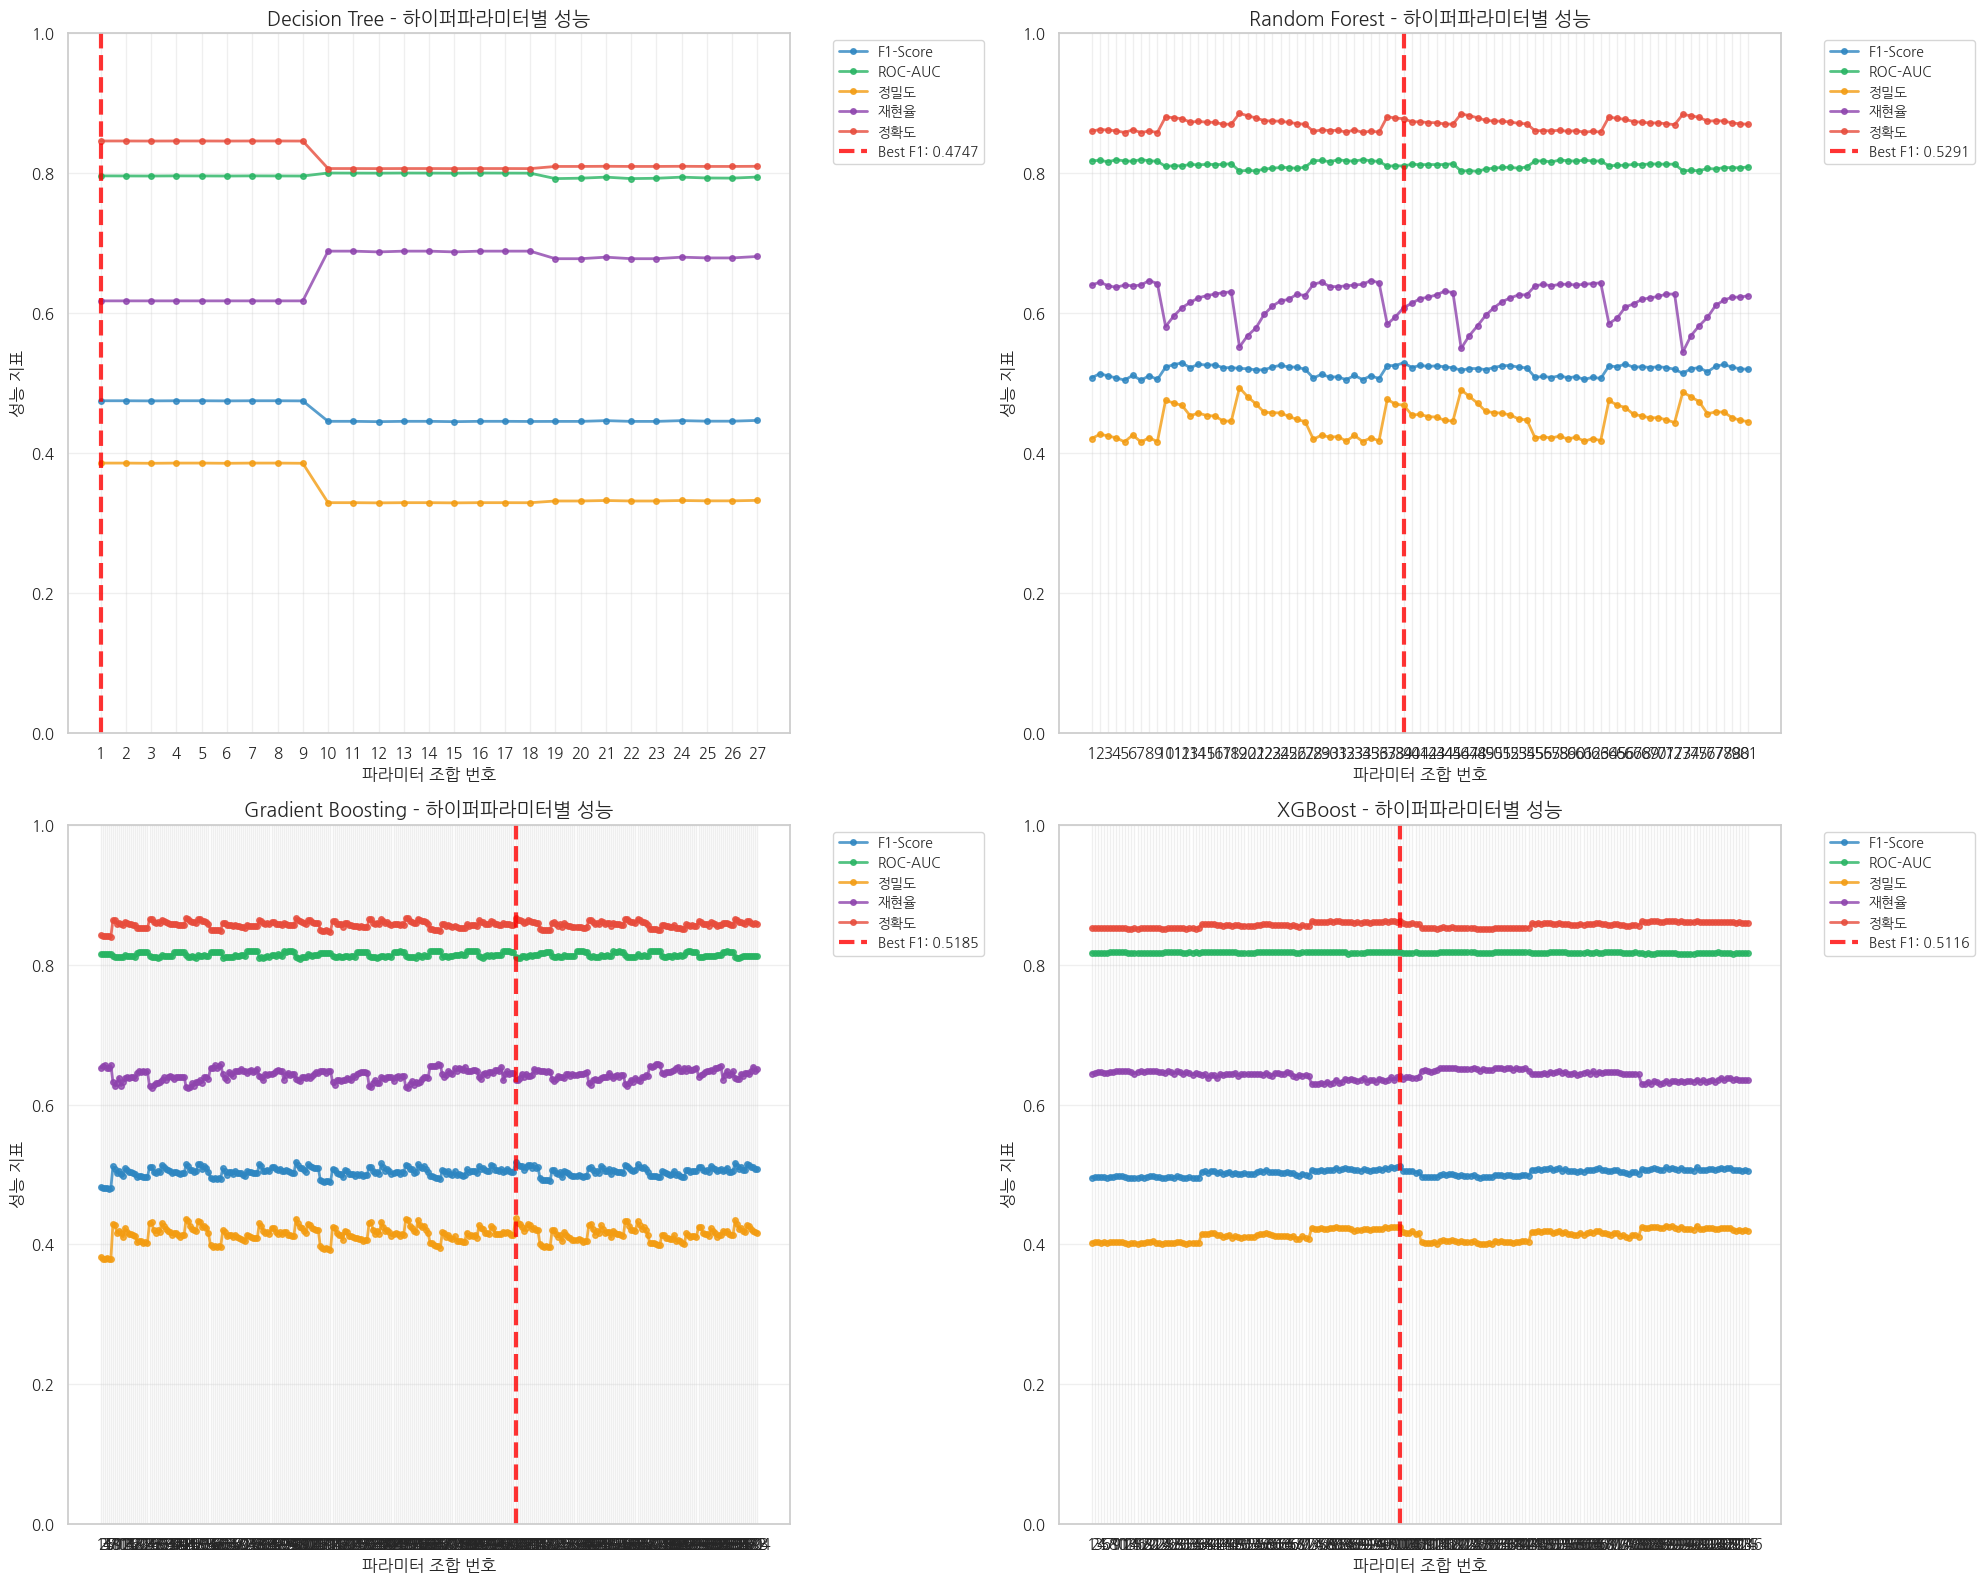

In [ ]:
# =============================================================================
# 모델별 하이퍼파라미터 vs 성능 지표 시각화
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_hyperparameter_performance():
    """
    각 모델별 하이퍼파라미터와 성능 지표의 관계를 시각화
    """
    print("=== 모델별 하이퍼파라미터 성능 시각화 ===")

    # 베스트 모델 정보 추출
    best_models_info = {}
    for _, row in best_models_by_f1.iterrows():
        model_name = row['모델명']
        f1_score = float(row['F1-Score'])
        best_models_info[model_name] = f1_score

    # 색상 설정
    colors = {
        'F1-Score': '#2E86C1',     # 파란색
        'ROC-AUC': '#28B463',      # 초록색
        '정밀도': '#F39C12',       # 주황색
        '재현율': '#8E44AD',       # 보라색
        '정확도': '#E74C3C'        # 빨간색
    }

    # 각 모델별로 서브플롯 생성
    unique_models = results_df['모델명'].unique()
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.ravel()

    for idx, model_name in enumerate(unique_models):
        ax = axes[idx]

        # 해당 모델의 데이터 필터링
        model_data = results_df[results_df['모델명'] == model_name].copy()

        # 숫자형으로 변환
        for col in ['F1-Score', 'ROC-AUC', '정밀도', '재현율', '정확도']:
            model_data[col] = model_data[col].astype(float)

        # x축: 파라미터 조합 번호
        x_values = range(1, len(model_data) + 1)

        # 각 성능 지표별로 선 그래프 그리기
        for metric, color in colors.items():
            y_values = model_data[metric].values
            ax.plot(x_values, y_values,
                   color=color,
                   label=metric,
                   linewidth=2,
                   marker='o',
                   markersize=4,
                   alpha=0.8)

        # 베스트 성능 표시 (빨간 세로선)
        if model_name in best_models_info:
            best_f1 = best_models_info[model_name]
            # 베스트 F1-Score에 해당하는 파라미터 조합 찾기
            best_idx = model_data[model_data['F1-Score'] == best_f1].index
            if len(best_idx) > 0:
                best_param_num = model_data.loc[best_idx[0], 'No.']
                # 해당 모델 내에서의 순서 찾기
                best_x = list(model_data['No.']).index(best_param_num) + 1

                ax.axvline(x=best_x, color='red', linestyle='--', linewidth=3, alpha=0.8,
                          label=f'Best F1: {best_f1:.4f}')

        # 그래프 설정
        ax.set_title(f'{model_name} - 하이퍼파라미터별 성능', fontsize=14, fontweight='bold')
        ax.set_xlabel('파라미터 조합 번호', fontsize=12)
        ax.set_ylabel('성능 지표', fontsize=12)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)  # 0-1 범위로 고정

        # x축 눈금 설정
        ax.set_xticks(range(1, len(model_data) + 1))

    plt.tight_layout()
    plt.show()

# 시각화 실행
visualize_hyperparameter_performance()


=== 세부 하이퍼파라미터별 성능 분석 ===
1. Decision Tree - max_depth별 성능
2. Random Forest - n_estimators별 성능
3. Gradient Boosting - n_estimators별 성능
4. XGBoost - learning_rate별 성능


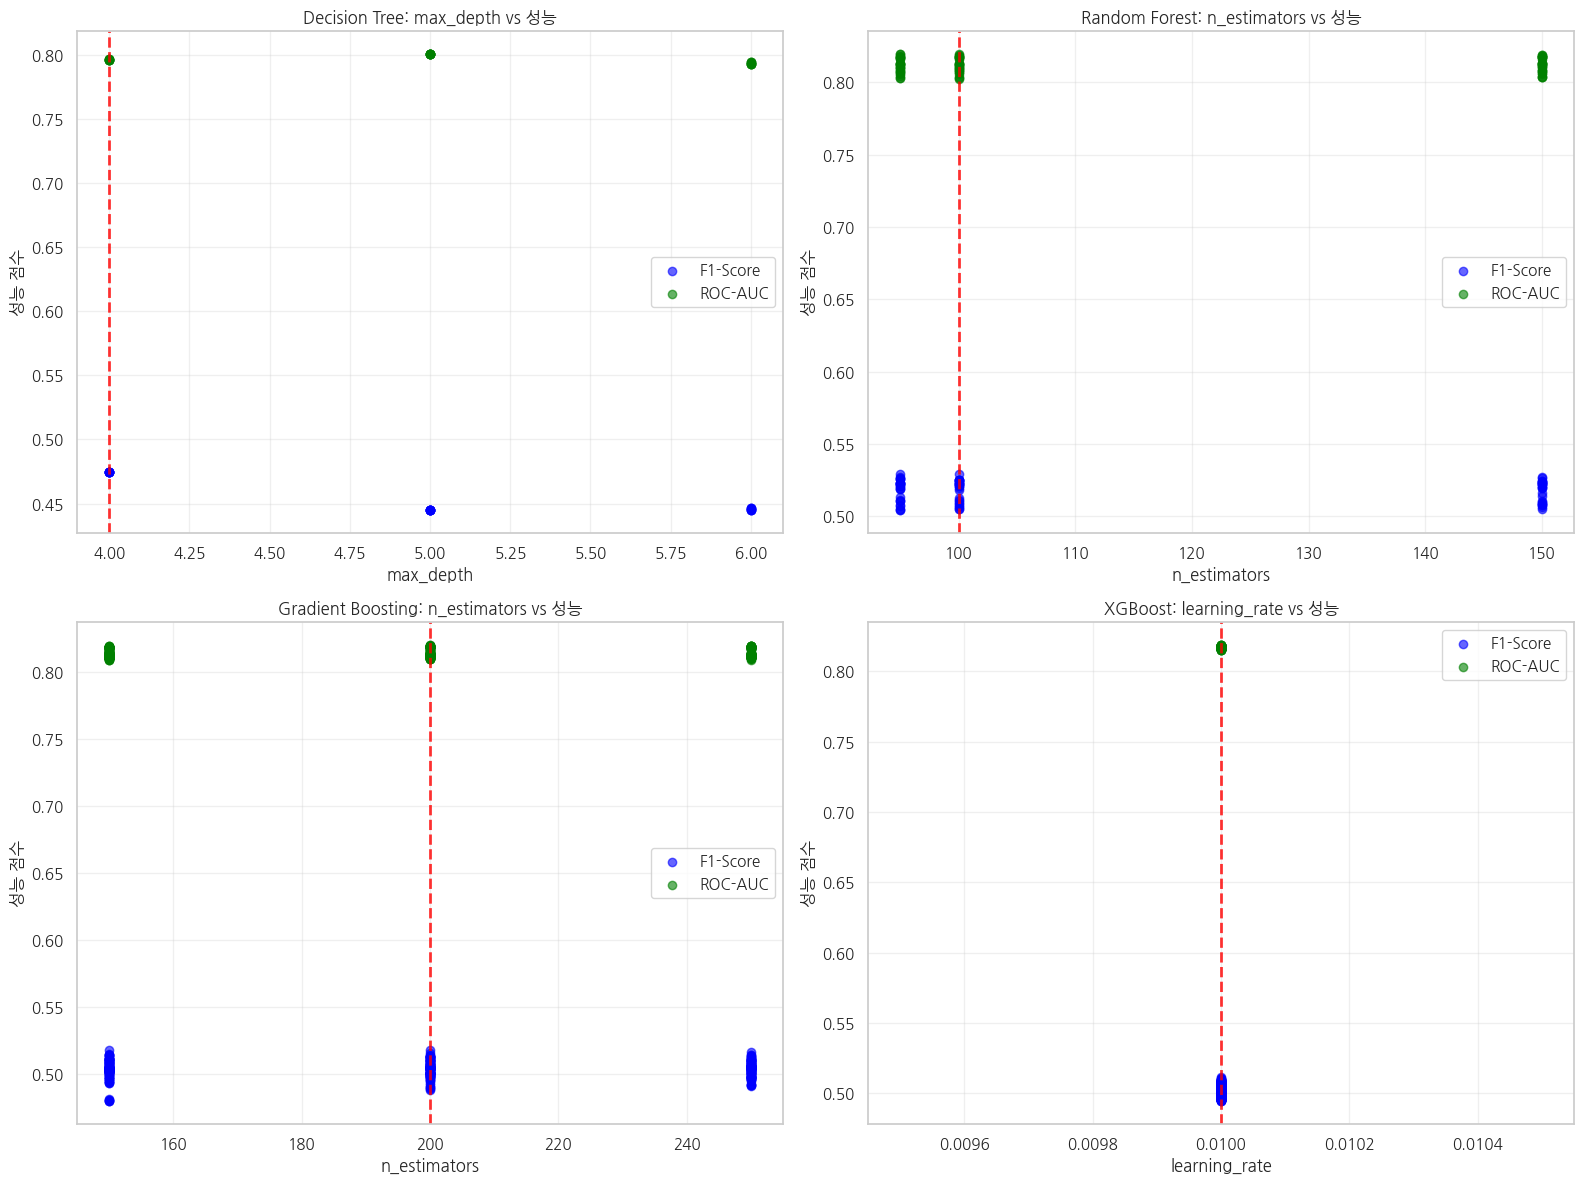

In [ ]:
# =============================================================================
# 세부 하이퍼파라미터별 성능 분석 시각화
# =============================================================================

def visualize_specific_hyperparameters():
    """
    특정 하이퍼파라미터와 성능의 관계를 상세히 시각화
    """
    print("\n=== 세부 하이퍼파라미터별 성능 분석 ===")

    # 1. Decision Tree: max_depth vs 성능 (첫 번째 위치로 이동)
    print("1. Decision Tree - max_depth별 성능")
    dt_data = results_df[results_df['모델명'] == 'Decision Tree'].copy()
    dt_data['max_depth'] = dt_data['파라미터'].str.extract(r'max_depth=(\d+)').astype(int)
    dt_data['F1-Score'] = dt_data['F1-Score'].astype(float)
    dt_data['ROC-AUC'] = dt_data['ROC-AUC'].astype(float)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Decision Tree - max_depth (첫 번째 위치)
    ax1 = axes[0, 0]
    ax1.scatter(dt_data['max_depth'], dt_data['F1-Score'],
               color='blue', alpha=0.6, label='F1-Score')
    ax1.scatter(dt_data['max_depth'], dt_data['ROC-AUC'],
               color='green', alpha=0.6, label='ROC-AUC')

    # 베스트 모델 표시
    best_dt = best_models_by_f1[best_models_by_f1['모델명'] == 'Decision Tree']
    if len(best_dt) > 0:
        best_f1 = float(best_dt['F1-Score'].iloc[0])
        best_row = dt_data[dt_data['F1-Score'] == best_f1]
        if len(best_row) > 0:
            best_depth = best_row['max_depth'].iloc[0]
            ax1.axvline(x=best_depth, color='red', linestyle='--', linewidth=2, alpha=0.8)

    ax1.set_title('Decision Tree: max_depth vs 성능', fontweight='bold')
    ax1.set_xlabel('max_depth')
    ax1.set_ylabel('성능 점수')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Random Forest: n_estimators vs 성능 (두 번째 위치로 이동)
    print("2. Random Forest - n_estimators별 성능")
    rf_data = results_df[results_df['모델명'] == 'Random Forest'].copy()

    # 파라미터에서 n_estimators 추출
    rf_data['n_estimators'] = rf_data['파라미터'].str.extract(r'n_estimators=(\d+)').astype(int)
    rf_data['F1-Score'] = rf_data['F1-Score'].astype(float)
    rf_data['ROC-AUC'] = rf_data['ROC-AUC'].astype(float)

    ax2 = axes[0, 1]
    ax2.scatter(rf_data['n_estimators'], rf_data['F1-Score'],
               color='blue', alpha=0.6, label='F1-Score')
    ax2.scatter(rf_data['n_estimators'], rf_data['ROC-AUC'],
               color='green', alpha=0.6, label='ROC-AUC')

    # 베스트 모델 표시
    best_rf = best_models_by_f1[best_models_by_f1['모델명'] == 'Random Forest']
    if len(best_rf) > 0:
        best_f1 = float(best_rf['F1-Score'].iloc[0])
        best_row = rf_data[rf_data['F1-Score'] == best_f1]
        if len(best_row) > 0:
            best_n_est = best_row['n_estimators'].iloc[0]
            ax2.axvline(x=best_n_est, color='red', linestyle='--', linewidth=2, alpha=0.8)

    ax2.set_title('Random Forest: n_estimators vs 성능', fontweight='bold')
    ax2.set_xlabel('n_estimators')
    ax2.set_ylabel('성능 점수')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Gradient Boosting: n_estimators vs 성능 (세 번째 위치 유지)
    print("3. Gradient Boosting - n_estimators별 성능")
    gb_data = results_df[results_df['모델명'] == 'Gradient Boosting'].copy()
    gb_data['n_estimators'] = gb_data['파라미터'].str.extract(r'n_estimators=(\d+)').astype(int)
    gb_data['F1-Score'] = gb_data['F1-Score'].astype(float)
    gb_data['ROC-AUC'] = gb_data['ROC-AUC'].astype(float)

    ax3 = axes[1, 0]
    ax3.scatter(gb_data['n_estimators'], gb_data['F1-Score'],
               color='blue', alpha=0.6, label='F1-Score')
    ax3.scatter(gb_data['n_estimators'], gb_data['ROC-AUC'],
               color='green', alpha=0.6, label='ROC-AUC')

    # 베스트 모델 표시
    best_gb = best_models_by_f1[best_models_by_f1['모델명'] == 'Gradient Boosting']
    if len(best_gb) > 0:
        best_f1 = float(best_gb['F1-Score'].iloc[0])
        best_row = gb_data[gb_data['F1-Score'] == best_f1]
        if len(best_row) > 0:
            best_n_est = best_row['n_estimators'].iloc[0]
            ax3.axvline(x=best_n_est, color='red', linestyle='--', linewidth=2, alpha=0.8)

    ax3.set_title('Gradient Boosting: n_estimators vs 성능', fontweight='bold')
    ax3.set_xlabel('n_estimators')
    ax3.set_ylabel('성능 점수')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. XGBoost: learning_rate vs 성능 (네 번째 위치로 이동)
    print("4. XGBoost - learning_rate별 성능")
    xgb_data = results_df[results_df['모델명'] == 'XGBoost'].copy()
    xgb_data['learning_rate'] = xgb_data['파라미터'].str.extract(r'learning_rate=([0-9.]+)').astype(float)
    xgb_data['F1-Score'] = xgb_data['F1-Score'].astype(float)
    xgb_data['ROC-AUC'] = xgb_data['ROC-AUC'].astype(float)

    ax4 = axes[1, 1]
    ax4.scatter(xgb_data['learning_rate'], xgb_data['F1-Score'],
               color='blue', alpha=0.6, label='F1-Score')
    ax4.scatter(xgb_data['learning_rate'], xgb_data['ROC-AUC'],
               color='green', alpha=0.6, label='ROC-AUC')

    # 베스트 모델 표시
    best_xgb = best_models_by_f1[best_models_by_f1['모델명'] == 'XGBoost']
    if len(best_xgb) > 0:
        best_f1 = float(best_xgb['F1-Score'].iloc[0])
        best_row = xgb_data[xgb_data['F1-Score'] == best_f1]
        if len(best_row) > 0:
            best_lr = best_row['learning_rate'].iloc[0]
            ax4.axvline(x=best_lr, color='red', linestyle='--', linewidth=2, alpha=0.8)

    ax4.set_title('XGBoost: learning_rate vs 성능', fontweight='bold')
    ax4.set_xlabel('learning_rate')
    ax4.set_ylabel('성능 점수')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 세부 분석 실행
visualize_specific_hyperparameters()


=== 모델별 성능 향상 추이 ===


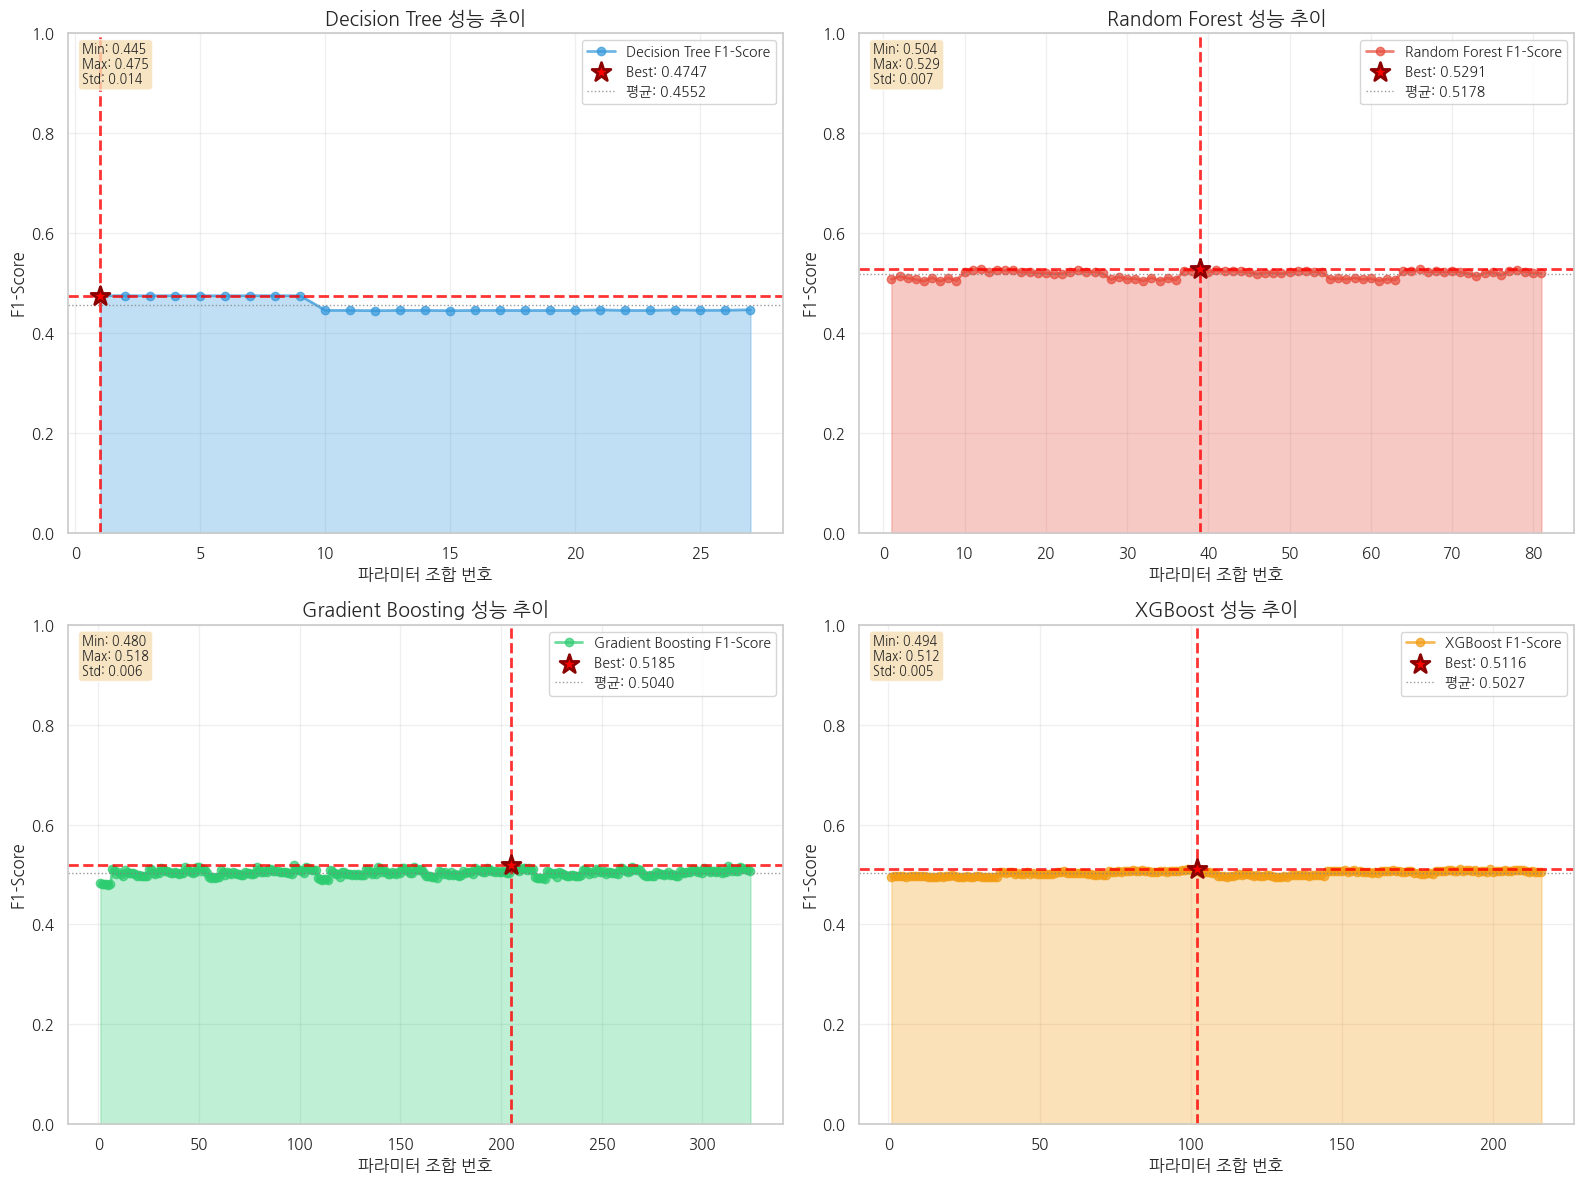

In [ ]:
# =============================================================================
# 성능 향상 추이 및 베스트 모델 하이라이트
# =============================================================================

def visualize_performance_trends():
    """
    모델별 성능 향상 추이와 베스트 모델 하이라이트
    visualize_hyperparameter_performance와 동일한 모델 순서 사용
    """
    print("\n=== 모델별 성능 향상 추이 ===")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    # visualize_hyperparameter_performance와 동일한 모델 순서 사용
    unique_models = results_df['모델명'].unique()
    colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

    for idx, model_name in enumerate(unique_models):
        ax = axes[idx]

        # 해당 모델 데이터
        model_data = results_df[results_df['모델명'] == model_name].copy()
        model_data['F1-Score'] = model_data['F1-Score'].astype(float)

        # x축: 파라미터 조합 순서
        x_values = range(1, len(model_data) + 1)
        y_values = model_data['F1-Score'].values

        # 기본 선 그래프
        ax.plot(x_values, y_values, color=colors[idx], linewidth=2, marker='o',
               markersize=6, alpha=0.7, label=f'{model_name} F1-Score')

        # 베스트 성능 포인트 찾기
        best_idx = np.argmax(y_values)
        best_x = x_values[best_idx]
        best_y = y_values[best_idx]

        # 베스트 포인트 강조
        ax.scatter(best_x, best_y, color='red', s=200, marker='*',
                  edgecolor='darkred', linewidth=2, zorder=5,
                  label=f'Best: {best_y:.4f}')

        # 베스트 성능에 수직선 그리기
        ax.axvline(x=best_x, color='red', linestyle='--', linewidth=2, alpha=0.8)
        ax.axhline(y=best_y, color='red', linestyle='--', linewidth=2, alpha=0.8)

        # 성능 구간별 색칠
        ax.fill_between(x_values, y_values, alpha=0.3, color=colors[idx])

        # 평균 성능선
        avg_performance = np.mean(y_values)
        ax.axhline(y=avg_performance, color='gray', linestyle=':', linewidth=1,
                  alpha=0.8, label=f'평균: {avg_performance:.4f}')

        # 그래프 설정
        ax.set_title(f'{model_name} 성능 추이', fontsize=14, fontweight='bold')
        ax.set_xlabel('파라미터 조합 번호', fontsize=12)
        ax.set_ylabel('F1-Score', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)

        # 성능 통계 텍스트 추가
        min_score = np.min(y_values)
        max_score = np.max(y_values)
        std_score = np.std(y_values)

        stats_text = f'Min: {min_score:.3f}\nMax: {max_score:.3f}\nStd: {std_score:.3f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               fontsize=9)

    plt.tight_layout()
    plt.show()

# 성능 추이 시각화 실행
visualize_performance_trends()


=== 최종 모델 성능 비교 시각화 ===


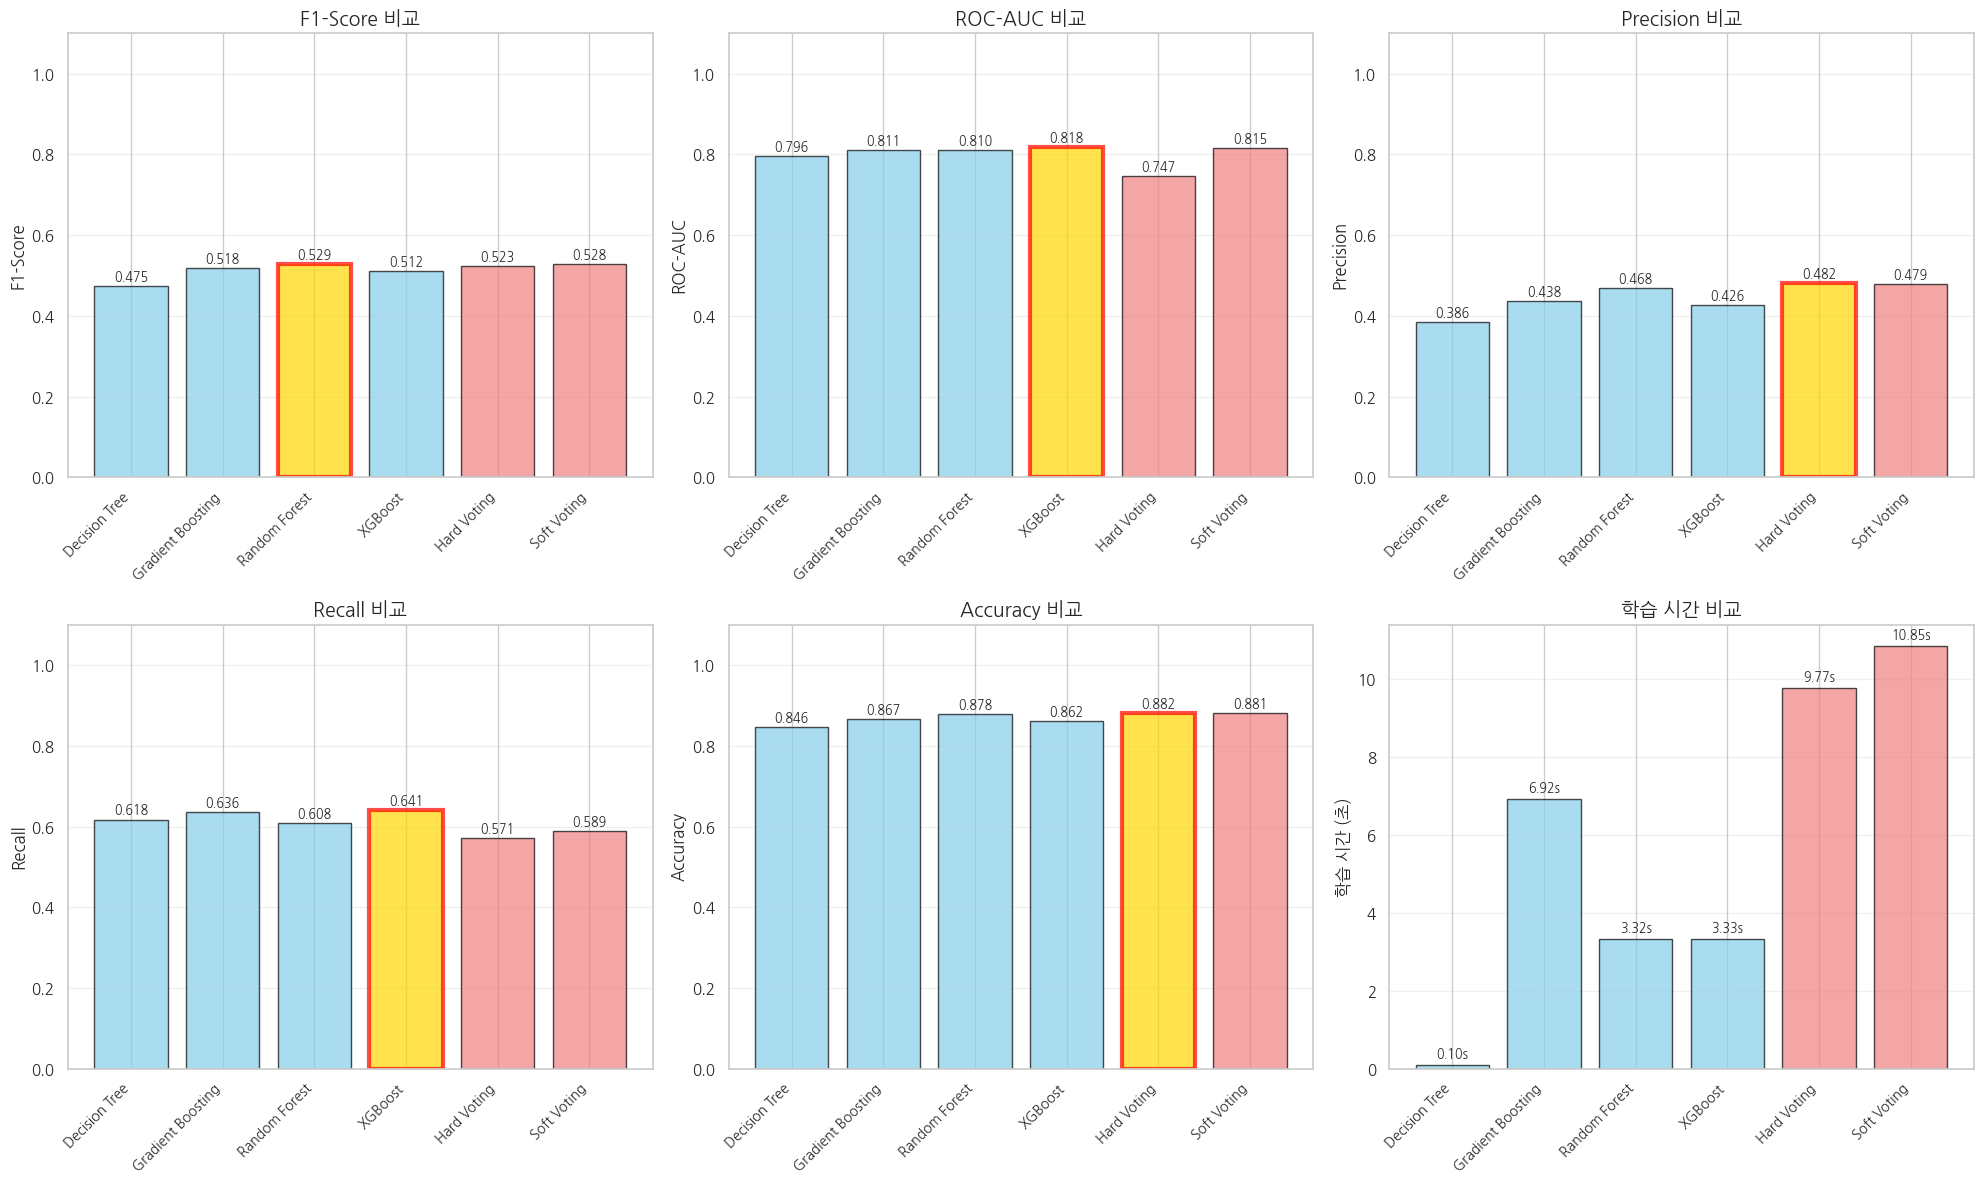

In [ ]:
# =============================================================================
# 최종 모델 성능 비교 시각화 (앙상블 포함)
# =============================================================================

def visualize_final_comparison():
    """
    최종 모델 성능 비교 (개별 모델 + 앙상블) 시각화
    """
    print("\n=== 최종 모델 성능 비교 시각화 ===")

    # 1. 성능 지표별 비교 막대 그래프
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()

    # 데이터 준비
    models = final_comparison_df['Model'].values
    metrics = ['F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy']

    # 색상 설정 (개별모델 vs 앙상블)
    colors = ['skyblue' if 'Tree' in model or 'Forest' in model or 'Boosting' in model or 'XGBoost' in model
              else 'lightcoral' for model in models]

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        # 값을 숫자형으로 변환
        values = [float(val) for val in final_comparison_df[metric]]

        # 막대 그래프
        bars = ax.bar(range(len(models)), values, color=colors, alpha=0.7, edgecolor='black')

        # 최고 성능 표시
        best_idx = values.index(max(values))
        bars[best_idx].set_color('gold')
        bars[best_idx].set_edgecolor('red')
        bars[best_idx].set_linewidth(3)

        # 값 표시
        for i, (bar, val) in enumerate(zip(bars, values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_title(f'{metric} 비교', fontsize=14, fontweight='bold')
        ax.set_ylabel(metric, fontsize=12)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3, axis='y')

    # 6번째 서브플롯: 학습 시간 비교
    ax6 = axes[5]
    train_times = [float(val.replace('s', '')) for val in final_comparison_df['Train_Time']]
    bars = ax6.bar(range(len(models)), train_times, color=colors, alpha=0.7, edgecolor='black')

    # 값 표시
    for i, (bar, val) in enumerate(zip(bars, train_times)):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + max(train_times)*0.01,
               f'{val:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax6.set_title('학습 시간 비교', fontsize=14, fontweight='bold')
    ax6.set_ylabel('학습 시간 (초)', fontsize=12)
    ax6.set_xticks(range(len(models)))
    ax6.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    ax6.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# 최종 비교 시각화 실행
visualize_final_comparison()


=== 모델별 성능 레이더 차트 ===


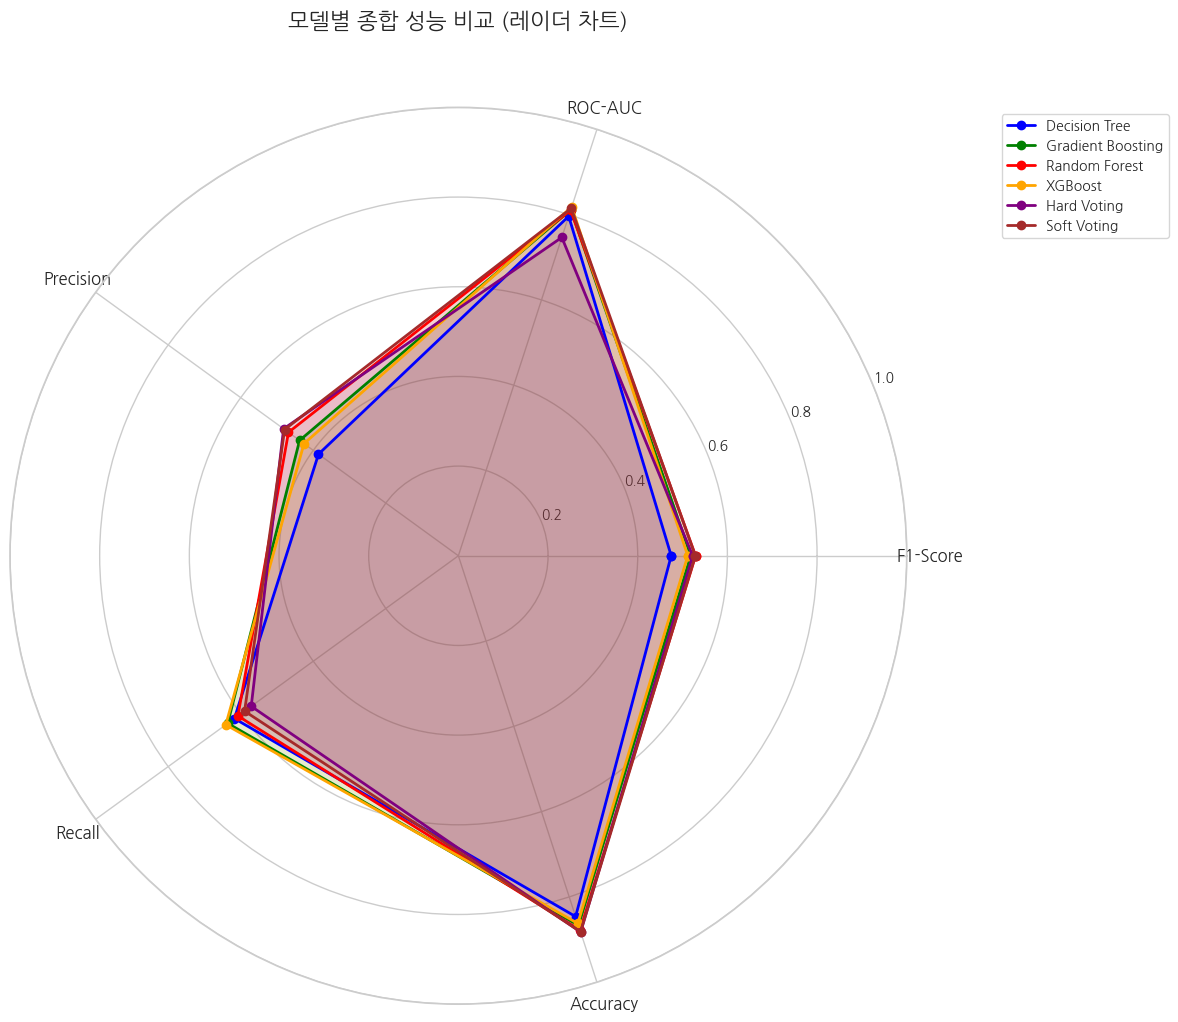

In [ ]:
# =============================================================================
# 모델별 성능 레이더 차트
# =============================================================================

def create_radar_chart():
    """
    각 모델의 성능을 레이더 차트로 비교
    """
    print("\n=== 모델별 성능 레이더 차트 ===")

    import numpy as np

    # 데이터 준비
    models = final_comparison_df['Model'].values
    metrics = ['F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy']

    # 각 지표별 값 추출
    values_data = []
    for model in models:
        model_values = []
        for metric in metrics:
            val = final_comparison_df[final_comparison_df['Model'] == model][metric].iloc[0]
            model_values.append(float(val))
        values_data.append(model_values)

    # 레이더 차트 설정
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # 닫힌 다각형을 위해

    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

    # 색상 설정
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']

    for i, (model, values) in enumerate(zip(models, values_data)):
        values += values[:1]  # 닫힌 다각형을 위해

        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

    # 축 설정
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
    ax.grid(True)

    # 제목 및 범례
    plt.title('모델별 종합 성능 비교 (레이더 차트)', size=16, fontweight='bold', y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)

    plt.tight_layout()
    plt.show()

# 레이더 차트 실행
create_radar_chart()

In [ ]:

# 1. 테스트 데이터에 대해 가입 확률 예측
best_model = voting_soft  # 또는 원하는 모델(best_xgb 등)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # 가입 확률 (1 클래스)

# 2. 확률 구간별 그룹 분류
def assign_group(prob):
    if prob >= 0.8:
        return "즉시 연락/프리미엄"
    elif prob >= 0.5:
        return "2차 타겟/맞춤혜택"
    elif prob >= 0.3:
        return "정보성 캠페인"
    else:
        return "캠페인 제외"

group_labels = [assign_group(p) for p in y_pred_proba]

# 3. 결과 데이터프레임 생성
result_df = X_test.copy()
result_df['가입확률'] = y_pred_proba
result_df['마케팅그룹'] = group_labels

# 4. 그룹별 인원 및 비율 확인
group_summary = result_df['마케팅그룹'].value_counts(normalize=True).mul(100).round(2)
print("마케팅 그룹별 분포(%)")
#print(group_summary)
group_summary.head_att()

print()
# 5. 예시 상위 10명 출력
result_df_sorted = result_df.sort_values('가입확률', ascending=False)
result_df_sorted[['가입확률', '마케팅그룹']].head_att(10)
#print(result_df_sorted[['가입확률', '마케팅그룹']].head())

마케팅 그룹별 분포(%)
인덱스              proportion  
index               proportion  
캠페인 제외         74.29       
정보성 캠페인       11.85       
2차 타겟/맞춤혜택   11.79       
즉시 연락/프리미엄  2.08        

       가입확률         마케팅그룹
       가입확률         마케팅그룹
 39655   0.9123 즉시 연락/프리미엄
 40476   0.9074 즉시 연락/프리미엄
 40487   0.9062 즉시 연락/프리미엄
 40360    0.906 즉시 연락/프리미엄
 40473    0.904 즉시 연락/프리미엄
 40413   0.9036 즉시 연락/프리미엄
 40586   0.9031 즉시 연락/프리미엄
 40163   0.9012 즉시 연락/프리미엄
 39498    0.901 즉시 연락/프리미엄
 39644   0.9008 즉시 연락/프리미엄


# 결론
- 상위 10명의 가입확률이 모두 0.90 이상으로, 이들은 '즉시 연락/프리미엄' 그룹에 속합니다.
  즉, 모델이 예측한 가입 확률이 매우 높은 고객을 잘 선별 해냈음을 보여줍니다.
- 전체 분포를 보면:
    - 캠페인 제외(가입확률 0.3 미만): 73.89% (대부분의 고객은 가입 가능성이 낮음)
    - 즉시 연락/프리미엄(0.8 이상): 2.09% (가입 가능성이 매우 높은 핵심 타겟)
    - 2차 타겟/맞춤혜택(0.5~0.8): 11.8%
    - 정보성 캠페인(0.3~0.5): 12.22%
